## Lab 01

--- 
### Data Preparation Steps
Four-Step Data Preparation Procedure (Chapter 4) that must be completed to prepare the data for the EDA in Chapter 5:

- Step 1: Learn about the Data Collection Process: Understand the domain and how data was gathered before you even touch it to avoid making incorrect assumptions.

- Step 2: Load the Data: Import the raw data into your environment (never modify the raw file itself).

- Step 3: Examine the Data and Create Action Items:
    - This is where "cleaning explorations" happen.
    - Look for specific "Messy Data Traits" (e.g., Invalid values, Nonstandard formats, Messy column names).
    - Create a list of "action items" to fix these issues.

Step 4: Clean the Data:
- Write a reusable function to apply your action items.
--- 

Preprocessing (often included here) involves modifying clean data to fit algorithms (e.g., imputing missing values, scaling variables).

### EDA

### PCA

#### Context

The Kuppermann Decision Rule Features
The paper defines two separate rules based on age group:

- Children < 2 years (age_group = 1):

    - Altered mental status (altered_mental_status)
    - Palpable skull fracture (skull_fx_palpable)
    - Loss of consciousness ≥ 5 seconds (loc)
    - Severe injury mechanism (injury_mechanism / injury_severity)
    - Scalp hematoma — specifically non-frontal location (scalp_hematoma + hematoma_location)
    - Not acting normally (acting_normal)

- Children ≥ 2 years (age_group = 2):
    - Altered mental status (altered_mental_status)
    - Signs of basilar skull fracture (basilar_skull_fx)
    - Loss of consciousness (loc)
    - Severe injury mechanism (injury_mechanism / injury_severity)
    - Vomiting (vomiting)
    - Headache (headache)

| Age Group            | Tier                          | Feature                     | Nuance                                                                                                                                 |
|----------------------|-------------------------------|-----------------------------|----------------------------------------------------------------------------------------------------------------------------------------|
| Children < 2 years   | **Tier 1 (CT recommended)**    | Altered mental status       | GCS = 14 **OR** agitation, somnolence, repetitive questioning, or slow response                                                        |
| Children < 2 years   | **Tier 1 (CT recommended)**    | Palpable skull fracture     | Binary yes/no                                                                                                                          |
| Children < 2 years   | **Tier 2 (Observation vs CT)** | Non-frontal scalp hematoma  | Location matters: only **occipital, parietal, or temporal** count. Frontal does **NOT** count                                          |
| Children < 2 years   | **Tier 2 (Observation vs CT)** | LOC ≥ 5 seconds             | Duration matters: only ≥ 5 seconds counts, not any LOC                                                                                 |
| Children < 2 years   | **Tier 2 (Observation vs CT)** | Severe injury mechanism     | MVC with ejection/rollover/death; pedestrian/cyclist struck; fall > 0.9 m (3 ft); high-impact object                                  |
| Children < 2 years   | **Tier 2 (Observation vs CT)** | Not acting normally         | Per parent report                                                                                                                      |


--- 


| Age Group            | Tier                          | Feature                              | Nuance                                                                                                      |
|----------------------|-------------------------------|--------------------------------------|-------------------------------------------------------------------------------------------------------------|
| Children ≥ 2 years   | **Tier 1 (CT recommended)**    | Altered mental status                | Same composite definition                                                                                   |
| Children ≥ 2 years   | **Tier 1 (CT recommended)**    | Signs of basilar skull fracture      | Battle sign, raccoon eyes, hemotympanum, CSF leak                                                           |
| Children ≥ 2 years   | **Tier 2 (Observation vs CT)** | Any LOC                              | Any duration (no 5-second threshold like <2 group)                                                           |
| Children ≥ 2 years   | **Tier 2 (Observation vs CT)** | Vomiting                             | Simple presence/absence                                                                                    |
| Children ≥ 2 years   | **Tier 2 (Observation vs CT)** | Severe injury mechanism              | Same criteria, but fall threshold is > 1.5 m (5 ft) instead of > 0.9 m                                      |
| Children ≥ 2 years   | **Tier 2 (Observation vs CT)** | Severe headache                      | Only severe — mild/moderate do not count                                                                    |


In [1]:
# import libraries
import pandas as pd
import re
import seaborn as sns # reminder to add to requirements file
import matplotlib.pyplot as plt

# set display options for pandas
pd.set_option('display.max_columns', None)

In [2]:
# import the raw data
df = pd.read_csv('../data/TBI PUD 10-08-2013.csv')

# shape of the data
print(f"Shape of the data: {df.shape}")

# data types of the columns
print("\nData types of the columns:")
print(df.dtypes)

Shape of the data: (43399, 125)

Data types of the columns:
PatNum                  int64
EmplType              float64
Certification           int64
InjuryMech            float64
High_impact_InjSev    float64
                       ...   
HospHead              float64
HospHeadPosCT           int64
Intub24Head           float64
Neurosurgery          float64
PosIntFinal           float64
Length: 125, dtype: object


In [3]:
# make a copy of the raw data for cleaning and preprocessing
df_clean = df.copy()

In [4]:
# Action item 2: Rename columns to lowercase, human-readable, underscore-separated names
# Reference: VDS Chapter 4 — old_name → new_name mapping shown explicitly
# key design decisions:
    # Lowercase + underscores, Expand abbreviations, Group with prefixes, Keep clinically standard abbreviations, Outcome column is descriptive, Old → new mapping is explicit

rename_map = {
    # ── Identifiers & provider info ──
    'PatNum':             'patient_id',
    'EmplType':           'physician_position',
    'Certification':      'physician_certification',
    
    # ── Injury mechanism ──
    'InjuryMech':         'injury_mechanism',
    'High_impact_InjSev': 'injury_severity',
    
    # ── Symptoms: amnesia, LOC, seizure ──
    'Amnesia_verb':       'amnesia',
    'LOCSeparate':        'loc',                        # loss of consciousness
    'LocLen':             'loc_duration',
    'Seiz':               'seizure',
    'SeizOccur':          'seizure_timing',
    'SeizLen':            'seizure_duration',
    
    # ── Symptoms: general ──
    'ActNorm':            'acting_normal',
    'HA_verb':            'headache',
    'HASeverity':         'headache_severity',
    'HAStart':            'headache_onset',
    'Vomit':              'vomiting',
    'VomitNbr':           'vomiting_episodes',
    'VomitStart':         'vomiting_onset',
    'VomitLast':          'vomiting_last',
    'Dizzy':              'dizziness',
    
    # ── Pre-evaluation interventions ──
    'Intubated':          'intubated',
    'Paralyzed':          'paralyzed',
    'Sedated':            'sedated',
    
    # ── Glasgow Coma Scale ──
    'GCSEye':             'gcs_eye',
    'GCSVerbal':          'gcs_verbal',
    'GCSMotor':           'gcs_motor',
    'GCSTotal':           'gcs_total',
    'GCSGroup':           'gcs_group',
    
    # ── Altered mental status ──
    'AMS':                'altered_mental_status',
    'AMSAgitated':        'ams_agitated',
    'AMSSleep':           'ams_sleepy',
    'AMSSlow':            'ams_slow_response',
    'AMSRepeat':          'ams_repetitive_questions',
    'AMSOth':             'ams_other',
    
    # ── Skull fracture signs ──
    'SFxPalp':            'skull_fx_palpable',
    'SFxPalpDepress':     'skull_fx_depressed',
    'FontBulg':           'fontanelle_bulging',
    'SFxBas':             'basilar_skull_fx',
    'SFxBasHem':          'basilar_fx_hemotympanum',
    'SFxBasOto':          'basilar_fx_csf_otorrhea',
    'SFxBasPer':          'basilar_fx_raccoon_eyes',
    'SFxBasRet':          'basilar_fx_battle_sign',
    'SFxBasRhi':          'basilar_fx_csf_rhinorrhea',
    
    # ── Scalp hematoma ──
    'Hema':               'scalp_hematoma',
    'HemaLoc':            'hematoma_location',
    'HemaSize':           'hematoma_size',
    
    # ── Trauma above clavicles ──
    'Clav':               'trauma_above_clavicles',
    'ClavFace':           'trauma_face',
    'ClavNeck':           'trauma_neck',
    'ClavFro':            'trauma_scalp_frontal',
    'ClavOcc':            'trauma_scalp_occipital',
    'ClavPar':            'trauma_scalp_parietal',
    'ClavTem':            'trauma_scalp_temporal',
    
    # ── Neurological deficit ──
    'NeuroD':             'neuro_deficit',
    'NeuroDMotor':        'neuro_deficit_motor',
    'NeuroDSensory':      'neuro_deficit_sensory',
    'NeuroDCranial':      'neuro_deficit_cranial',
    'NeuroDReflex':       'neuro_deficit_reflexes',
    'NeuroDOth':          'neuro_deficit_other',
    
    # ── Other substantial injuries ──
    'OSI':                'other_injuries',
    'OSIExtremity':       'other_injury_extremity',
    'OSICut':             'other_injury_laceration',
    'OSICspine':          'other_injury_cspine',
    'OSIFlank':           'other_injury_chest_flank',
    'OSIAbdomen':         'other_injury_abdomen',
    'OSIPelvis':          'other_injury_pelvis',
    'OSIOth':             'other_injury_other',
    
    # ── Drugs ──
    'Drugs':              'drug_intoxication',
    
    # ── CT ordering ──
    'CTForm1':            'ct_ordered',
    'IndAge':             'ct_ind_age',
    'IndAmnesia':         'ct_ind_amnesia',
    'IndAMS':             'ct_ind_mental_status',
    'IndClinSFx':         'ct_ind_skull_fracture',
    'IndHA':              'ct_ind_headache',
    'IndHema':            'ct_ind_hematoma',
    'IndLOC':             'ct_ind_loc',
    'IndMech':            'ct_ind_mechanism',
    'IndNeuroD':          'ct_ind_neuro_deficit',
    'IndRqstMD':          'ct_ind_md_request',
    'IndRqstParent':      'ct_ind_parent_request',
    'IndRqstTrauma':      'ct_ind_trauma_team',
    'IndSeiz':            'ct_ind_seizure',
    'IndVomit':           'ct_ind_vomiting',
    'IndXraySFx':         'ct_ind_xray_fracture',
    'IndOth':             'ct_ind_other',
    
    # ── CT sedation ──
    'CTSed':              'ct_sedation',
    'CTSedAgitate':       'ct_sed_agitation',
    'CTSedAge':           'ct_sed_age',
    'CTSedRqst':          'ct_sed_tech_request',
    'CTSedOth':           'ct_sed_other',
    
    # ── Demographics ──
    'AgeInMonth':         'age_months',
    'AgeinYears':         'age_years',
    'AgeTwoPlus':         'age_group',              # < 2 years vs >= 2 years
    'Gender':             'gender',
    'Ethnicity':          'ethnicity',
    'Race':               'race',
    
    # ── ED management & disposition ──
    'Observed':           'observed_in_ed',
    'EDDisposition':      'ed_disposition',
    'CTDone':             'ct_performed',
    'EDCT':               'ct_performed_in_ed',
    'PosCT':              'tbi_on_ct',
    
    # ── CT findings ──
    'Finding1':           'finding_cerebellar_hemorrhage',
    'Finding2':           'finding_cerebral_contusion',
    'Finding3':           'finding_cerebral_edema',
    'Finding4':           'finding_cerebral_hemorrhage',
    'Finding5':           'finding_skull_diastasis',
    'Finding6':           'finding_epidural_hematoma',
    'Finding7':           'finding_extraaxial_hematoma',
    'Finding8':           'finding_intraventricular_hemorrhage',
    'Finding9':           'finding_midline_shift',
    'Finding10':          'finding_pneumocephalus',
    'Finding11':          'finding_skull_fracture',
    'Finding12':          'finding_subarachnoid_hemorrhage',
    'Finding13':          'finding_subdural_hematoma',
    'Finding14':          'finding_traumatic_infarction',
    'Finding20':          'finding_diffuse_axonal_injury',
    'Finding21':          'finding_herniation',
    'Finding22':          'finding_shear_injury',
    'Finding23':          'finding_sigmoid_sinus_thrombosis',
    
    # ── Outcomes ──
    'DeathTBI':           'death_from_tbi',
    'HospHead':           'hospitalized_head_injury',
    'HospHeadPosCT':      'hospitalized_positive_ct',
    'Intub24Head':        'intubated_24h_head',
    'Neurosurgery':       'neurosurgery',
    'PosIntFinal':        'clinically_important_tbi',   # primary outcome
}

df_clean = df_clean.rename(columns=rename_map)

In [5]:
# Action item 2: Convert all columns to integer type

# Pandas nullable Int64 (capital I) supports NaN values natively,
# unlike numpy's int64 which forces float conversion when NaNs exist.

# convert all columns to nullable Int64
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype('Int64')


print(f"All columns are now Int64: {(df_clean.dtypes == 'Int64').all()}")
print("\nNaN values preserved example (clinically_important_tbi):")
print(df_clean['clinically_important_tbi'].isna().sum(), "NaNs")
print("\nSample:")
df_clean.head()

All columns are now Int64: True

NaN values preserved example (clinically_important_tbi):
20 NaNs

Sample:


,patient_id,physician_position,physician_certification,injury_mechanism,injury_severity,amnesia,loc,loc_duration,seizure,seizure_timing,seizure_duration,acting_normal,headache,headache_severity,headache_onset,vomiting,vomiting_episodes,vomiting_onset,vomiting_last,dizziness,intubated,paralyzed,sedated,gcs_eye,gcs_verbal,gcs_motor,gcs_total,gcs_group,altered_mental_status,ams_agitated,ams_sleepy,ams_slow_response,ams_repetitive_questions,ams_other,skull_fx_palpable,skull_fx_depressed,fontanelle_bulging,basilar_skull_fx,basilar_fx_hemotympanum,basilar_fx_csf_otorrhea,basilar_fx_raccoon_eyes,basilar_fx_battle_sign,basilar_fx_csf_rhinorrhea,scalp_hematoma,hematoma_location,hematoma_size,trauma_above_clavicles,trauma_face,trauma_neck,trauma_scalp_frontal,trauma_scalp_occipital,trauma_scalp_parietal,trauma_scalp_temporal,neuro_deficit,neuro_deficit_motor,neuro_deficit_sensory,neuro_deficit_cranial,neuro_deficit_reflexes,neuro_deficit_other,other_injuries,other_injury_extremity,other_injury_laceration,other_injury_cspine,other_injury_chest_flank,other_injury_abdomen,other_injury_pelvis,other_injury_other,drug_intoxication,ct_ordered,ct_ind_age,ct_ind_amnesia,ct_ind_mental_status,ct_ind_skull_fracture,ct_ind_headache,ct_ind_hematoma,ct_ind_loc,ct_ind_mechanism,ct_ind_neuro_deficit,ct_ind_md_request,ct_ind_parent_request,ct_ind_trauma_team,ct_ind_seizure,ct_ind_vomiting,ct_ind_xray_fracture,ct_ind_other,ct_sedation,ct_sed_agitation,ct_sed_age,ct_sed_tech_request,ct_sed_other,age_months,age_years,age_group,gender,ethnicity,race,observed_in_ed,ed_disposition,ct_performed,ct_performed_in_ed,tbi_on_ct,finding_cerebellar_hemorrhage,finding_cerebral_contusion,finding_cerebral_edema,finding_cerebral_hemorrhage,finding_skull_diastasis,finding_epidural_hematoma,finding_extraaxial_hematoma,finding_intraventricular_hemorrhage,finding_midline_shift,finding_pneumocephalus,finding_skull_fracture,finding_subarachnoid_hemorrhage,finding_subdural_hematoma,finding_traumatic_infarction,finding_diffuse_axonal_injury,finding_herniation,finding_shear_injury,finding_sigmoid_sinus_thrombosis,death_from_tbi,hospitalized_head_injury,hospitalized_positive_ct,intubated_24h_head,neurosurgery,clinically_important_tbi
0,1,3,3,11,2,0,0,92,0,92,92,1,1,1,2,0,92,92,92,0,0,0,0,4,5,6,15,2,0,92,92,92,92,92,0,92,0,0,92,92,92,92,92,1,3,3,1,1,0,0,0,0,1,0,92,92,92,92,92,0,92,92,92,92,92,92,92,0,0,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,197,16,2,1,2,2,0,1,0,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,0,0,0,0,0,0
1,2,5,3,8,2,0,0,92,0,92,92,1,0,92,92,1,3,3,1,<NA>,0,0,0,4,5,6,15,2,0,92,92,92,92,92,0,92,0,0,92,92,92,92,92,0,92,92,0,92,92,92,92,92,92,0,92,92,92,92,92,0,92,92,92,92,92,92,92,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,92,92,92,92,64,5,2,2,2,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,5,3,5,2,<NA>,<NA>,92,<NA>,92,92,0,<NA>,92,92,<NA>,92,92,92,<NA>,1,1,1,1,1,1,3,1,1,1,0,0,0,0,1,1,0,1,0,0,1,0,1,1,3,3,1,0,0,1,0,1,0,<NA>,92,92,92,92,92,0,92,92,92,92,92,92,92,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,92,92,92,92,170,14,2,1,<NA>,1,0,5,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,5,3,6,1,91,0,92,0,92,92,1,91,92,92,0,92,92,92,<NA>,0,0,0,4,5,6,15,2,0,92,92,92,92,92,0,92,0,0,92,92,92,92,92,1,1,2,1,0,0,1,0,0,0,0,92,92,92,92,92,0,92,92,92,92,92,92,92,0,0,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,13,1,1,2,2,2,0,1,0,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,0,0,0,0,0,0
4,5,3,3,12,2,91,0,92,0,92,92,0,91,92,92,1,1,2,2,<NA>,0,0,0,4,4,5,13,1,1,0,1,1,0,0,0,92,0,0,92,92,92,92,92,1,1,2,1,0,0,1,0,0,0,0,92,92,92,92,92,0,92,92,92,92,92,92,92,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,92,92,92,92,14,1,1,1,2,2,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Action item 3: Missing Values Analysis
# Reference: VDS Chapter 4 — systematic approach to identifying and handling missing data

# identify data points with missing values in the outcome column. 
# we will exlude these in the preprocessing step
print(df_clean['clinically_important_tbi'].isna().sum(), " rows have NaN in the outcome column (clinically_important_tbi)")

# quantify missingness in all columns to inform preprocessing decisions

# how much data is missing per feature?
missing_pct = (df_clean.isna().mean() * 100).sort_values(ascending=False)
print('Features with missing data > 0%:')
print(missing_pct[missing_pct > 0])

# decision (human judgement call): keep rows with missing predictor variables, exclude only missing outcomes in the preprocessing step.

20  rows have NaN in the outcome column (clinically_important_tbi)
Features with missing data > 0%:
dizziness                   36.802691
ethnicity                   36.788866
acting_normal                7.684509
race                         7.391875
loc_duration                 5.889537
observed_in_ed               5.474781
amnesia                      5.290444
loc                          4.359547
drug_intoxication            4.189037
headache_onset               3.069195
gcs_motor                    3.018503
gcs_verbal                   2.990852
gcs_eye                      2.967810
headache_severity            2.405585
vomiting_last                2.285767
ct_sedation                  2.106039
seizure                      2.101431
hematoma_size                1.709717
neuro_deficit                1.520772
headache                     1.502339
basilar_skull_fx             1.025369
vomiting                     1.020761
vomiting_onset               0.951635
sedated                   

In [7]:
# Action item 4: Check for duplicate patient_id (should be unique)

duplicate_patient_ids = df_clean[df_clean.duplicated(subset='patient_id', keep=False)]
print(f"Duplicate patient_ids: {len(duplicate_patient_ids)}")

# decision (human judgement call): no duplicates found, so no rows need to be dropped.

Duplicate patient_ids: 0


In [8]:
# Action item 5: Range/Validity Checks

# check if values are within expected ranges
# age check (should be between 0 and 18 years)
print(f"Age in years (min): {df_clean['age_years'].min()}, (max): {df_clean['age_years'].max()}")


# gcs total check (should be between 3 and 15)
print(f"GCS out of range?: {((df_clean['gcs_total'] < 3) | (df_clean['gcs_total'] > 15)).sum()} rows")

# check gcs components sum to gcs total
gcs_sum = df_clean['gcs_eye'] + df_clean['gcs_verbal'] + df_clean['gcs_motor']
gcs_mismatch = (gcs_sum != df_clean['gcs_total']) & df_clean['gcs_total'].notna()
print(f"GCS component sum mismatch: {gcs_mismatch.sum()}")
df_clean[gcs_mismatch]

# decision (human judgement call): age and gcs total look good, 
# but there are 2 rows where gcs component sum does not match gcs total (patiend id: 12932 and 24762)
# we will exclude these rows in the preprocessing step since gcs is a key predictor variable for our outcome

Age in years (min): 0, (max): 17
GCS out of range?: 0 rows
GCS component sum mismatch: 2


,patient_id,physician_position,physician_certification,injury_mechanism,injury_severity,amnesia,loc,loc_duration,seizure,seizure_timing,seizure_duration,acting_normal,headache,headache_severity,headache_onset,vomiting,vomiting_episodes,vomiting_onset,vomiting_last,dizziness,intubated,paralyzed,sedated,gcs_eye,gcs_verbal,gcs_motor,gcs_total,gcs_group,altered_mental_status,ams_agitated,ams_sleepy,ams_slow_response,ams_repetitive_questions,ams_other,skull_fx_palpable,skull_fx_depressed,fontanelle_bulging,basilar_skull_fx,basilar_fx_hemotympanum,basilar_fx_csf_otorrhea,basilar_fx_raccoon_eyes,basilar_fx_battle_sign,basilar_fx_csf_rhinorrhea,scalp_hematoma,hematoma_location,hematoma_size,trauma_above_clavicles,trauma_face,trauma_neck,trauma_scalp_frontal,trauma_scalp_occipital,trauma_scalp_parietal,trauma_scalp_temporal,neuro_deficit,neuro_deficit_motor,neuro_deficit_sensory,neuro_deficit_cranial,neuro_deficit_reflexes,neuro_deficit_other,other_injuries,other_injury_extremity,other_injury_laceration,other_injury_cspine,other_injury_chest_flank,other_injury_abdomen,other_injury_pelvis,other_injury_other,drug_intoxication,ct_ordered,ct_ind_age,ct_ind_amnesia,ct_ind_mental_status,ct_ind_skull_fracture,ct_ind_headache,ct_ind_hematoma,ct_ind_loc,ct_ind_mechanism,ct_ind_neuro_deficit,ct_ind_md_request,ct_ind_parent_request,ct_ind_trauma_team,ct_ind_seizure,ct_ind_vomiting,ct_ind_xray_fracture,ct_ind_other,ct_sedation,ct_sed_agitation,ct_sed_age,ct_sed_tech_request,ct_sed_other,age_months,age_years,age_group,gender,ethnicity,race,observed_in_ed,ed_disposition,ct_performed,ct_performed_in_ed,tbi_on_ct,finding_cerebellar_hemorrhage,finding_cerebral_contusion,finding_cerebral_edema,finding_cerebral_hemorrhage,finding_skull_diastasis,finding_epidural_hematoma,finding_extraaxial_hematoma,finding_intraventricular_hemorrhage,finding_midline_shift,finding_pneumocephalus,finding_skull_fracture,finding_subarachnoid_hemorrhage,finding_subdural_hematoma,finding_traumatic_infarction,finding_diffuse_axonal_injury,finding_herniation,finding_shear_injury,finding_sigmoid_sinus_thrombosis,death_from_tbi,hospitalized_head_injury,hospitalized_positive_ct,intubated_24h_head,neurosurgery,clinically_important_tbi
12931,12932,4,3,1,2,91,1,3,0,92,92,0,91,92,92,0,92,92,92,<NA>,0,0,0,2,4,5,8,1,1,1,0,0,0,0,0,92,0,0,92,92,92,92,92,0,92,92,0,92,92,92,92,92,92,0,92,92,92,92,92,0,92,92,92,92,92,92,92,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,92,92,92,92,123,10,2,2,<NA>,1,<NA>,5,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
24761,24762,5,2,6,1,0,0,92,0,92,92,1,1,3,2,0,92,92,92,0,0,0,0,4,5,6,14,2,1,0,0,0,0,0,0,92,0,0,92,92,92,92,92,0,92,92,0,92,92,92,92,92,92,0,92,92,92,92,92,0,92,92,92,92,92,92,92,0,0,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,73,6,2,2,<NA>,2,0,1,0,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,92,0,0,0,0,0,0


In [9]:
# Action item 6: Consistency Checks

# check logical relationships between variables

# if Hema (scalp_hematoma) = 0, then HemaLoc (hematoma_location) and HemaSize should be 92 (not applicable)
inconsistent_hema = (df_clean['scalp_hematoma'] == 0) & ((df_clean['hematoma_location'] != 92) | (df_clean['hematoma_size'] != 92))
print(f"Inconsistent scalp hematoma entries: {inconsistent_hema.sum()} rows")

# if vomit = 0, then VomitNbr (vomiting_episodes) should be 92 (not applicable)
inconsistent_vomit = (df_clean['vomiting'] == 0) & (df_clean['vomiting_episodes'] != 92)
print(f"Inconsistent vomiting entries: {inconsistent_vomit.sum()} rows")

# if clav = 0 (no trauma above clavicles), then all the specific trauma locations should be 92 (not applicable)
inconsitent_clav = (df_clean['trauma_above_clavicles'] == 0) & ((df_clean['trauma_face'] != 92) | (df_clean['trauma_neck'] != 92) | (df_clean['trauma_scalp_frontal'] != 92) | (df_clean['trauma_scalp_occipital'] != 92) | (df_clean['trauma_scalp_parietal'] != 92) | (df_clean['trauma_scalp_temporal'] != 92))
print(f"Inconsistent trauma above clavicles entries: {inconsitent_clav.sum()} rows")

# decision (human judgement call): there are not inconsistent entries, keep all rows for now

Inconsistent scalp hematoma entries: 0 rows
Inconsistent vomiting entries: 0 rows
Inconsistent trauma above clavicles entries: 0 rows


In [10]:
# Action item 7: Invalid/Unexpected Values
# for each cateogorical feature, check for unexpected values that don't fit the mapping provided in the data dictionary.

# first we need to load the mapping file
df_mapping = pd.read_excel(
    '../data/TBI PUD Documentation 10-08-2013.xlsx', 
    skiprows=10,       # Skips rows 0-9. Row 10 (11th line) becomes the header.
    usecols=[0, 1, 2]  # Grabs columns A, B, C 
)

# parse the messy column C into a Dictionary of Dictionaries
all_variable_maps = {}

# iterate through each row in the mapping file
for index, row in df_mapping.iterrows():
    # extract the variable name (column A) and the messy string (column C)
    # using iloc to access by position regardless of column names
    var_name = row.iloc[0] 
    messy_content = row.iloc[2]

    # check if the cell is empty (NaN), if so skip it
    if pd.isna(messy_content):
        continue

    # create a temporary dictionary for this specific variable
    current_map = {}

    # split the cell content by New Line (\n) to get individual rows
    lines = str(messy_content).split('\n')

    for line in lines:
        line = line.strip()
        # use regex to find the pattern: Number -> Space -> Text
        # ^(\d+)  : Starts with digits (Capture Group 1)
        # \s+     : Followed by one or more spaces
        # (.*)$   : Followed by any text until end of line (Capture Group 2)
        match = re.match(r'^(\d+)\s+(.*)$', line)

        if match:
            # extract the code and the label
            code = int(match.group(1)) # convert '0' to integer 0
            label = match.group(2).strip() 

            # add to the dictionary
            current_map[code] = label

    # save this map to the master dictionary if we found data
    if current_map:
        all_variable_maps[var_name] = current_map

        
# verify the results
print("Extraction Complete.")
print(f"Found mappings for {len(all_variable_maps)} variables.")

# identify the features that do not have mapping (these are purely numeric features)

all_vars_in_excel = set(df_mapping.iloc[:, 0].dropna()) # get all variable names

mapped_vars = set(all_variable_maps.keys()) # variables we successfully found mappings for

unmapped_vars = all_vars_in_excel - mapped_vars # difference gives us variables without mappings

print(f"Variables without mappings ({len(unmapped_vars)}):")
print(unmapped_vars)

# now let's map the data to the mapping, this will tells us if there are any unexpected values that don't fit the mapping provided in the data dictionary.

# remember that mapping file has the old variable names, so we need to build a lookup from old column name -> new column name
old_to_new = rename_map # already defined above

df_mapped = df_clean.copy()

# map each variable that has a mapping
for var_name, mapping_dict in all_variable_maps.items():
    # translate the original excel name to our renamed column
    new_col = old_to_new.get(var_name, var_name)

    if new_col in df_mapped.columns:
        # data is already Int64 (no need for fillna/astype)
        # so .map() works directly on the integer codes
        df_mapped[new_col] = df_mapped[new_col].map(mapping_dict)

# verify the mapping worked
print("Sample of mapped data:")
df_mapped.head(5)

Extraction Complete.
Found mappings for 121 variables.
Variables without mappings (4):
{'AgeinYears', 'PatNum', 'AgeInMonth', 'GCSTotal'}
Sample of mapped data:


,patient_id,physician_position,physician_certification,injury_mechanism,injury_severity,amnesia,loc,loc_duration,seizure,seizure_timing,seizure_duration,acting_normal,headache,headache_severity,headache_onset,vomiting,vomiting_episodes,vomiting_onset,vomiting_last,dizziness,intubated,paralyzed,sedated,gcs_eye,gcs_verbal,gcs_motor,gcs_total,gcs_group,altered_mental_status,ams_agitated,ams_sleepy,ams_slow_response,ams_repetitive_questions,ams_other,skull_fx_palpable,skull_fx_depressed,fontanelle_bulging,basilar_skull_fx,basilar_fx_hemotympanum,basilar_fx_csf_otorrhea,basilar_fx_raccoon_eyes,basilar_fx_battle_sign,basilar_fx_csf_rhinorrhea,scalp_hematoma,hematoma_location,hematoma_size,trauma_above_clavicles,trauma_face,trauma_neck,trauma_scalp_frontal,trauma_scalp_occipital,trauma_scalp_parietal,trauma_scalp_temporal,neuro_deficit,neuro_deficit_motor,neuro_deficit_sensory,neuro_deficit_cranial,neuro_deficit_reflexes,neuro_deficit_other,other_injuries,other_injury_extremity,other_injury_laceration,other_injury_cspine,other_injury_chest_flank,other_injury_abdomen,other_injury_pelvis,other_injury_other,drug_intoxication,ct_ordered,ct_ind_age,ct_ind_amnesia,ct_ind_mental_status,ct_ind_skull_fracture,ct_ind_headache,ct_ind_hematoma,ct_ind_loc,ct_ind_mechanism,ct_ind_neuro_deficit,ct_ind_md_request,ct_ind_parent_request,ct_ind_trauma_team,ct_ind_seizure,ct_ind_vomiting,ct_ind_xray_fracture,ct_ind_other,ct_sedation,ct_sed_agitation,ct_sed_age,ct_sed_tech_request,ct_sed_other,age_months,age_years,age_group,gender,ethnicity,race,observed_in_ed,ed_disposition,ct_performed,ct_performed_in_ed,tbi_on_ct,finding_cerebellar_hemorrhage,finding_cerebral_contusion,finding_cerebral_edema,finding_cerebral_hemorrhage,finding_skull_diastasis,finding_epidural_hematoma,finding_extraaxial_hematoma,finding_intraventricular_hemorrhage,finding_midline_shift,finding_pneumocephalus,finding_skull_fracture,finding_subarachnoid_hemorrhage,finding_subdural_hematoma,finding_traumatic_infarction,finding_diffuse_axonal_injury,finding_herniation,finding_shear_injury,finding_sigmoid_sinus_thrombosis,death_from_tbi,hospitalized_head_injury,hospitalized_positive_ct,intubated_24h_head,neurosurgery,clinically_important_tbi
0,1,Resident,Pediatrics Emergency Medicine,Assault,Moderate,No,No,Not applicable,No,Not applicable,Not applicable,Yes,Yes,Mild (barely noticeable),Within 1 hr of event,No,Not applicable,Not applicable,Not applicable,No,No,No,No,Spontaneous,Oriented (coos/babbles),Follow commands (spontaneous,15,14 - 15,No,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,No,Not applicable,No/Closed,No,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Yes,Parietal/Temporal,Large (>3 cm),Yes,Yes,No,No,No,No,Yes,No,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,No,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,No,No,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,197,16,> = 2 years,Male,Non-Hispanic,Black,No,Home,No,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,Not applicable,No,No,No,No,No,No
1,2,Faculty,Pediatrics Emergency Medicine,Fall from an elevation,Moderate,No,No,Not applicable,No,Not applicable,Not applicable,Yes,No,Not applicable,Not applicable,Yes,> 2 times,1 - 4 hrs after event,< 1 hr before ED evaluation,NaN,No,No,No,Spontaneous,Oriented (coos/babbles),Follow commands (spontaneous,15,14 - 15,No,Not applicable,Not applicable,Not 

### Data Preprocessing

Our main goal will be to arrive to the same dataset (in regards to the shape) used in the paper.

According to the paper: 43,399 rows evaluable → Exclude 969 (GCS 3-13) → Exclude 18 (missing outcome) → 42,412 final

According to the paper:

    Inclusion Criteria: 
    - Age < 18 years (patients younger than 18)
    - Presenting within 24 hours of head trauma
    - Glasgow Coma Scale (GCS) scores of 14-15 (minor head trauma)

    Exclusion Criteria:

    - Trivial injury mechanism (captured by InjuryMech):
        - Ground-level falls OR
        - Walking/running into stationary objects

    - AND the presence of trauma only in scalp (abrasions/lacerations), with no other signs or symptoms
        - Trauma ONLY in scalp (abrasions/lacerations)
            - Clav = Yes (there IS trauma above clavicles)
            - ClavFace = No (NOT on face)
            - ClavNeck = No (NOT on neck)
            - At least one of ClavFro, ClavOcc, ClavPar, ClavTem = Yes (IS on scalp)
        - NO other signs or symptoms
            - Clinical Signs:
            - SFxPalp = No (NOT Yes or Unclear)
                - SFxBas = No
                - Hema = No (scalp hematoma is NOT just abrasion/laceration!)
                - FontBulg = No/Closed
                - NeuroD = No
                - AMS = No (altered mental status)
                - GCSTotal = 15 (not < 15)
            - Symptoms:
                - Amnesia_verb = No (or Pre-verbal/Non-verbal is OK)
                - LOCSeparate = No
                - Seiz = No
                - HA_verb = No (or Pre-verbal/Non-verbal is OK)
                - ActNorm = Yes (child IS acting normally 
                - Vomit = No
                - Dizzy = No
            - Other clinical factors:
                - Drugs = No (no suspicion of intoxication)
                - OSI = No (no other substantial injuries)

In [11]:
# Data Preprocessing Action Item 1: replicate inclusion and exclusion criteria according to the paper

# 1. Exclude trivial injury patients (202 patients)
trivial_mask = (
    ((df_clean['injury_mechanism'] == 6) | (df_clean['injury_mechanism'] == 7)) &
    (df_clean['trauma_above_clavicles'] == 1) &
    (df_clean['trauma_face'] == 0) &
    (df_clean['trauma_neck'] == 0) &
    df_clean[['trauma_scalp_frontal', 'trauma_scalp_occipital', 
              'trauma_scalp_parietal', 'trauma_scalp_temporal']].eq(1).any(axis=1) &
    (df_clean['skull_fx_palpable'] == 0) &
    (df_clean['basilar_skull_fx'] == 0) &
    (df_clean['scalp_hematoma'] == 0) &
    (df_clean['fontanelle_bulging'] == 0) &
    (df_clean['neuro_deficit'] == 0) &
    (df_clean['altered_mental_status'] == 0) &
    (df_clean['gcs_total'] == 15) &
    ((df_clean['amnesia'] == 0) | (df_clean['amnesia'] == 91)) &
    (df_clean['loc'] == 0) &
    (df_clean['seizure'] == 0) &
    ((df_clean['headache'] == 0) | (df_clean['headache'] == 91)) &
    (df_clean['acting_normal'] == 1) &
    (df_clean['vomiting'] == 0) &
    (df_clean['dizziness'] == 0) &
    (df_clean['drug_intoxication'] == 0) &
    (df_clean['other_injuries'] == 0)
)

# 2. Include only GCS 14-15 (exclude GCS 3-13, which is 969 patients)
gcs_14_15_mask = df_clean['gcs_group'] == 2

# 3. Exclude patients with missing outcome
has_outcome_mask = df_clean['clinically_important_tbi'].notna()

# Combine all criteria: NOT trivial AND GCS 14-15 AND has outcome
prep_mask = ~trivial_mask & gcs_14_15_mask & has_outcome_mask

# Create preprocessed dataframe
df_prep = df_clean[prep_mask].copy()

# Verify the shape
print(f"Preprocessed dataframe shape: {df_prep.shape}")
print("\nExclusions breakdown:")
print(f"  Started with: {len(df_clean)} patients")
print(f"  - Trivial injuries: {trivial_mask.sum()}")
print(f"  - GCS 3-13: {(~gcs_14_15_mask).sum()}")
print(f"  - Missing outcome: {(~has_outcome_mask).sum()}")
print("  - Overlap adjustments (some patients meet multiple criteria)")
print(f"  = Final preprocessed dataset: {len(df_prep)} patients")

Preprocessed dataframe shape: (42047, 125)

Exclusions breakdown:
  Started with: 43399 patients
  - Trivial injuries: 202
  - GCS 3-13: 969
  - Missing outcome: 20
  - Overlap adjustments (some patients meet multiple criteria)
  = Final preprocessed dataset: 42047 patients


In [12]:
# Data Preprocessing Action Item 2: Impute missing values

# from our earlier analysis, dizziness (36.8%) and ethnicity (36.8%) have the highest missingness
# however, in this case, the true NaNs are genuinely missing clinical observations, therefore we will not impute and will keep them as NaN in the preprocessed dataset.

In [13]:
# Data Preprocessing Action Item 3: One-hot encoding

# converting categorical variables into binary indicator variables (one-hot encoding) for algorithms that require numeric input
# logistic regression requires one-hot encoding for multi-category nominal variables (such as injury_mechanism, race, hematoma_location, etc). Binary types (0/1) and truly ordinal are left as is.

# Deferred to modeling phase for now
# Will apply only to selected categorical features used in logistic regression.

In [14]:
# Data Processing Action Item 4: Standardization / Normalization

# pending until needed:
    # EDA — no scaling, we use raw values
    # PCA — yes, standardize
    # Logistic regression — recommended for coefficient comparability
    # Kuppermann rule — no scaling, uses raw codes
    # Tree-based model — no scaling needed

In [15]:
# Data Processing Action Item 5: Feature Engineering
# I will do it during/after EDA, because EDA is where you discover what to engineer

### EDA

##### Phase 1: Ask questions guided by your project goal

Goal: classify whether a CT scan should be recommended (predict clinically_important_tbi). So EDA questions should revolve around that. For example:

- Q1: What's the base rate of positive outcomes? (class imbalance?)
- Q2: Which individual symptoms/signs are most associated with clinically_important_tbi?
- Q3: Does age group (age_group: <2 vs >=2) show different injury rates?
- Q4: Does injury_mechanism relate to outcomes?
- Q5: Are there combinations of features that cluster together?
- Q6: How do the Kuppermann predictor variables relate to the outcome?

##### Phase 2: Create rough exploratory plots (quick, not polished)

##### Phase 3: Identify interesting patterns

Look at your plots and ask: which features show the strongest association with the outcome? Do the patterns match what the Kuppermann paper found?

##### Phase 4: PCS (Predictability, Computability, Stability)

- Predictability: Do your findings align with the Kuppermann paper's known predictors?
- Stability: If you change a preprocessing judgment call (e.g., include vs exclude trivial injuries), do the patterns hold?

##### Phase 5: Polish selected figures for your report

Pick your 3-5 most informative plots, add proper titles/labels/legends, and make them presentation-quality.

### Q1: What's the base rate of positive outcomes? (class imbalance?)

Class imbalance means one outcome is far more common than the other.

From the summary table below, we can see that out of 42,210 patients, only 376 had a clinically important TBI. That's less than 1%.

This is relevant because if we build a model that always predicts "No CT needed", it would be 99.1% accurate, but it would miss every single child who actually needed a CT scan. That's a useless (and dangerous) model.

Class imbalance affects models such as logistic regression and tree-based models because the model can be biased toward predicting the majority class ("No"). May need class weights or adjusted threshold. 

The insight from this is that:
- The outcome is heavily imbalanced (~99:1 ratio)
- Accuracy is a misleading metric for this dataset
- Better evaluation metrics: sensitivity/recall (did we catch the actual TBI cases?), specificity, precision-recall curves, or F1 score
- This is clinically consistent, most kids with minor head trauma are fine, but the rare positive case is critical to identify

In [16]:
# bring the map back to df_prep
df_prep_mapped = df_mapped.loc[df_prep.index].copy()

print(f"df_prep shape:        {df_prep.shape}")
print(f"df_prep_mapped shape: {df_prep_mapped.shape}")

df_prep shape:        (42047, 125)
df_prep_mapped shape: (42047, 125)


In [17]:
summary_outcomes = pd.DataFrame({
    'count': df_prep['clinically_important_tbi'].value_counts(),
    'percentage': df_prep['clinically_important_tbi'].value_counts(normalize=True) * 100
})

summary_outcomes.index = ['No (0)', 'Yes (1)']
summary_outcomes

,count,percentage
No (0),41671,99.105763
Yes (1),376,0.894237


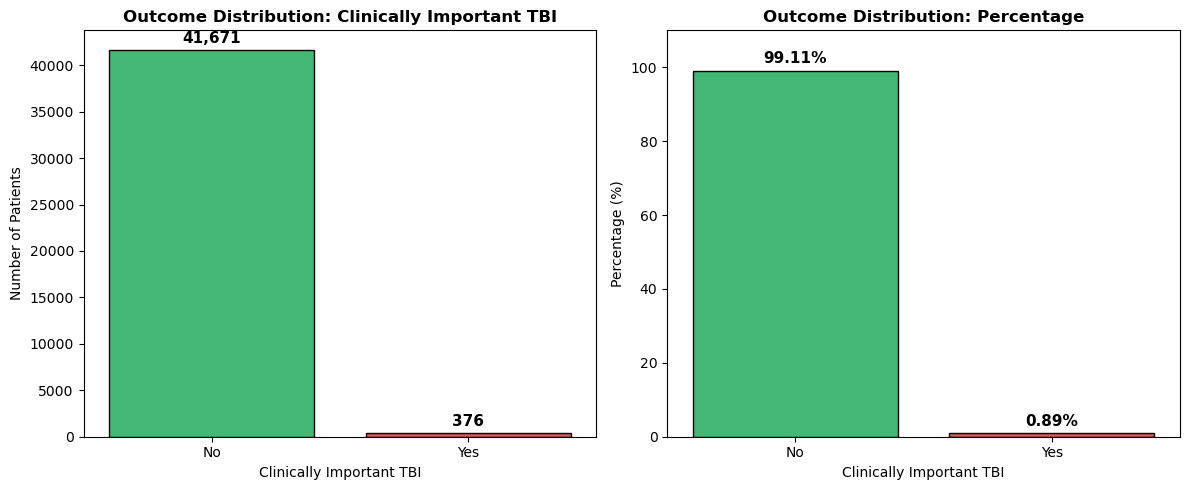

In [18]:
# plot the class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# left panel: count plot
sns.countplot(data=df_prep_mapped, x='clinically_important_tbi',
              hue='clinically_important_tbi', palette=['#2ecc71', '#e74c3c'],
              edgecolor='black', legend=False, ax=axes[0])

# add title
axes[0].set_title('Outcome Distribution: Clinically Important TBI', fontweight='bold')

# set x-label and y-label
axes[0].set_xlabel('Clinically Important TBI')
axes[0].set_ylabel('Number of Patients')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:,.0f}', fontweight='bold', fontsize=11, padding=3)

# right panel: percentage plot
pcts = df_prep_mapped['clinically_important_tbi'].value_counts(normalize=True).sort_index() * 100

# sns barplot takes explicit x and y values
sns.barplot(x=['No', 'Yes'], y=pcts.values,
            hue=['No', 'Yes'], palette=['#2ecc71', '#e74c3c'],
            edgecolor='black', legend=False, ax=axes[1])

axes[1].set_title('Outcome Distribution: Percentage', fontweight='bold')
axes[1].set_xlabel('Clinically Important TBI')
axes[1].set_ylabel('Percentage (%)')

# set_ylim(0, 110) forces the y-axis to go from 0 to 110
# without this, matplotlib auto-scales and the label on the tall bar gets cut off
axes[1].set_ylim(0, 110)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:.2f}%', fontweight='bold', fontsize=11, padding=3)

# tight_layout automatically adjusts spacing between subplots
# so titles, labels, and bars don't overlap each other
plt.tight_layout()

# show() renders and displays the figure
plt.show()

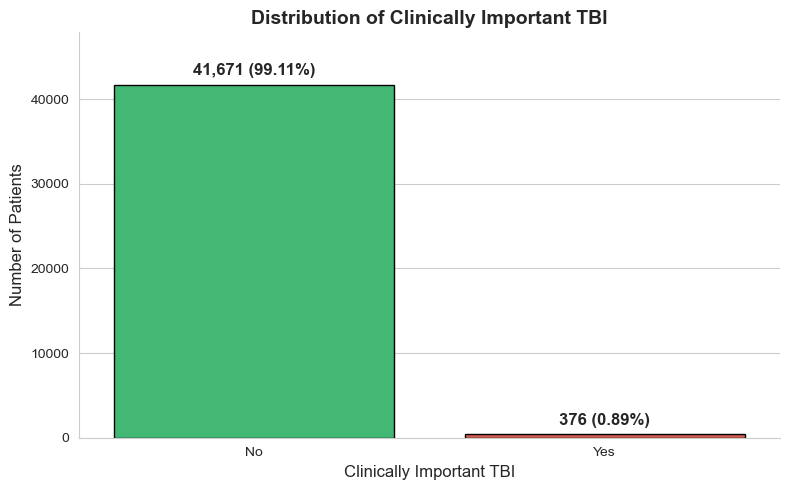

In [19]:
# ── Q1: Outcome Distribution ──

# compute counts and percentages
counts = df_prep['clinically_important_tbi'].value_counts().sort_index()
pcts = df_prep['clinically_important_tbi'].value_counts(normalize=True).sort_index() * 100

# set seaborn style for a cleaner look
# "whitegrid" adds subtle horizontal gridlines on a white background
sns.set_style("whitegrid")

# single figure, not subplots
fig, ax = plt.subplots(figsize=(8, 5))

# create bar plot with the counts
# hue must match x to use palette (seaborn v0.14+ requirement)
sns.barplot(x=['No', 'Yes'], y=counts.values,
            hue=['No', 'Yes'], palette=['#2ecc71', '#e74c3c'],
            edgecolor='black', legend=False, ax=ax)

# add labels that combine count AND percentage on top of each bar
# zip() pairs each bar container with its matching count and percentage
for container, (count, pct) in zip(ax.containers, zip(counts.values, pcts.values)):
    # create custom labels: e.g., "41,834 (99.11%)"
    labels = [f'{count:,} ({pct:.2f}%)']
    ax.bar_label(container, labels=labels, fontweight='bold', fontsize=12, padding=5)

# set y-axis limit with headroom so labels don't get clipped
ax.set_ylim(0, counts.max() * 1.15)

ax.set_title('Distribution of Clinically Important TBI', fontsize=14, fontweight='bold')
ax.set_xlabel('Clinically Important TBI', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)

# remove top and right borders ("spines") for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()


In [74]:
import plotly.graph_objects as go

# ── Q1: Outcome Distribution (Plotly) ──

counts = df_prep['clinically_important_tbi'].value_counts().sort_index()
pcts = df_prep['clinically_important_tbi'].value_counts(normalize=True).sort_index() * 100

# Create custom labels
labels_text = [f'{count:,}<br>({pct:.2f}%)' for count, pct in zip(counts.values, pcts.values)]

fig = go.Figure(data=[
    go.Bar(
        x=['No TBI', 'Yes TBI'],
        y=counts.values,
        text=labels_text,
        textposition='outside',
        textfont=dict(size=12, color='black'),
        marker=dict(
            color=['#2ecc71', '#e74c3c'],
            line=dict(color='black', width=1.5)
        ),
        hovertemplate='<b>%{x}</b><br>Count: %{y:,}<extra></extra>',
        showlegend=False
    )
])

fig.update_layout(
    title={
        'text': 'Distribution of Clinically Important TBI',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16, 'color': '#2c3e50'}
    },
    xaxis=dict(
        title=dict(text='Clinically Important TBI', font=dict(size=13)),
        tickfont=dict(size=12)
    ),
    yaxis=dict(
        title=dict(text='Number of Patients', font=dict(size=13)),
        tickfont=dict(size=12),
        gridcolor='#ecf0f1',
        showgrid=True
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=900,
    height=600,
    margin=dict(l=80, r=80, t=100, b=80),
    font=dict(family='Arial, sans-serif', color='#2c3e50')
)

fig.write_image('../figs/q1_outcome_distribution.pdf', width=1200, height=800)
fig.show()



### Q2: Which individual symptoms/signs are most associated with clinically_important_tbi?

We defined certain key binary clinical features to examine with human judgment call. 

Among these, we calculated:
- of all the patients who had this symptom, what percentage ended up with a clinically important TBI?
- the risk ratio, defined as the ratio of patients with that feature and those without it

From the results, we can see that the strongest predictors: skull_fx_palpable (21.1), basilar_skull_fx (17.9), altered_mental_status (9.7),sedated (7.0), loc (5.5) are roughly aligned with the Kuppermann decision rule.

We also note that sedated, paralyzed, intubated are not predictors, they're clinical interventions applied because the patient is already severly injured. These reflect severity.

The same question was asked but segmented by age groups (<2 and >=2 years old), as Kuppermann did it in the paper. This segmentation makes sense because certain features have more impact dependending on the age group. 

Some insights we found for:
- < 2 years old group:
    - fontanelle_bulging is relevant but not for older children (their fontanelles are closed)
    - headache is not relevant (non-verbal children can't report headaches)
    - skull_fx_palpable has a much higher RR in the < 2 years group (infant skulls are thinner, palpable fracture is a stronger danger signal). 
    - amnesia has a high risk ratio (32.9) vs 4.9 for the >=2 group. However, this is based on a tiny sample (1 TBI case out of 8 patients reporting amnesia), so it should be interpreted with caution
    - neuro_deficit shows a higher RR in infants (8.2 vs 3.0) suggesting neurological signs are a more alarming indicator in younger children

- '>=' 2 years old group:
    - headache and vomiting are stronger signals (this is why Kuppermann includes them only in the older rule)
    - basilar_skull_fx has the highest RR in this group (20.9 vs 8.0 in infants), likely because basilar fracture signs (raccoon eyes, battle sign) are more reliably identified in older children

- Both groups:
    - altered_mental_status is the most robust universal predictor, ranking highly in both age groups (RR: 10.4 for >=2, 8.3 for <2)


In [20]:
df_CITBI = df_prep_mapped[df_prep_mapped['clinically_important_tbi'] == 'Yes']

df_CITBI.groupby(['clinically_important_tbi']).count()

,patient_id,physician_position,physician_certification,injury_mechanism,injury_severity,amnesia,loc,loc_duration,seizure,seizure_timing,seizure_duration,acting_normal,headache,headache_severity,headache_onset,vomiting,vomiting_episodes,vomiting_onset,vomiting_last,dizziness,intubated,paralyzed,sedated,gcs_eye,gcs_verbal,gcs_motor,gcs_total,gcs_group,altered_mental_status,ams_agitated,ams_sleepy,ams_slow_response,ams_repetitive_questions,ams_other,skull_fx_palpable,skull_fx_depressed,fontanelle_bulging,basilar_skull_fx,basilar_fx_hemotympanum,basilar_fx_csf_otorrhea,basilar_fx_raccoon_eyes,basilar_fx_battle_sign,basilar_fx_csf_rhinorrhea,scalp_hematoma,hematoma_location,hematoma_size,trauma_above_clavicles,trauma_face,trauma_neck,trauma_scalp_frontal,trauma_scalp_occipital,trauma_scalp_parietal,trauma_scalp_temporal,neuro_deficit,neuro_deficit_motor,neuro_deficit_sensory,neuro_deficit_cranial,neuro_deficit_reflexes,neuro_deficit_other,other_injuries,other_injury_extremity,other_injury_laceration,other_injury_cspine,other_injury_chest_flank,other_injury_abdomen,other_injury_pelvis,other_injury_other,drug_intoxication,ct_ordered,ct_ind_age,ct_ind_amnesia,ct_ind_mental_status,ct_ind_skull_fracture,ct_ind_headache,ct_ind_hematoma,ct_ind_loc,ct_ind_mechanism,ct_ind_neuro_deficit,ct_ind_md_request,ct_ind_parent_request,ct_ind_trauma_team,ct_ind_seizure,ct_ind_vomiting,ct_ind_xray_fracture,ct_ind_other,ct_sedation,ct_sed_agitation,ct_sed_age,ct_sed_tech_request,ct_sed_other,age_months,age_years,age_group,gender,ethnicity,race,observed_in_ed,ed_disposition,ct_performed,ct_performed_in_ed,tbi_on_ct,finding_cerebellar_hemorrhage,finding_cerebral_contusion,finding_cerebral_edema,finding_cerebral_hemorrhage,finding_skull_diastasis,finding_epidural_hematoma,finding_extraaxial_hematoma,finding_intraventricular_hemorrhage,finding_midline_shift,finding_pneumocephalus,finding_skull_fracture,finding_subarachnoid_hemorrhage,finding_subdural_hematoma,finding_traumatic_infarction,finding_diffuse_axonal_injury,finding_herniation,finding_shear_injury,finding_sigmoid_sinus_thrombosis,death_from_tbi,hospitalized_head_injury,hospitalized_positive_ct,intubated_24h_head,neurosurgery
clinically_important_tbi,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Yes,376,376,376,369,367,335,321,293,350,374,373,273,354,343,345,370,368,370,351,181,374,374,374,365,365,364,376,376,375,376,376,376,376,376,376,373,371,371,376,376,376,376,376,374,374,368,374,376,376,376,376,376,376,366,376,376,376,376,376,374,376,376,376,376,376,376,376,366,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,374,376,376,376,376,376,376,376,376,225,348,342,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376,376


In [21]:
# Define the key binary clinical features to examine (0=No, 1=Yes)
# These are the signs and symptoms a physician would assess in the ED
# These are defined with human judgement call

binary_features = [
    'altered_mental_status', 'loc', 'amnesia', 'seizure',
    'skull_fx_palpable', 'basilar_skull_fx', 'fontanelle_bulging',
    'scalp_hematoma', 'neuro_deficit', 'vomiting', 'headache',
    'acting_normal', 'dizziness', 'drug_intoxication', 'other_injuries',
    'intubated', 'paralyzed', 'sedated'
]

In [22]:
# for each feature, compute:
    # how many patients have the feature present (1) vs absent (0)
    # of those, how many had clinically important tbi
    # the tbi rate (%) for present vs absent

results = []
for feat in binary_features:
    for val, label in [(0, 'Absent'), (1, 'Present')]:
        # filter to rows where this feature equals this value
        subset = df_prep[df_prep[feat] == val]
        n = len(subset)

        # count how many in this subset had TBI = 1
        tbi_count = (subset['clinically_important_tbi'] == 1).sum()

        # compute the rate: what % of this group had TBI
        tbi_rate = (tbi_count / n * 100) if n > 0 else 0

        results.append({
            'feature': feat,
            'status': label,
            'n_patients': n,
            'tbi_count': tbi_count,
            'tbi_rate_pct': round(tbi_rate, 2)
        })


# Convert the list of dictionaries into a dataframe
df_rates = pd.DataFrame(results)


# ── Summary table ──
# pivot reshapes from long format to wide format:
#   rows = features, columns = Absent/Present, values = tbi_rate_pct

pivot = df_rates.pivot(index='feature', columns='status', values='tbi_rate_pct')

# risk_ratio = how many times more likely is TBI when feature is present vs absent
pivot['risk_ratio'] = (pivot['Present'] / pivot['Absent']).round(1)

# sort so the most strongly associated features appear at the top
pivot = pivot.sort_values('risk_ratio', ascending=False)

print("TBI Rate (%) by Feature Presence/Absence:")
print(pivot.to_string())

TBI Rate (%) by Feature Presence/Absence:
status                 Absent  Present  risk_ratio
feature                                           
skull_fx_palpable        0.74    15.62        21.1
basilar_skull_fx         0.80    14.29        17.9
altered_mental_status    0.42     4.08         9.7
sedated                  0.89     6.25         7.0
loc                      0.48     2.64         5.5
amnesia                  0.47     2.30         4.9
drug_intoxication        0.88     4.07         4.6
fontanelle_bulging       0.88     3.85         4.4
seizure                  0.82     3.44         4.2
neuro_deficit            0.85     2.90         3.4
headache                 0.40     1.28         3.2
vomiting                 0.70     2.09         3.0
other_injuries           0.76     2.11         2.8
scalp_hematoma           0.57     1.38         2.4
dizziness                0.63     1.09         1.7
acting_normal            2.39     0.38         0.2
paralyzed                0.90     0.00  

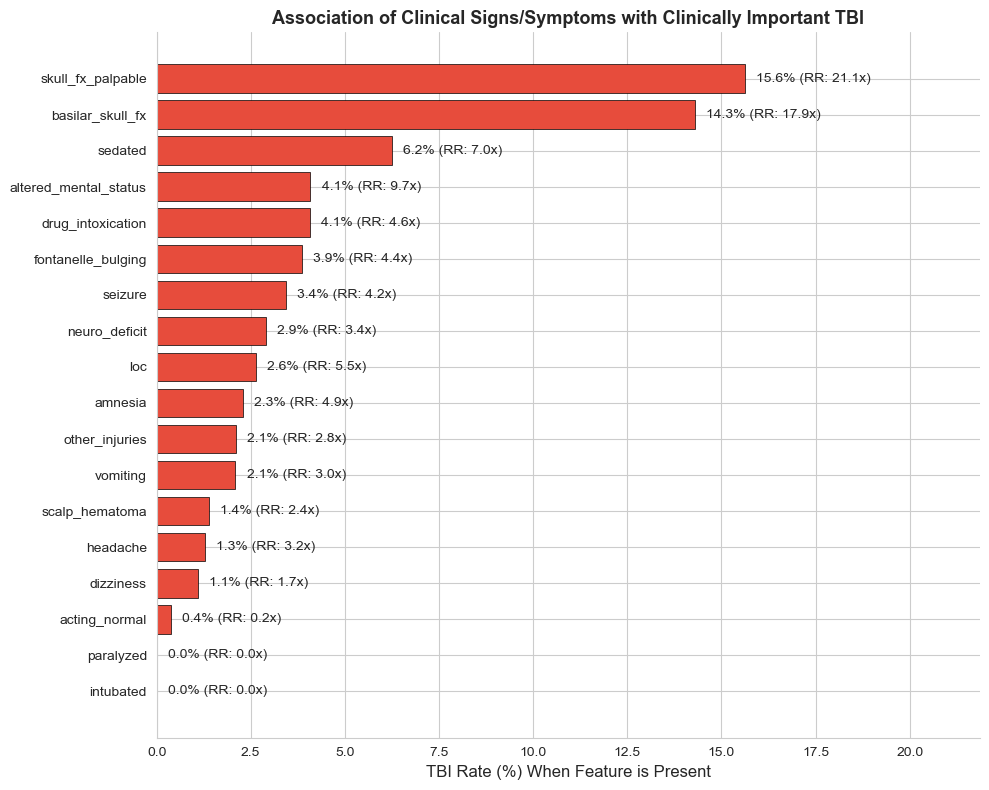

In [23]:
# Q2 Visualization: Horizontal bar chart of TBI rates

sns.set_style("whitegrid")

# sort ascending so highest risk ratio appears at the top of the chart
# (horizontal bar charts read bottom-to-top, so ascending puts the best at top)
present_rates = pivot['Present'].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# barh = horizontal bar chart
# y-axis = feature names, x-axis = TBI rate when feature is present
bars = ax.barh(present_rates.index, present_rates.values,
               color='#e74c3c', edgecolor='black', linewidth=0.5)

# add the percentage and risk ratio as labels at the end of each bar
# pivot.loc[name, 'risk_ratio'] looks up the risk ratio for each feature
for bar, (name, val) in zip(bars, present_rates.items()):
    rr = pivot.loc[name, 'risk_ratio']
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}% (RR: {rr}x)', va='center', fontsize=10)

# set x-axis limit with headroom for the labels
ax.set_xlim(0, present_rates.max() * 1.4)

ax.set_xlabel('TBI Rate (%) When Feature is Present', fontsize=12)
ax.set_title('Association of Clinical Signs/Symptoms with Clinically Important TBI',
             fontsize=13, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()


In [81]:
fig = go.Figure(data=[
    go.Bar(
        y=present_rates.index,
        x=present_rates.values,
        orientation='h',
        text=label_text,
        textposition='outside',
        textfont=dict(size=11, color='black'),
        marker=dict(
            color='#e74c3c',
            line=dict(color='black', width=1)
        ),
        hovertext=hover_text,
        hoverinfo='text',
        showlegend=False
    )
])

# Calculate max x value with headroom for labels
max_x = present_rates.max() * 1.3

fig.update_layout(
    title={
        'text': 'Association of Clinical Signs/Symptoms with Clinically Important TBI',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 15, 'color': '#2c3e50'}
    },
    xaxis=dict(
        title=dict(text='TBI Rate (%) When Feature is Present', font=dict(size=12)),
        tickfont=dict(size=11),
        gridcolor='#ecf0f1',
        showgrid=True,
        range=[0, max_x]  # explicitly set x-axis range with headroom
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=11),
        categoryorder='total ascending'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1200,
    height=700,
    margin=dict(l=250, r=100, t=100, b=80),
    font=dict(family='Arial, sans-serif', color='#2c3e50')
)

fig.write_image('../figs/fig_q2_tbi_by_feature.pdf', width=1200, height=700)
fig.show()


In [24]:
# we repeat the same exercise but we break down by age group
results_by_age = []
# outer loop: iterate through each binary clinical feature
for feat in binary_features:
    # middle loop: iterate through each age group
    for age_label, age_val in [('< 2 years', 1), ('>= 2 years', 2)]:
        # inner loop: feature absent (0) vs present (1)
        for val, status in [(0, 'Absent'), (1, 'Present')]:
            # filter rows where both conditions are true
            subset = df_prep[(df_prep[feat] == val) & (df_prep['age_group'] == age_val)]

            # number of patients in this specific slice
            n = len(subset)

            # of those patients, how many had clinically important TBI
            tbi_count = (subset['clinically_important_tbi'] == 1).sum()

            # convert to a percentage
            tbi_rate = (tbi_count / n * 100) if n > 0 else 0

            # store as a dictionary and append to the results list
            results_by_age.append({
                'feature': feat,
                'age_group': age_label,
                'status': status,
                'n_patients': n,
                'tbi_count': tbi_count,
                'tbi_rate_pct': round(tbi_rate, 2)
            })

# convert the list of dictionaries into a dataframe
df_rates_age = pd.DataFrame(results_by_age)

# pivot into a comparison table
pivot_age = df_rates_age.pivot_table(
    index=['feature', 'age_group'],
    columns='status', 
    values='tbi_rate_pct'
)

# compute risk ratio for each feature within each age group
pivot_age['risk_ratio'] = (pivot_age['Present'] / pivot_age['Absent']).round(1)

# sort by risk ratio descending
pivot_age = pivot_age.sort_values('risk_ratio', ascending=False)

print("TBI Rate (%) by Feature and Age Group:")
print(pivot_age.to_string())

TBI Rate (%) by Feature and Age Group:
status                            Absent  Present  risk_ratio
feature               age_group                              
skull_fx_palpable     < 2 years     0.62    22.95        37.0
amnesia               < 2 years     0.38    12.50        32.9
basilar_skull_fx      >= 2 years    0.77    16.09        20.9
skull_fx_palpable     >= 2 years    0.78    11.11        14.2
altered_mental_status >= 2 years    0.39     4.07        10.4
                      < 2 years     0.50     4.13         8.3
neuro_deficit         < 2 years     0.87     7.14         8.2
basilar_skull_fx      < 2 years     0.88     7.02         8.0
sedated               >= 2 years    0.88     6.90         7.8
seizure               < 2 years     0.83     5.45         6.6
loc                   < 2 years     0.62     4.05         6.5
                      >= 2 years    0.42     2.52         6.0
amnesia               >= 2 years    0.47     2.29         4.9
drug_intoxication     >= 2 year

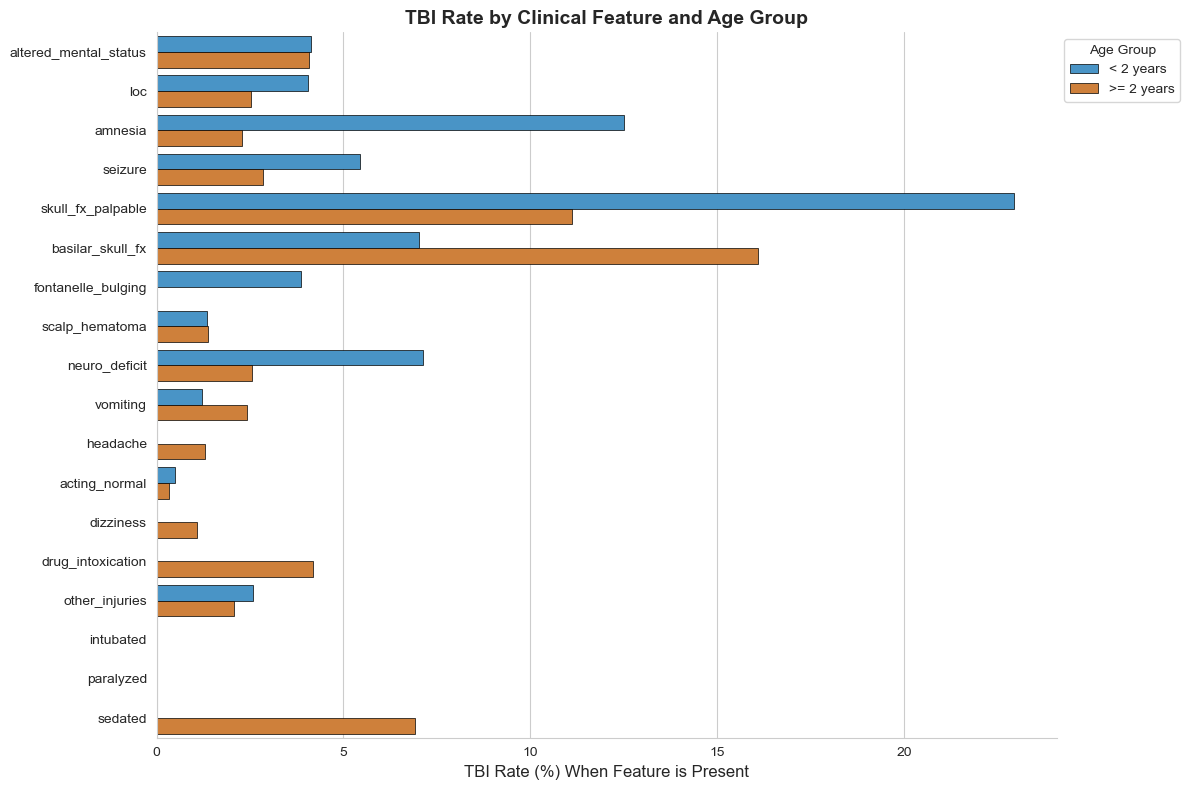

In [25]:
# ── Visualization: Side-by-side comparison of TBI rates by age group ──

sns.set_style("whitegrid")

# filter to only "Present" rows — we want to compare TBI rate when symptom exists
# .copy() avoids the SettingWithCopyWarning when we modify the filtered dataframe
present_only = df_rates_age[df_rates_age['status'] == 'Present'].copy()

# create the figure
fig, ax = plt.subplots(figsize=(12, 8))

# sns.barplot with hue creates grouped bars:
#   - y = feature names on the vertical axis
#   - x = TBI rate on the horizontal axis
#   - hue = age_group splits each feature into two bars side by side
# orient='h' makes it horizontal (easier to read long feature names)
sns.barplot(data=present_only, y='feature', x='tbi_rate_pct',
            hue='age_group', palette=['#3498db', '#e67e22'],
            edgecolor='black', linewidth=0.5, ax=ax)

ax.set_xlabel('TBI Rate (%) When Feature is Present', fontsize=12)
ax.set_ylabel('')
ax.set_title('TBI Rate by Clinical Feature and Age Group',
             fontsize=14, fontweight='bold')

# move the legend to a position that doesn't overlap the bars
# bbox_to_anchor=(x, y) places the legend at coordinates relative to the axes
# (1.0, 1.0) = top-right corner
ax.legend(title='Age Group', bbox_to_anchor=(1.0, 1.0), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()


In [82]:
# improved chart

import plotly.graph_objects as go

# ── Q2 Extended: TBI Rate by Feature and Age Group (Plotly) ──

# Filter to only "Present" rows
present_only = df_rates_age[df_rates_age['status'] == 'Present'].copy()

# Pivot so we have one row per feature with columns for each age group
pivot_age = present_only.pivot(index='feature', columns='age_group', values='tbi_rate_pct')
pivot_age = pivot_age.sort_values('< 2 years', ascending=True)

# Create figure with two traces (one for each age group)
fig = go.Figure()

# Add trace for < 2 years
fig.add_trace(go.Bar(
    y=pivot_age.index,
    x=pivot_age['< 2 years'],
    orientation='h',
    name='< 2 years',
    marker=dict(color='#3498db', line=dict(color='black', width=0.5)),
    text=[f"{val:.1f}%" for val in pivot_age['< 2 years']],
    textposition='outside',
    textfont=dict(size=10, color='black'),
    hovertemplate='<b>%{y}</b><br>< 2 years: %{x:.1f}%<extra></extra>'
))

# Add trace for >= 2 years
fig.add_trace(go.Bar(
    y=pivot_age.index,
    x=pivot_age['>= 2 years'],
    orientation='h',
    name='>= 2 years',
    marker=dict(color='#e67e22', line=dict(color='black', width=0.5)),
    text=[f"{val:.1f}%" for val in pivot_age['>= 2 years']],
    textposition='outside',
    textfont=dict(size=10, color='black'),
    hovertemplate='<b>%{y}</b><br>>= 2 years: %{x:.1f}%<extra></extra>'
))

fig.update_layout(
    title={
        'text': 'TBI Rate by Clinical Feature and Age Group',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 15, 'color': '#2c3e50'}
    },
    xaxis=dict(
        title=dict(text='TBI Rate (%) When Feature is Present', font=dict(size=12)),
        tickfont=dict(size=11),
        gridcolor='#ecf0f1',
        showgrid=True,
        range=[0, pivot_age.max().max() * 1.25]
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=11),
        categoryorder='total ascending'
    ),
    barmode='group',  # side-by-side bars
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1200,
    height=800,
    margin=dict(l=250, r=150, t=100, b=80),
    legend=dict(
        title=dict(text='Age Group', font=dict(size=12)),
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='#2c3e50',
        borderwidth=1,
        font=dict(size=11)
    ),
    font=dict(family='Arial, sans-serif', color='#2c3e50')
)

fig.write_image('../figs/fig_q2_age_stratified_features.pdf', width=1200, height=800)
fig.show()


In [87]:
# ── PLOTLY VERSION: Filtered Q2 Age-Stratified Features Chart ──
import plotly.graph_objects as go

# Filter to only show features up to and including "headache"
# These are the features in order of appearance in the data
features_to_keep = [
    'altered_mental_status', 'loc', 'amnesia', 'seizure',
    'skull_fx_palpable', 'basilar_skull_fx', 'fontanelle_bulging',
    'scalp_hematoma', 'neuro_deficit', 'vomiting', 'headache'
]

# Prepare data: filter to Present status and selected features
present_only = df_rates_age[df_rates_age['status'] == 'Present'].copy()
present_filtered = present_only[present_only['feature'].isin(features_to_keep)].copy()

# Create pivot table with age groups as columns
pivot_age = present_filtered.pivot(index='feature', columns='age_group', values='tbi_rate_pct')

# Sort by the "< 2 years" column to show highest risk features first
pivot_age = pivot_age.sort_values('< 2 years', ascending=True)

# Create figure
fig = go.Figure()

# Add bars for each age group
age_groups = ['< 2 years', '>= 2 years']
colors = ['#3498db', '#e67e22']

for idx, age_group in enumerate(age_groups):
    fig.add_trace(go.Bar(
        y=pivot_age.index,
        x=pivot_age[age_group],
        name=age_group,
        marker=dict(color=colors[idx]),
        text=pivot_age[age_group].round(1),
        textposition='outside',
        orientation='h'
    ))

# Update layout for publication quality
fig.update_layout(
    title=dict(text='TBI Rate by Clinical Feature and Age Group (When Present)', 
               font=dict(size=16, family='Arial')),
    xaxis=dict(
        title='TBI Rate (%)',
        title_font=dict(size=12),
        range=[0, max(pivot_age.max()) * 1.15],
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(
        title='',
        title_font=dict(size=12)
    ),
    barmode='group',
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1400,
    height=700,
    margin=dict(l=250, r=100, t=100, b=80),
    legend=dict(
        title='Age Group',
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.8)'
    )
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')
fig.show()

# Export as PDF for LaTeX
fig.write_image('../figs/q2_age_stratified_features.pdf', width=1400, height=700)
print("✓ Exported Q2 figure to q2_age_stratified_features.pdf")


✓ Exported Q2 figure to q2_age_stratified_features.pdf


In [26]:
# How many infants under 2 have amnesia = 1?
subset = df_prep[(df_prep['amnesia'] == 1) & (df_prep['age_group'] == 1)]
print(f"Infants < 2 with amnesia=Present: {len(subset)} patients")
print(f"Of those with TBI: {(subset['clinically_important_tbi'] == 1).sum()}")


Infants < 2 with amnesia=Present: 8 patients
Of those with TBI: 1


### Q3: Does age group (age_group: <2 vs >=2) show different injury rates?

Building from the previous question, now we want to ask "does the patient's age itself affect TBI likelihood"

Specifically:
- Overall TBI rate by age group (<2 vs >= 2)
- TBI rate by individual age (0, 1, ... , 17)
- Whether the <2 vs >= 2 split is the right cutoff (of if the data suggests a different breakpoint)

Insight:
The TBI rate is remarkably uniform across age groups: 0.92% for children < 2 years and 0.89% for children >= 2 years. The per-year breakdown shows rates fluctuating narrowly between 0.53% and 1.46% with no clear trend — age alone is not a strong predictor of clinically important TBI.

This finding is itself significant: it explains why the Kuppermann decision rule splits by age group not because one group has higher TBI risk, but because the clinical features that predict TBI differ by age (as shown in Q2). The age split is about which symptoms to evaluate, not about baseline risk.

The one subtle pattern is that age 0 (infants < 1 year) shows the highest rate at 1.25%, roughly double that of ages 1-5. This is consistent with increased vulnerability in the youngest infants.

In [27]:
# group by age_group 

age_group_stats = df_prep.groupby('age_group')['clinically_important_tbi'].agg(['count', 'sum'])
age_group_stats.columns = ['n_patients', 'tbi_count']

# compute TBI rate as a percentage
age_group_stats['tbi_rate_pct'] = (age_group_stats['tbi_count'] / age_group_stats['n_patients'] * 100).round(2)

# rename the index values
age_group_stats.index = ['< 2 years', '>= 2 years']

print("TBI Rate by Age Group")
print(age_group_stats)

TBI Rate by Age Group
            n_patients  tbi_count  tbi_rate_pct
< 2 years        10656         98          0.92
>= 2 years       31391        278          0.89


In [28]:
# TBI rate by individual age 
# this shows the full age curve, are infants at higher risk? teens? toddlers?

age_year_stats = df_prep.groupby('age_years')['clinically_important_tbi'].agg(['count', 'sum'])

age_year_stats.columns = ['n_patients', 'tbi_count']

age_year_stats['tbi_rate_pct'] = (age_year_stats['tbi_count'] / age_year_stats['n_patients'] * 100).round(2)

print("TBI Rate by Age (Years):")
print(age_year_stats)

TBI Rate by Age (Years):
           n_patients  tbi_count  tbi_rate_pct
age_years                                     
0                5343         67          1.25
1                5313         31          0.58
2                3752         22          0.59
3                2824         15          0.53
4                2368         14          0.59
5                2111         13          0.62
6                1928         23          1.19
7                1735         17          0.98
8                1521          8          0.53
9                1464         16          1.09
10               1502         14          0.93
11               1562         15          0.96
12               1670         18          1.08
13               1715         25          1.46
14               1876         19          1.01
15               1855         21          1.13
16               1885         18          0.95
17               1623         20          1.23


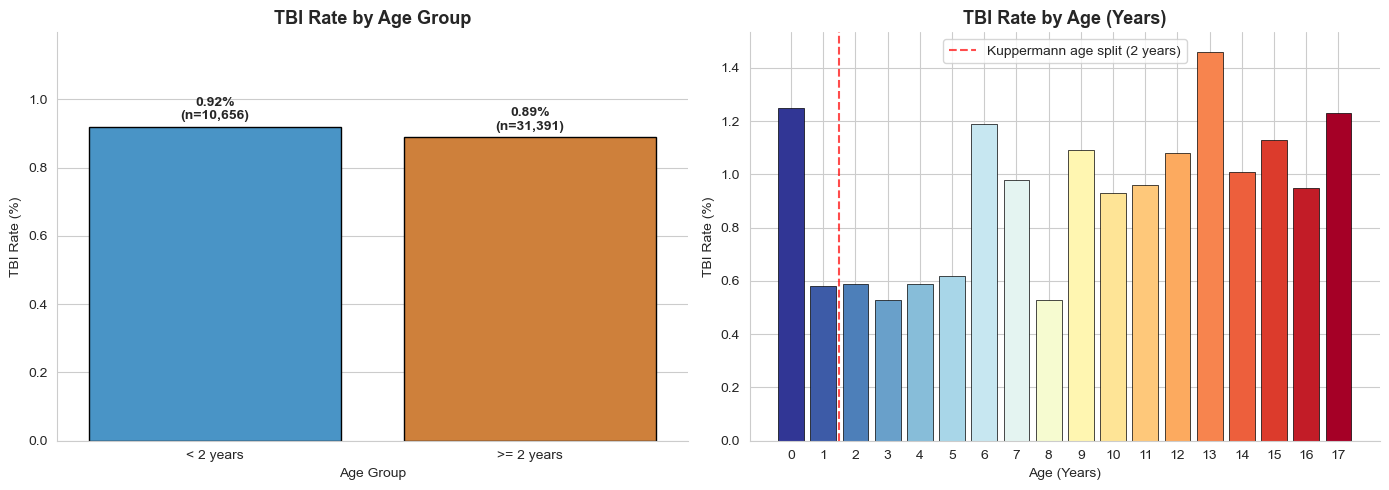

In [29]:
# ── Q3 Visualization ──

sns.set_style("whitegrid")

# 2 panels side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: TBI rate by age group (bar chart) ──

# simple comparison of two groups
sns.barplot(x=['< 2 years', '>= 2 years'], y=age_group_stats['tbi_rate_pct'].values,
            hue=['< 2 years', '>= 2 years'], palette=['#3498db', '#e67e22'],
            edgecolor='black', legend=False, ax=axes[0])

axes[0].set_title('TBI Rate by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('TBI Rate (%)')

# add labels showing rate and sample size
# zip pairs each bar with its corresponding row from the stats table
for container, (label, row) in zip(axes[0].containers, age_group_stats.iterrows()):
    # f-string builds label like "0.89% (n=10,123)"
    labels = [f'{row["tbi_rate_pct"]:.2f}%\n(n={row["n_patients"]:,})']
    axes[0].bar_label(container, labels=labels, fontweight='bold', fontsize=10, padding=3)

# add headroom for labels
axes[0].set_ylim(0, age_group_stats['tbi_rate_pct'].max() * 1.3)

# ── Right panel: TBI rate by individual age (line + bar) ──

# bar chart shows the rate at each age
# color gradient from blue (young) to orange (old) using a colormap
# plt.cm.RdYlBu_r is a reversed Red-Yellow-Blue colormap
# we generate one color per age by sampling evenly across the colormap
colors = [plt.cm.RdYlBu_r(i / 17) for i in range(18)]

axes[1].bar(age_year_stats.index, age_year_stats['tbi_rate_pct'], color=colors, edgecolor='black', linewidth=0.5)

# add a vertical dashed line at age 2 to show the Kuppermann split point
# linestyle='--' makes it dashed
# alpha=0.7 makes it slightly transparent
# label= adds text for the legend
axes[1].axvline(x=1.5, color='red', linestyle='--', alpha=0.7, label='Kuppermann age split (2 years)')

axes[1].set_title('TBI Rate by Age (Years)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (Years)')
axes[1].set_ylabel('TBI Rate (%)')

# set x-axis ticks to show every age (0, 1, 2, ..., 17)
# without this, matplotlib might skip some ages
axes[1].set_xticks(range(18))

# show the legend for the vertical line
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()


In [88]:
# improved chart
# ── Q3 Visualization: TBI Rate by Age (Years) ──
import plotly.graph_objects as go

# Bar chart shows the rate at each age
# Create color gradient from blue (young) to orange (old)
colors = ['#3498db' if age < 2 else '#e67e22' for age in age_year_stats.index]

fig = go.Figure()

# Add bars for each age
fig.add_trace(go.Bar(
    x=age_year_stats.index,
    y=age_year_stats['tbi_rate_pct'],
    marker=dict(color=colors, line=dict(color='black', width=0.5)),
    text=age_year_stats['tbi_rate_pct'].round(2),
    textposition='outside',
    hovertemplate='<b>Age %{x} years</b><br>TBI Rate: %{y:.2f}%<extra></extra>'
))

# Add vertical line at age 2 to show Kuppermann split point
fig.add_vline(
    x=1.5,
    line_dash='dash',
    line_color='red',
    opacity=0.7,
    annotation_text='Kuppermann age split (2 years)',
    annotation_position='top right'
)

# Update layout for publication quality
fig.update_layout(
    title=dict(text='TBI Rate by Age (Years)', 
               font=dict(size=16, family='Arial')),
    xaxis=dict(
        title='Age (Years)',
        title_font=dict(size=12),
        tickmode='linear',
        tick0=0,
        dtick=1
    ),
    yaxis=dict(
        title='TBI Rate (%)',
        title_font=dict(size=12)
    ),
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=900,
    height=600,
    margin=dict(l=80, r=80, t=100, b=80),
    showlegend=False
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')

fig.show()

# Export as PDF for LaTeX
fig.write_image('../figs/q3_tbi_rate_by_age.pdf', width=900, height=600)
print("✓ Exported Q3 figure to q3_tbi_rate_by_age.pdf")


✓ Exported Q3 figure to q3_tbi_rate_by_age.pdf


### Q4: Does injury_mechanism relate to outcomes?

Higher-energy mechanisms show the highest TBI rates: pedestrian struck by vehicle, bike rider struck by auto, and other wheeled transport crashes all exceed 2% — roughly 3× the overall base rate.

Injury severity confirms this: high-severity mechanisms have a 2.38% TBI rate versus <1% for all others, making it one of the clearest binary splits in the dataset.

The age group segmentation reveals a logical pattern: in the <2 year group, occupant in motor vehicle and assault/object struck head are more prominent — these are things that happen to infants. In the >=2 year group, mechanisms involve activities younger children can't perform (biking, skating, wheeled transport).

In [30]:
# injury mechanism has 8 categories

print("Injury mechanism categories:")
print(df_prep_mapped['injury_mechanism'].value_counts())

Injury mechanism categories:
injury_mechanism
Fall from an elevation              11665
Fall to ground from standing/        4499
Occupant in motor vehicle            3717
Other mechanism                      3397
Object struck head - accidental      3124
Assault                              2981
Sports                               2934
Fall down stairs                     2858
Walked or ran into stationary        2263
Bike collision or fall from bike     1668
Pedestrian struck by moving          1303
Other wheeled transport crash         852
Bike rider struck by automobile       524
Name: count, dtype: int64


In [31]:
# TBI rate by injury mechanism

# group by injury_mechanism code, aggregate the outcome column
mech_stats = df_prep.groupby('injury_mechanism')['clinically_important_tbi'].agg(['count', 'sum'])
mech_stats.columns = ['n_patients', 'tbi_count']
mech_stats['tbi_rate_pct'] = (mech_stats['tbi_count'] / mech_stats['n_patients'] * 100).round(2)

# map the index from codes to readable labels
mech_stats.index = mech_stats.index.map(all_variable_maps['InjuryMech'])

# sort by TBI rate descending
mech_stats = mech_stats.sort_values('tbi_rate_pct', ascending=False)

print("TBI Rate by Injury Mechanism:")
print(mech_stats)

TBI Rate by Injury Mechanism:
                                  n_patients  tbi_count  tbi_rate_pct
injury_mechanism                                                     
Pedestrian struck by moving             1303         36          2.76
Bike rider struck by automobile          524         14          2.67
Other wheeled transport crash            852         20          2.35
Occupant in motor vehicle               3717         56          1.51
Bike collision or fall from bike        1668         17          1.02
Other mechanism                         3397         31          0.91
Fall from an elevation                 11665        105           0.9
Object struck head - accidental         3124         24          0.77
Sports                                  2934         19          0.65
Assault                                 2981         15           0.5
Fall to ground from standing/           4499         18           0.4
Fall down stairs                        2858         11     

In [32]:
# TBI rate by injury severity
# injury_severity captures whether the mechanism was high vs low impact

sev_stats = df_prep.groupby('injury_severity')['clinically_important_tbi'].agg(['count', 'sum'])
sev_stats.columns = ['n_patients', 'tbi_count']

sev_stats['tbi_rate_pct'] = (sev_stats['tbi_count'] / sev_stats['n_patients'] * 100).round(2)

# map the index to readable labels
sev_stats.index = sev_stats.index.map(all_variable_maps['High_impact_InjSev'])

# sort by TBI rate descending
sev_stats = sev_stats.sort_values('tbi_rate_pct', ascending=False)

print("\nTBI Rate by Injury Severity:")
print(sev_stats)


TBI Rate by Injury Severity:
                 n_patients  tbi_count  tbi_rate_pct
injury_severity                                     
High                   6263        149          2.38
Moderate              28730        197          0.69
Low                    6762         21          0.31


In [33]:
# injury mechanism by age group
# does mechanism matter differently for young vs older children?

mech_age_stats = (df_prep.groupby(['injury_mechanism', 'age_group'])['clinically_important_tbi']).agg(['count', 'sum'])

mech_age_stats.columns = ['n_patients', 'tbi_count']

mech_age_stats['tbi_rate_pct'] = (mech_age_stats['tbi_count'] / mech_age_stats['n_patients'] * 100).round(2)

# rename ONLY level 0 (injury_mechanism) of the MultiIndex
# .set_levels() replaces the labels for a specific level
# level=0 targets injury_mechanism, level=1 would target age_group
new_mech_labels = mech_age_stats.index.get_level_values(0).map(all_variable_maps['InjuryMech'])
new_age_labels = mech_age_stats.index.get_level_values(1).map({1: '< 2 years', 2: '>= 2 years'})

# rebuild the MultiIndex with the mapped labels
mech_age_stats.index = pd.MultiIndex.from_arrays(
    [new_mech_labels, new_age_labels],
    names=['injury_mechanism', 'age_group']
)

mech_age_stats = mech_age_stats.sort_values('tbi_rate_pct', ascending=False)

print("\nTBI Rate by Injury Mechanism and Age Group:")
print(mech_age_stats.to_string())


TBI Rate by Injury Mechanism and Age Group:
                                             n_patients  tbi_count  tbi_rate_pct
injury_mechanism                 age_group                                      
Assault                          < 2 years           70          3          4.29
Occupant in motor vehicle        < 2 years          254          9          3.54
Pedestrian struck by moving      >= 2 years        1255         35          2.79
Bike rider struck by automobile  >= 2 years         521         14          2.69
Other wheeled transport crash    >= 2 years         807         20          2.48
Pedestrian struck by moving      < 2 years           48          1          2.08
Object struck head - accidental  < 2 years          519          8          1.54
Occupant in motor vehicle        >= 2 years        3463         47          1.36
Bike collision or fall from bike >= 2 years        1649         17          1.03
Other mechanism                  < 2 years          768         

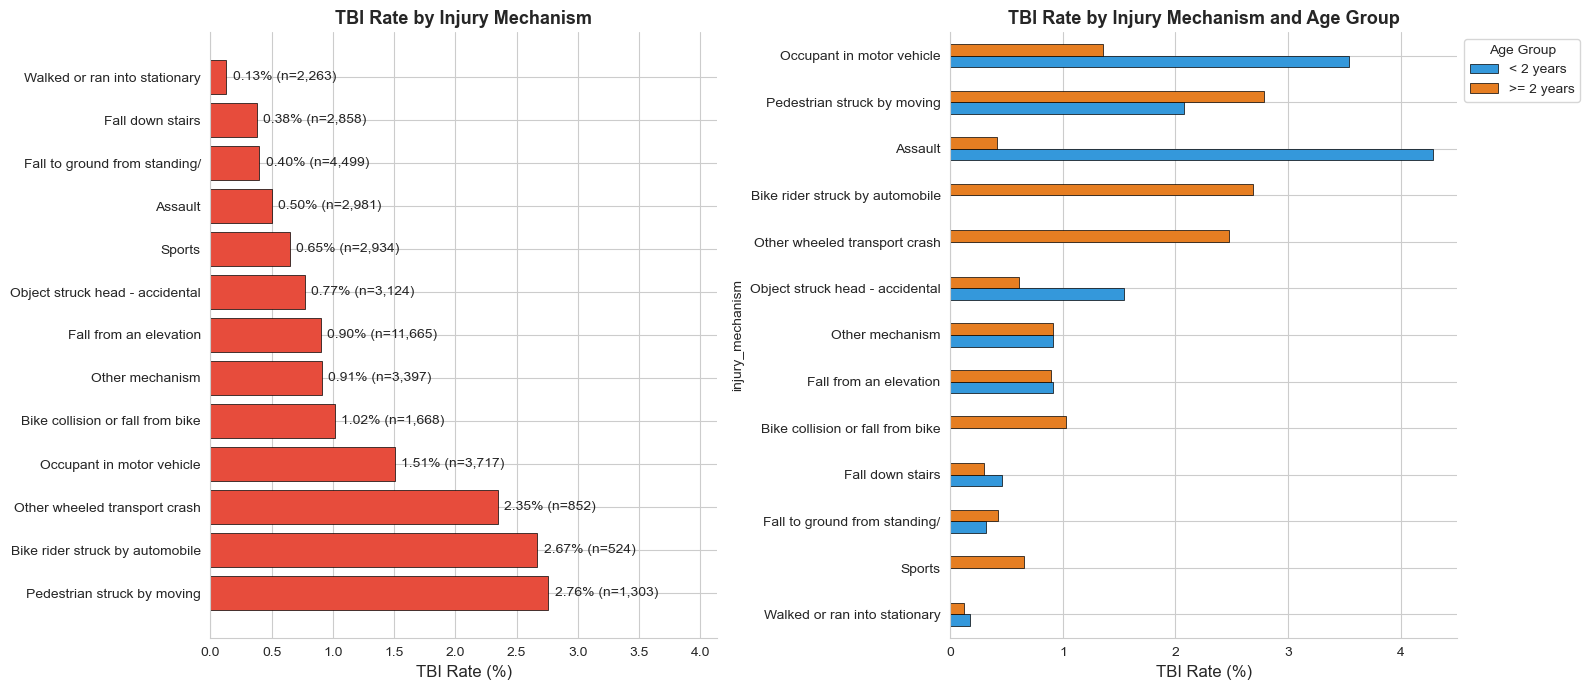

In [34]:
# ── Q4 Visualization ──

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left panel: TBI rate by injury mechanism ──

# we need readable labels for the x-axis
# build a mapping from code → short label for the plot
# these come from the data dictionary
mech_labels = {
    1: 'Fall from\nstanding',
    2: 'Walked into\nobject',
    3: 'Fall from\nelevation',
    4: 'Fall down\nstairs',
    5: 'Motor vehicle\ncrash',
    6: 'Struck by\nobject',
    7: 'Bike/skate\ncrash',
    8: 'Other'
}

# .index gives us the mechanism codes from mech_stats
# we map each code to its readable label using a list comprehension
# list comprehension: [expression for item in iterable]
# mech_labels.get(code, code) looks up the label, falls back to the code if not found
x_labels = [mech_labels.get(code, code) for code in mech_stats.index]

# horizontal bar chart — easier to read long category names
bars = axes[0].barh(x_labels, mech_stats['tbi_rate_pct'].values,
                     color='#e74c3c', edgecolor='black', linewidth=0.5)

# add labels at end of each bar showing rate and sample size
for bar, (idx, row) in zip(bars, mech_stats.iterrows()):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 f'{row["tbi_rate_pct"]:.2f}% (n={row["n_patients"]:,})',
                 va='center', fontsize=10)

# add headroom for labels
axes[0].set_xlim(0, mech_stats['tbi_rate_pct'].max() * 1.5)
axes[0].set_xlabel('TBI Rate (%)', fontsize=12)
axes[0].set_title('TBI Rate by Injury Mechanism', fontsize=13, fontweight='bold')

# ── Right panel: TBI rate by injury mechanism, split by age group ──

# pivot the age-segmented data into a format seaborn can plot
# we need: one row per mechanism, columns for each age group's TBI rate
mech_age_pivot = mech_age_stats['tbi_rate_pct'].unstack('age_group')

# rename columns from 1/2 to readable labels
mech_age_pivot.columns = ['< 2 years', '>= 2 years']

# sort by the overall rate (average of both groups) so most dangerous is on top
mech_age_pivot['avg'] = mech_age_pivot.mean(axis=1)
mech_age_pivot = mech_age_pivot.sort_values('avg', ascending=True)

# .drop(columns='avg') removes the helper column before plotting
# we don't want to plot the average, it was just for sorting
plot_data = mech_age_pivot.drop(columns='avg')

# .plot(kind='barh') creates a horizontal grouped bar chart
# each mechanism gets two bars: one blue (< 2), one orange (>= 2)
plot_data.plot(kind='barh', ax=axes[1], color=['#3498db', '#e67e22'],
               edgecolor='black', linewidth=0.5)

# map the index (mechanism codes) to readable labels for the y-axis
y_labels = [mech_labels.get(code, str(code)) for code in plot_data.index]
axes[1].set_yticklabels(y_labels)

axes[1].set_xlabel('TBI Rate (%)', fontsize=12)
axes[1].set_title('TBI Rate by Injury Mechanism and Age Group', fontsize=13, fontweight='bold')
axes[1].legend(title='Age Group', bbox_to_anchor=(1.0, 1.0), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()


In [89]:
# ── Q4 Visualization: TBI Rate by Injury Mechanism and Age Group ──
import plotly.graph_objects as go

# Prepare data
mech_age_pivot = mech_age_stats['tbi_rate_pct'].unstack('age_group')
mech_age_pivot.columns = ['< 2 years', '>= 2 years']

# Sort by average rate across both age groups
mech_age_pivot['avg'] = mech_age_pivot.mean(axis=1)
mech_age_pivot = mech_age_pivot.sort_values('avg', ascending=True)
plot_data = mech_age_pivot.drop(columns='avg')

# Mechanism code to label mapping
mech_labels = {
    1: 'Fall from standing',
    2: 'Walked into object',
    3: 'Fall from elevation',
    4: 'Fall down stairs',
    5: 'Motor vehicle crash',
    6: 'Struck by object',
    7: 'Bike/skate crash',
    8: 'Other'
}

# Map codes to readable labels
y_labels = [mech_labels.get(code, str(code)) for code in plot_data.index]

# Create figure
fig = go.Figure()

# Add bars for each age group
age_groups = ['< 2 years', '>= 2 years']
colors = ['#3498db', '#e67e22']

for idx, age_group in enumerate(age_groups):
    fig.add_trace(go.Bar(
        y=y_labels,
        x=plot_data[age_group],
        name=age_group,
        marker=dict(color=colors[idx], line=dict(color='black', width=0.5)),
        text=plot_data[age_group].round(2),
        textposition='outside',
        orientation='h'
    ))

# Update layout for publication quality
fig.update_layout(
    title=dict(text='TBI Rate by Injury Mechanism and Age Group', 
               font=dict(size=16, family='Arial')),
    xaxis=dict(
        title='TBI Rate (%)',
        title_font=dict(size=12),
        range=[0, plot_data.max().max() * 1.2],
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(
        title='',
        title_font=dict(size=12)
    ),
    barmode='group',
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1000,
    height=700,
    margin=dict(l=200, r=100, t=100, b=80),
    legend=dict(
        title='Age Group',
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.8)'
    )
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')
fig.show()

# Export as PDF for LaTeX
fig.write_image('../figs/q4_injury_mechanism_by_age.pdf', width=1000, height=700)
print("✓ Exported Q4 figure to q4_injury_mechanism_by_age.pdf")


✓ Exported Q4 figure to q4_injury_mechanism_by_age.pdf


In [35]:
# follow up question after looking at the previous graph: Do the rare TBI cases from trivial mechanisms have other warning signs?

# lets filter to patients with walked/ran into stationary object AND positive TBI

trivial_tbi = df_prep[
    (df_prep['injury_mechanism'] == 2) &
    (df_prep['clinically_important_tbi'] == 1)
]

print(f"Patients with trivial mechanism + TBI: {len(trivial_tbi)}")

# check what other symptoms these patients had
# look at the key Kuppermann features
key_features = [
    'altered_mental_status', 'skull_fx_palpable', 'basilar_skull_fx',
    'loc', 'scalp_hematoma', 'acting_normal', 'vomiting',
    'headache', 'seizure', 'neuro_deficit'
]

# for each patient, show which warning signs were present
# .T transposes the table so features are rows and patients are columns
# easier to read when you have few patients but many features
print("\nWarning signs present in these patients:")
print(df_prep_mapped.loc[trivial_tbi.index, key_features].T.to_string())




Patients with trivial mechanism + TBI: 36

Warning signs present in these patients:
                           60    2008  2845  4031       4939          5712  10644 10790                  10884 11800 11903      14144                  14726 14787      16463 18657                  19407 20564 20773 21144 26182      28034 29093                  30041 30772 31010                  31266      34636 35291 37585 37799 38535 39894      40342      41916      42492
altered_mental_status        Yes    No   Yes    No         No           Yes   Yes    No                    Yes    No   Yes        Yes                    Yes    No        Yes    No                     No    No   Yes   Yes    No        Yes   Yes                    Yes   Yes   Yes                    Yes        Yes   Yes   Yes    No   Yes   Yes        Yes        Yes         No
skull_fx_palpable             No    No    No    No         No  Unclear exam    No    No                     No    No    No         No                     No    No  

In [36]:
# for each feature, count how many of the trivial TBI patients had symptomps present (1) vs absent (0)
# then compute the percentage within this subset

results = []
for feat in key_features:
    # count occurrences for each unique value
    counts = trivial_tbi[feat].value_counts()

    # .get(value, default) safely retrieves the count
    # if no patients had value = 1, it returns 0 instead of crashing
    present = counts.get(1,0)
    absent = counts.get(0,0)

    # total for percentage calculation
    total = present + absent

    results.append({
        'feature': feat, 
        'present_count': present,
        'absent_count': absent,
        'present_pct': round(present / total * 100, 1) if total > 0 else 0
    })

# convert to dataframe 
df_trivial_symptoms = pd.DataFrame(results).sort_values('present_pct', ascending=False)

print("Symptom distribution among trivial-mechanism TBI patients:")
print(df_trivial_symptoms.to_string(index=False))

# this validates the Kuppermann clinical decision rule


Symptom distribution among trivial-mechanism TBI patients:
              feature  present_count  absent_count  present_pct
       scalp_hematoma             25            11         69.4
altered_mental_status             24            12         66.7
                  loc             14            10         58.3
             headache             17            14         54.8
        acting_normal             12            12         50.0
             vomiting              7            29         19.4
     basilar_skull_fx              4            32         11.1
        neuro_deficit              3            33          8.3
    skull_fx_palpable              1            33          2.9
              seizure              0            33          0.0


In [37]:
# ── Kuppermann features mapped to dataset columns ──

# CHILDREN < 2 YEARS
kuppermann_under2 = {
    # Tier 1
    'altered_mental_status': 'binary',           # AMS == 1 (includes GCS=14)
    'skull_fx_palpable': 'binary',               # == 1
    # Tier 2
    'hematoma_location': 'non-frontal only',     # must be occipital/parietal/temporal, NOT frontal
    'loc_duration': 'threshold',                 # LOC >= 5 seconds (not just any LOC)
    'injury_severity': 'high impact only',       # severe mechanism (code depends on mapping)
    'acting_normal': 'inverted',                 # acting_normal == 0 means NOT normal (bad)
}

# CHILDREN >= 2 YEARS  
kuppermann_over2 = {
    # Tier 1
    'altered_mental_status': 'binary',           # same
    'basilar_skull_fx': 'binary',                # == 1
    # Tier 2
    'loc': 'binary',                             # ANY loc (no duration threshold)
    'vomiting': 'binary',                        # == 1
    'injury_severity': 'high impact only',       # severe mechanism (different fall height)
    'headache_severity': 'severe only',          # only SEVERE headache counts
}

In [38]:
# Kuppermann missed cases: patients with TBI but no Kuppermann warning signs

# under 2 years
# filter to TBI positive patients under 2
tbi_under2 = df_prep[
    (df_prep['clinically_important_tbi'] == 1) &
    (df_prep['age_group'] == 1)
]

# apply the exact Kuppermann <2 rule:
# a patient is "caught" if ANY of these are true:
#   Tier 1: altered_mental_status == 1, OR skull_fx_palpable == 1
#   Tier 2: hematoma_location is non-frontal (not 1=frontal, and not 92=not applicable),
#           OR loc_duration >= 2 (code 2 = 5-60s, 3 = 1-5min, 4 = >5min — i.e., >= 5 seconds),
#           OR injury_severity == 1 (high/severe),
#           OR acting_normal == 0 (NOT acting normal = risk)

caught_under2 = tbi_under2[
    (tbi_under2['altered_mental_status'] == 1) |
    (tbi_under2['skull_fx_palpable'] == 1) |
    # non-frontal hematoma: location exists AND is not frontal (1) and not N/A (92)
    ((tbi_under2['hematoma_location'] != 92) & (tbi_under2['hematoma_location'] != 1)) |
    # LOC >= 5 seconds: loc_duration code >= 2 (check mapping to confirm)
    (tbi_under2['loc_duration'] >= 2) |
    # severe injury mechanism
    (tbi_under2['injury_severity'] == 1) |
    # not acting normally (acting_normal == 0 means NOT normal)
    (tbi_under2['acting_normal'] == 0)
]

missed_under2 = tbi_under2[~tbi_under2.index.isin(caught_under2.index)]

print("═══ Children < 2 years ═══")
print(f"Total TBI patients: {len(tbi_under2)}")
print(f"Caught by Kuppermann: {len(caught_under2)}")
print(f"Missed: {len(missed_under2)}")
print(f"Sensitivity: {len(caught_under2) / len(tbi_under2) * 100:.1f}%")


═══ Children < 2 years ═══
Total TBI patients: 98
Caught by Kuppermann: 98
Missed: 0
Sensitivity: 100.0%


In [39]:
# ── 2 years and older ──

# filter to TBI-positive patients >= 2
tbi_over2 = df_prep[
    (df_prep['clinically_important_tbi'] == 1) &
    (df_prep['age_group'] == 2)
]

# apply the EXACT Kuppermann >=2 rule:
#   Tier 1: altered_mental_status == 1, OR basilar_skull_fx == 1
#   Tier 2: loc == 1 (any LOC, no duration threshold),
#           OR vomiting == 1,
#           OR injury_severity == 1 (high/severe),
#           OR headache_severity == severe only (check mapping for the code)

caught_over2 = tbi_over2[
    (tbi_over2['altered_mental_status'] == 1) |
    (tbi_over2['basilar_skull_fx'] == 1) |
    # any loss of consciousness
    (tbi_over2['loc'] == 1) |
    # any vomiting
    (tbi_over2['vomiting'] == 1) |
    # severe injury mechanism
    (tbi_over2['injury_severity'] == 1) |
    # severe headache only — check your mapping: which code = "Severe"?
    # likely headache_severity == 3 or similar, verify with:
    # print(all_variable_maps['HASeverity'])
    (tbi_over2['headache_severity'] == 3)
]

missed_over2 = tbi_over2[~tbi_over2.index.isin(caught_over2.index)]

print("\n═══ Children >= 2 years ═══")
print(f"Total TBI patients: {len(tbi_over2)}")
print(f"Caught by Kuppermann: {len(caught_over2)}")
print(f"Missed: {len(missed_over2)}")
print(f"Sensitivity: {len(caught_over2) / len(tbi_over2) * 100:.1f}%")



═══ Children >= 2 years ═══
Total TBI patients: 278
Caught by Kuppermann: 246
Missed: 32
Sensitivity: 88.5%


In [40]:
# What do the missed patients look like?

# combine missed from both groups
all_missed = pd.concat([missed_under2, missed_over2])

print(f"\n═══ Profile of ALL {len(all_missed)} missed patients ═══")
print("\nAge distribution:")
print(all_missed['age_years'].value_counts().sort_index().to_string())


═══ Profile of ALL 32 missed patients ═══

Age distribution:
age_years
2     3
3     3
5     1
6     4
7     1
9     5
10    1
11    3
12    2
13    2
14    1
15    1
16    3
17    2


In [41]:
print("\nInjury mechanism:")
print(all_missed['injury_mechanism'].map(all_variable_maps['InjuryMech']).value_counts().to_string())


Injury mechanism:
injury_mechanism
Pedestrian struck by moving         5
Fall from an elevation              5
Sports                              4
Bike collision or fall from bike    4
Occupant in motor vehicle           4
Object struck head - accidental     3
Bike rider struck by automobile     2
Other wheeled transport crash       2
Fall down stairs                    1
Assault                             1
Other mechanism                     1


In [42]:
# ── Profile of 32 missed patients (>= 2 years only) ──

# first, let's confirm what Kuppermann checks for >=2:
# Tier 1: altered_mental_status == 1, basilar_skull_fx == 1
# Tier 2: loc == 1, vomiting == 1, injury_severity == 1, headache_severity == severe
# If ALL of these are negative, Kuppermann says "no CT needed"
# So by definition, these 32 patients have NONE of the above.

print(f"Total missed patients (>= 2 years): {len(missed_over2)}\n")

# ── Part 1: Confirm they truly have no Kuppermann features ──
# This is a sanity check — all should be 0

kuppermann_check = {
    'altered_mental_status': (missed_over2['altered_mental_status'] == 1).sum(),
    'basilar_skull_fx': (missed_over2['basilar_skull_fx'] == 1).sum(),
    'loc': (missed_over2['loc'] == 1).sum(),
    'vomiting': (missed_over2['vomiting'] == 1).sum(),
    'injury_severity (high)': (missed_over2['injury_severity'] == 1).sum(),
    'headache_severity (severe)': (missed_over2['headache_severity'] == 3).sum(),
}

print("Sanity check — Kuppermann features (all should be 0):")
for feat, count in kuppermann_check.items():
    print(f"  {feat}: {count}")

Total missed patients (>= 2 years): 32

Sanity check — Kuppermann features (all should be 0):
  altered_mental_status: 0
  basilar_skull_fx: 0
  loc: 0
  vomiting: 0
  injury_severity (high): 0
  headache_severity (severe): 0


In [43]:
# ── Part 2: What NON-Kuppermann features do they have? ──
# These are features Kuppermann does NOT use for >=2, but might still be informative

non_kuppermann_features = [
    'skull_fx_palpable',      # Kuppermann only uses this for <2
    'scalp_hematoma',         # Kuppermann only uses hematoma for <2
    'acting_normal',          # Kuppermann only uses this for <2
    'seizure',                # not in Kuppermann at all
    'neuro_deficit',          # not in Kuppermann at all
    'dizziness',              # not in Kuppermann at all
    'drug_intoxication',      # not in Kuppermann at all
    'other_injuries',         # not in Kuppermann at all
    'headache',               # Kuppermann uses severity, not presence
    'amnesia',                # not in Kuppermann at all
]

print(f"\nNon-Kuppermann features present among {len(missed_over2)} missed patients:")
print(f"{'feature':<25} {'present':>8} {'pct':>8}")
print("-" * 43)

# for each feature, count how many of the 32 had it present (== 1)
# sort results to show most common first
non_kupp_results = []
for feat in non_kuppermann_features:
    present = (missed_over2[feat] == 1).sum()
    pct = round(present / len(missed_over2) * 100, 1)
    non_kupp_results.append((feat, present, pct))

# sort by count descending
non_kupp_results.sort(key=lambda x: x[1], reverse=True)

for feat, present, pct in non_kupp_results:
    print(f"  {feat:<25} {present:>5} {pct:>7}%")


Non-Kuppermann features present among 32 missed patients:
feature                    present      pct
-------------------------------------------
  acting_normal                16    50.0%
  scalp_hematoma               15    46.9%
  headache                     12    37.5%
  other_injuries               10    31.2%
  amnesia                       8    25.0%
  neuro_deficit                 2     6.2%
  skull_fx_palpable             1     3.1%
  dizziness                     1     3.1%
  drug_intoxication             1     3.1%
  seizure                       0     0.0%


In [44]:
# ── Part 3: What about mild/moderate headache? ──
# Kuppermann only flags SEVERE headache for >=2
# Did any missed patients have mild or moderate headache?

print("\nHeadache severity breakdown (missed patients):")
# map the codes to labels for readability
new_to_old = {v: k for k, v in rename_map.items()}
ha_counts = missed_over2['headache_severity'].value_counts()
original_name = new_to_old.get('headache_severity')
for val, count in ha_counts.items():
    label = all_variable_maps.get(original_name, {}).get(val, val)
    pct = round(count / len(missed_over2) * 100, 1)
    print(f"  {label}: {count} ({pct}%)")


Headache severity breakdown (missed patients):
  Not applicable: 20 (62.5%)
  Moderate: 8 (25.0%)
  Mild (barely noticeable): 3 (9.4%)


In [45]:
# ── Part 4: What about injury mechanism? ──
# Kuppermann uses severity (high vs not), but what specific mechanisms?


print("\nInjury mechanism breakdown (missed patients):")
mech_counts = missed_over2['injury_mechanism'].value_counts()
original_name = new_to_old.get('injury_mechanism')
for val, count in mech_counts.items():
    label = all_variable_maps.get(original_name, {}).get(val, val)
    pct = round(count / len(missed_over2) * 100, 1)
    print(f"  {label}: {count} ({pct}%)")

# ── Part 5: Combination analysis ──
# How many symptoms do the missed patients have in total?
# If they have 0 of everything, they're truly asymptomatic (very hard to catch)
# If they have 2-3 mild symptoms, a model might catch the combination

combo_features = non_kuppermann_features + ['headache']

# count how many non-Kuppermann features each missed patient has
# .eq(1) checks each cell == 1, .sum(axis=1) adds across columns per row
missed_over2_copy = missed_over2.copy()
missed_over2_copy['symptom_count'] = missed_over2[combo_features].eq(1).sum(axis=1).astype(float)

print("\nNumber of non-Kuppermann symptoms per missed patient:")
sym_counts = missed_over2_copy['symptom_count'].value_counts().sort_index()
for count, n_patients in sym_counts.items():
    pct = round(n_patients / len(missed_over2) * 100, 1)
    print(f"  {int(count)} symptoms: {n_patients} patients ({pct}%)")


Injury mechanism breakdown (missed patients):
  Pedestrian struck by moving: 5 (15.6%)
  Fall from an elevation: 5 (15.6%)
  Sports: 4 (12.5%)
  Bike collision or fall from bike: 4 (12.5%)
  Occupant in motor vehicle: 4 (12.5%)
  Object struck head - accidental: 3 (9.4%)
  Bike rider struck by automobile: 2 (6.2%)
  Other wheeled transport crash: 2 (6.2%)
  Fall down stairs: 1 (3.1%)
  Assault: 1 (3.1%)
  Other mechanism: 1 (3.1%)

Number of non-Kuppermann symptoms per missed patient:
  0 symptoms: 3 patients (9.4%)
  1 symptoms: 8 patients (25.0%)
  2 symptoms: 6 patients (18.8%)
  3 symptoms: 6 patients (18.8%)
  4 symptoms: 6 patients (18.8%)
  5 symptoms: 2 patients (6.2%)
  6 symptoms: 1 patients (3.1%)


Of the 376 TBI patients, Kuppermann's rule catches all 98 in the <2 group (100% sensitivity) and 246 of 278 in the ≥2 group (88.5% sensitivity), missing 32 patients.

Analysis of the 32 missed patients reveals that only 3 (9.4%) were truly asymptomatic — the remaining 29 had 1-6 non-Kuppermann features. The most common were: not acting normally (50%), scalp hematoma (47%), headache (38%), and other injuries (31%). Notably, 8 missed patients (25%) had moderate headache — Kuppermann only flags severe headache for this age group. Additionally, scalp hematoma and "not acting normally" are used as predictors for the <2 rule but not for ≥2, suggesting these features may have predictive value across all ages.

This supports the hypothesis that a model capable of weighting combinations of mild features (e.g., logistic regression) could improve sensitivity over Kuppermann's rigid binary decision tree.

In [46]:
# What happens if we add scalp_hematoma and/or moderate headache to the >=2 rule? 

# get all patients >= 2 years (not just TBI-positive)
all_over2 = df_prep[df_prep['age_group'] == 2]

# total TBI-positive in this group
total_tbi = (all_over2['clinically_important_tbi'] == 1).sum()
total_patients = len(all_over2)

print(f"Total patients >= 2 years: {total_patients}")
print(f"Total with TBI: {total_tbi}\n")

Total patients >= 2 years: 31391
Total with TBI: 278



In [47]:
# ── Baseline: Original Kuppermann >=2 rule ──
kuppermann_flag = (
    (all_over2['altered_mental_status'] == 1) |
    (all_over2['basilar_skull_fx'] == 1) |
    (all_over2['loc'] == 1) |
    (all_over2['vomiting'] == 1) |
    (all_over2['injury_severity'] == 1) |
    (all_over2['headache_severity'] == 3)
)

# ── Variation A: Kuppermann + scalp_hematoma ──
variation_a = kuppermann_flag | (all_over2['scalp_hematoma'] == 1)

# ── Variation B: Kuppermann + moderate headache ──
# moderate headache = code 2 (verify with your mapping)
variation_b = kuppermann_flag | (all_over2['headache_severity'] == 2)

# ── Variation C: Kuppermann + both ──
variation_c = kuppermann_flag | (all_over2['scalp_hematoma'] == 1) | (all_over2['headache_severity'] == 2)

In [48]:
# ── Compute sensitivity and specificity for each ──

def compute_metrics(flag_mask, outcome, label):
    # true positives: flagged AND has TBI
    tp = ((flag_mask) & (outcome == 1)).sum()
    # false positives: flagged but does NOT have TBI
    fp = ((flag_mask) & (outcome == 0)).sum()
    # false negatives: not flagged but HAS TBI (missed)
    fn = ((~flag_mask) & (outcome == 1)).sum()
    # true negatives: not flagged and no TBI (correctly avoided CT)
    tn = ((~flag_mask) & (outcome == 0)).sum()

    sensitivity = tp / (tp + fn) * 100     # % of TBI caught
    specificity = tn / (tn + fp) * 100     # % of non-TBI correctly avoided
    total_flagged = tp + fp                 # how many CTs would be ordered
    unnecessary_cts = fp                    # CTs on patients without TBI

    print(f"\n{'═' * 50}")
    print(f"  {label}")
    print(f"{'═' * 50}")
    print(f"  Sensitivity (TBI caught):    {tp}/{tp+fn} = {sensitivity:.1f}%")
    print(f"  Specificity (non-TBI spared): {tn}/{tn+fp} = {specificity:.1f}%")
    print(f"  Total flagged for CT:         {total_flagged:,}")
    print(f"  Unnecessary CTs:              {unnecessary_cts:,}")
    print(f"  Missed TBI cases:             {fn}")

outcome = all_over2['clinically_important_tbi']

compute_metrics(kuppermann_flag, outcome, "Original Kuppermann (>=2)")
compute_metrics(variation_a, outcome, "Kuppermann + scalp_hematoma")
compute_metrics(variation_b, outcome, "Kuppermann + moderate headache")



══════════════════════════════════════════════════
  Original Kuppermann (>=2)
══════════════════════════════════════════════════
  Sensitivity (TBI caught):    246/270 = 91.1%
  Specificity (non-TBI spared): 16354/29680 = 55.1%
  Total flagged for CT:         13,572
  Unnecessary CTs:              13,326
  Missed TBI cases:             24

══════════════════════════════════════════════════
  Kuppermann + scalp_hematoma
══════════════════════════════════════════════════
  Sensitivity (TBI caught):    261/272 = 96.0%
  Specificity (non-TBI spared): 10541/30131 = 35.0%
  Total flagged for CT:         19,851
  Unnecessary CTs:              19,590
  Missed TBI cases:             11

══════════════════════════════════════════════════
  Kuppermann + moderate headache
══════════════════════════════════════════════════
  Sensitivity (TBI caught):    254/272 = 93.4%
  Specificity (non-TBI spared): 14072/29849 = 47.1%
  Total flagged for CT:         16,031
  Unnecessary CTs:              15,777

In [49]:
compute_metrics(variation_c, outcome, "Kuppermann + scalp_hematoma + moderate headache")


══════════════════════════════════════════════════
  Kuppermann + scalp_hematoma + moderate headache
══════════════════════════════════════════════════
  Sensitivity (TBI caught):    264/273 = 96.7%
  Specificity (non-TBI spared): 9133/30245 = 30.2%
  Total flagged for CT:         21,376
  Unnecessary CTs:              21,112
  Missed TBI cases:             9


Now you can directly answer: is catching 15 more TBI cases worth ordering 4,300 more unnecessary CTs? That's the real clinical question.

This is a great insight for your write-up because it explains why Kuppermann chose the features they did — they optimized for the best tradeoff, not just maximum sensitivity. And it sets up your logistic regression nicely: can a model find a smarter combination that catches more TBI without flooding the system with unnecessary CTs?

| Rule | Sensitivity | Missed TBI | Unnecessary CTs | Specificity |
|---|---|---|---|---|
| Original Kuppermann | 91.1% | 24 | 13,326 | 55.1% |
| + scalp_hematoma | 96.0% | 11 | 19,590 | 35.0% |
| + moderate headache | 93.4% | 18 | 15,777 | 47.1% |
| + both | 96.7% | 9 | 21,112 | 30.2% |

Simply adding features to the Kuppermann rule does not improve the sensitivity-specificity tradeoff. Each additional feature catches a few more TBI cases at the cost of thousands of unnecessary CTs. This suggests that the improvement won't come from adding more binary flags, but from a model that can weight combinations of features — which is exactly what logistic regression does. Rather than "if any one feature is present → flag," a logistic model can learn that "moderate headache alone → don't flag, but moderate headache + scalp hematoma + non-trivial mechanism together → flag."

### Q5: Are there combinations of features that cluster together?

Correlation measures linear statistical relationship between two continuous variables. Ranges -1 to +1.

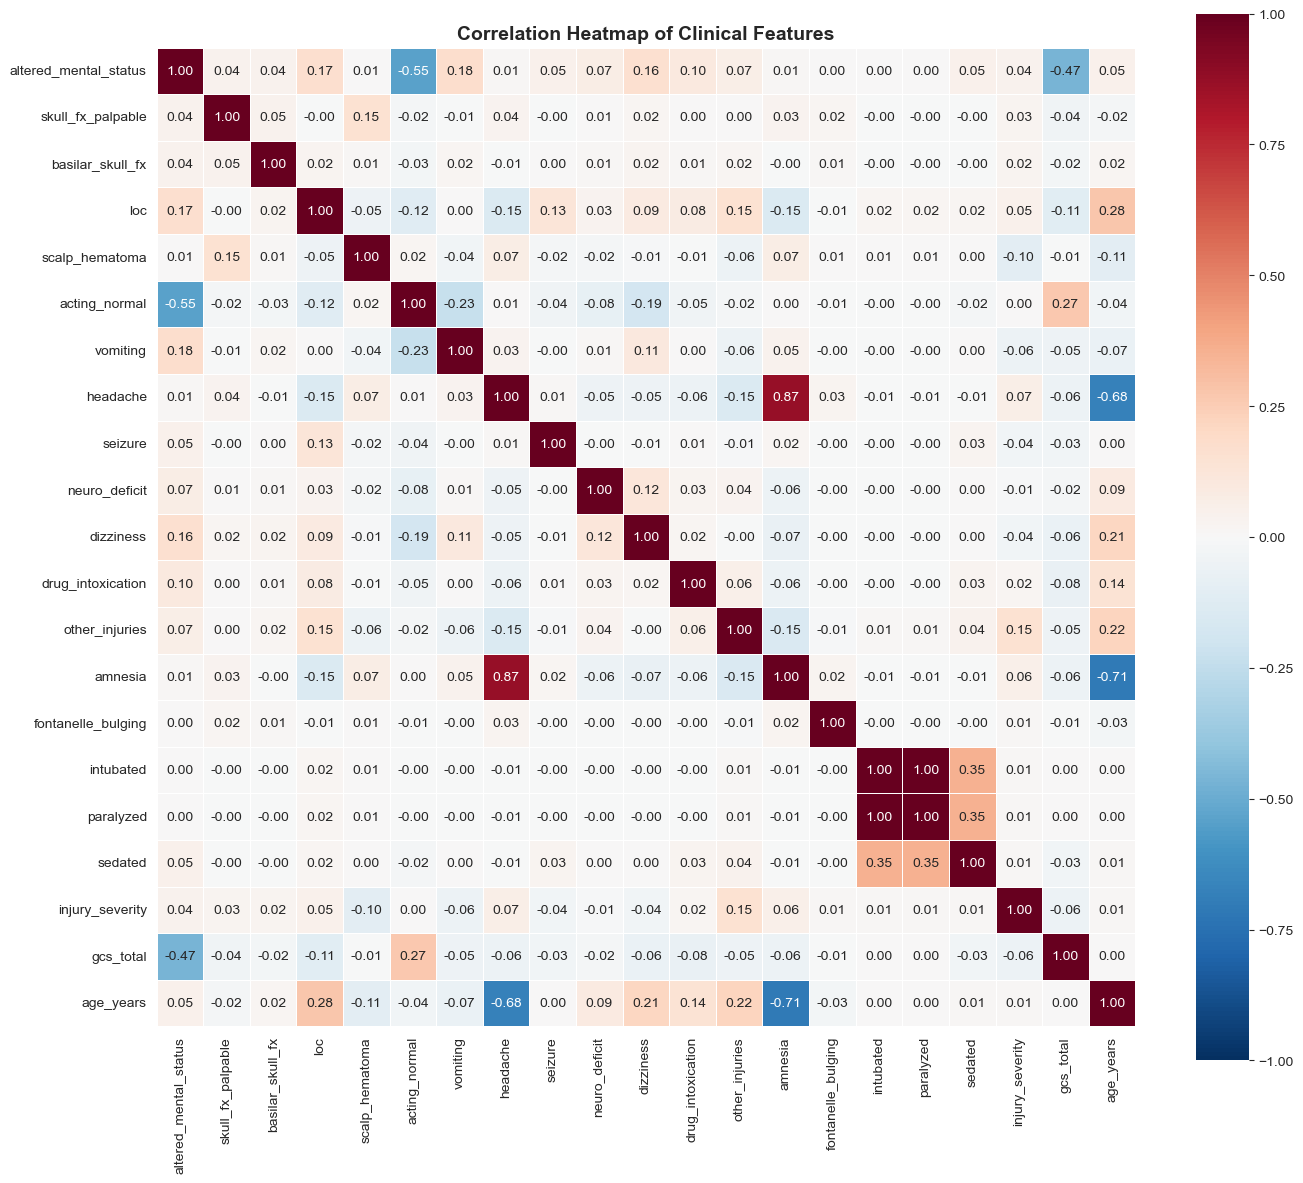

In [50]:
# select clinically relevant features (not IDs, not outcomes, not conditional subfields), first level clinical observations

eda_features = [
    'altered_mental_status', 'skull_fx_palpable', 'basilar_skull_fx',
    'loc', 'scalp_hematoma', 'acting_normal', 'vomiting', 'headache',
    'seizure', 'neuro_deficit', 'dizziness', 'drug_intoxication',
    'other_injuries', 'amnesia', 'fontanelle_bulging',
    'intubated', 'paralyzed', 'sedated',
    'injury_severity', 'gcs_total', 'age_years'
]

# .corr() computes pairwise Pearson correlation between all columns
# for binary variables, Pearson correlation is equivalent to the phi coefficient
# values range from -1 (perfectly inverse) to +1 (perfectly co-occurring)
corr_matrix = df_prep[eda_features].astype(float).corr()

# plot as a heatmap
fig, ax = plt.subplots(figsize=(14,12))

# annot=True prints the correlation value inside each cell
# fmt='.2f' formats to 2 decimal places
# cmap='RdBu_r' uses red for positive correlation, blue for negative
# center=0 ensures white = no correlation
# vmin/vmax set the color scale range
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap of Clinical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Q6) Co-occurence and Bayesian Analysis

How often two binary events happen together. Counts or proportions. Example: Of 100 TBI patients, 30 have both vomiting AND headache

Conditional probability gives us the association strength

In [95]:
# which symptomps co-occur, e.g. "Do patients who have vomiting also tend to have headache AND altered mental status?" That's a 3-way pattern, not a 2-way correlation.

# select key clinical symptoms
symptoms = [
    'altered_mental_status', 'loc', 'vomiting', 'headache',
    'skull_fx_palpable', 'basilar_skull_fx', 'scalp_hematoma',
    'seizure', 'neuro_deficit', 'acting_normal'
]

# filter to only TBI-positive patients (where patterns matter most)
tbi_pos = df_prep[df_prep['clinically_important_tbi'] == 1]

# count how many patients have each combination of 2 symtomps
# e.g., how many have BOTH vomiting AND headache?
from itertools import combinations # remember to add to requirements

results = []

for feat1, feat2 in combinations(symptoms, 2):
    # both present
    both = ((tbi_pos[feat1] == 1) & (tbi_pos[feat2] == 1)).sum()

    # at least one present 
    either = ((tbi_pos[feat1] == 1) | (tbi_pos[feat2] == 1)).sum()

    # only compute if at least one co-occurence exists
    if both > 0:
        # conditional probability: P(feat2 | feat1)
        feat1_count = (tbi_pos[feat1] == 1).sum()
        prob_given_feat1 = both / feat1_count if feat1_count > 0 else 0

        results.append({
            'feature_1': feat1,
            'feature_2': feat2,
            'co_occurence_count': both,
            'prob_feat2_given_feat1': round(prob_given_feat1 * 100, 1)
        })

df_cooccur = pd.DataFrame(results).sort_values('co_occurence_count', ascending=False)

print("Top symptom pairs among TBI-positive patients:")
print(df_cooccur.to_string(index=False))

# e.g. 62.5% of patients with altered mental status also have scalp hematoma


Top symptom pairs among TBI-positive patients:
            feature_1         feature_2  co_occurence_count  prob_feat2_given_feat1
altered_mental_status    scalp_hematoma                 140                    62.5
             headache    scalp_hematoma                 110                    67.5
altered_mental_status          headache                  98                    43.8
       scalp_hematoma     acting_normal                  80                    34.8
altered_mental_status               loc                  77                    34.4
altered_mental_status          vomiting                  75                    33.5
                  loc    scalp_hematoma                  73                    62.9
             vomiting    scalp_hematoma                  71                    61.2
             vomiting          headache                  71                    61.2
                  loc          headache                  63                    54.3
             headache     act

In [91]:
# ── Finding 3 Figure: Symptom Co-occurrence Among TBI Patients ──
import plotly.graph_objects as go

# Top co-occurring pairs (from notebook output, top 15)
pairs = [
    ('AMS → Scalp hematoma', 62.5),
    ('Headache → Scalp hematoma', 67.5),
    ('AMS → Headache', 43.8),
    ('LOC → Scalp hematoma', 62.9),
    ('Vomiting → Scalp hematoma', 61.2),
    ('Vomiting → Headache', 61.2),
    ('LOC → Headache', 54.3),
    ('AMS → LOC', 34.4),
    ('AMS → Vomiting', 33.5),
    ('LOC → Vomiting', 36.2),
    ('Basilar skull fx → Scalp hematoma', 61.0),
    ('Skull fx palpable → Scalp hematoma', 60.0),
    ('Basilar skull fx → Acting normal', 43.9),
    ('Headache → Acting normal', 32.5),
    ('Scalp hematoma → Acting normal', 34.8),
]

# Sort ascending for horizontal bar chart (highest at top)
pairs.sort(key=lambda x: x[1])

labels = [p[0] for p in pairs]
values = [p[1] for p in pairs]

fig = go.Figure()

fig.add_trace(go.Bar(
    y=labels,
    x=values,
    orientation='h',
    marker=dict(
        color=values,
        colorscale=[[0, '#95a5a6'], [0.5, '#3498db'], [1, '#e74c3c']],
        line=dict(color='black', width=0.5)
    ),
    text=[f'{v:.1f}%' for v in values],
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='P(Symptom B | Symptom A) Among TBI-Positive Patients',
        font=dict(size=16, family='Arial')
    ),
    xaxis=dict(
        title='Conditional Probability (%)',
        title_font=dict(size=12),
        range=[0, max(values) * 1.15],
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(
        title='',
        title_font=dict(size=12)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1000,
    height=700,
    margin=dict(l=280, r=80, t=100, b=80),
    showlegend=False
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')
fig.show()

fig.write_image('../figs/finding3_cooccurrence.pdf', width=1000, height=700)
print("✓ Exported to finding3_cooccurrence.pdf")


✓ Exported to finding3_cooccurrence.pdf


In [96]:
# ── Finding 3 Figure: Symptom Co-occurrence Heatmap Among TBI Patients ──
import plotly.graph_objects as go
import numpy as np

symptoms = [
    'altered_mental_status', 'loc', 'vomiting', 'headache',
    'skull_fx_palpable', 'basilar_skull_fx', 'scalp_hematoma',
    'seizure', 'neuro_deficit', 'acting_normal'
]

label_map = {
    'altered_mental_status': 'AMS',
    'loc': 'LOC',
    'vomiting': 'Vomiting',
    'headache': 'Headache',
    'skull_fx_palpable': 'Skull fx',
    'basilar_skull_fx': 'Basilar fx',
    'scalp_hematoma': 'Scalp hematoma',
    'seizure': 'Seizure',
    'neuro_deficit': 'Neuro deficit',
    'acting_normal': 'Acting normal'
}

labels = [label_map[s] for s in symptoms]

tbi_pos = df_prep[df_prep['clinically_important_tbi'] == 1]

# Build the matrix: P(col symptom | row symptom)
n = len(symptoms)
matrix = np.zeros((n, n))

for i, s1 in enumerate(symptoms):
    s1_count = (tbi_pos[s1] == 1).sum()
    for j, s2 in enumerate(symptoms):
        if i == j:
            matrix[i][j] = np.nan
        else:
            both = ((tbi_pos[s1] == 1) & (tbi_pos[s2] == 1)).sum()
            matrix[i][j] = (both / s1_count * 100) if s1_count > 0 else 0

matrix = np.round(matrix, 1)

# Build text matrix with blanks on diagonal
text_matrix = [[f'{matrix[i][j]:.1f}%' if not np.isnan(matrix[i][j]) else '' 
                for j in range(n)] for i in range(n)]

fig = go.Figure(data=go.Heatmap(
    z=matrix,
    x=labels,
    y=labels,
    text=text_matrix,
    texttemplate='%{text}',
    textfont=dict(size=10),
    colorscale='RdBu_r',
    zmin=0,
    zmax=100,
    colorbar=dict(title='P(col | row) %'),
    hovertemplate='P(%{x} | %{y}) = %{z:.1f}%<extra></extra>'
))


fig.update_layout(
    title=dict(
        text='Symptom Co-occurrence: Probability(Column | Row) Among TBI Patients',
        font=dict(size=15, family='Arial')
    ),
    xaxis=dict(title='', tickangle=-45),
    yaxis=dict(title='', autorange='reversed'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=800,
    height=700,
    margin=dict(l=130, r=80, t=100, b=130)
)

fig.show()

fig.write_image('../figs/finding3_cooccurrence.pdf', width=800, height=700)
print("✓ Exported to finding3_cooccurrence.pdf")


✓ Exported to finding3_cooccurrence.pdf


In [52]:
# bayesian inference

# compute the prior: overall TBI rate in the population
prior_tbi = (df_prep['clinically_important_tbi']== 1).sum() / len(df_prep)
print(f"Prior P(TBI) = {prior_tbi:.4f} ({prior_tbi*100:.2f}%)\n")

# Use the binary features we already identified systematically
# (from Q2 where we filtered to columns with only {0, 1} values)
symptoms = [f for f in binary_features if f != 'clinically_important_tbi']

# for each symptom, compute the posterior P(TBI | symptom)
results = []
for symptom in symptoms:
    # compute the likelihood P(symptom | TBI)
    # of the patients with TBI, what % have this symptom?
    tbi_patients = df_prep[df_prep['clinically_important_tbi'] == 1]
    # count how many TBI patients have symptom == 1
    symptom_given_tbi_count = (tbi_patients[symptom] == 1).sum()
    # divide by total TBI patients
    likelihood = symptom_given_tbi_count / len(tbi_patients)

    # compute the evidence P(symptom)
    # of all patients, what % have this symptom?
    symptom_count = (df_prep[symptom] == 1).sum()
    # divide by total patients
    evidence = symptom_count / len(df_prep)

    # apply bayes theorem
    # P(TBI | symptom) = P(symptom | TBI) × P(TBI) / P(symptom)
    # only compute if at least some patients have this symptom (avoid division by zero)
    if evidence > 0:
        posterior = (likelihood * prior_tbi) / evidence
    else:
        posterior = 0

    # compute the bayes factor 
    # Bayes factor = posterior odds / prior odds
    # shows how much the symptom updates your belief
    prior_odds = prior_tbi / (1 - prior_tbi)
    posterior_odds = posterior / (1 - posterior) if posterior < 1 else float('inf')
    bayes_factor = posterior_odds / prior_odds if prior_odds > 0 else 0

    results.append({
        'symptom': symptom,
        'P(symptom|TBI)': round(likelihood * 100, 1),      # likelihood as %
        'P(symptom)': round(evidence * 100, 1),            # base rate as %
        'P(TBI|symptom)': round(posterior * 100, 2),       # posterior as %
        'bayes_factor': round(bayes_factor, 1)
    })

# convert to dataframe and sort by posterior probability descending
df_bayes = pd.DataFrame(results).sort_values('P(TBI|symptom)', ascending=False)

print("Bayesian Inference: Posterior Probability of TBI Given Each Symptom")
print("="*80)
print(df_bayes.to_string(index=False))


Prior P(TBI) = 0.0089 (0.89%)

Bayesian Inference: Posterior Probability of TBI Given Each Symptom
              symptom  P(symptom|TBI)  P(symptom)  P(TBI|symptom)  bayes_factor
    skull_fx_palpable             6.6         0.4           15.62          20.5
     basilar_skull_fx            10.9         0.7           14.29          18.5
              sedated             0.5         0.1            6.25           7.4
altered_mental_status            59.6        13.0            4.08           4.7
    drug_intoxication             4.0         0.9            4.07           4.7
   fontanelle_bulging             0.3         0.1            3.85           4.4
              seizure             4.5         1.2            3.44           3.9
        neuro_deficit             4.3         1.3            2.90           3.3
                  loc            30.9        10.5            2.64           3.0
              amnesia            27.1        10.5            2.30           2.6
       other_injuries

In [53]:
# ── Posterior for MULTIPLE symptoms (corrected) ──

symptom_combo = ['skull_fx_palpable', 'basilar_skull_fx']

# Step 1: Compute P(symptom1=1, symptom2=1 | TBI)
# Under naïve Bayes: product of individual likelihoods
tbi_patients = df_prep[df_prep['clinically_important_tbi'] == 1]
likelihood_tbi = 1.0
for symptom in symptom_combo:
    p_symptom_given_tbi = (tbi_patients[symptom] == 1).sum() / len(tbi_patients)
    likelihood_tbi *= p_symptom_given_tbi

# Step 2: Compute P(symptom1=1, symptom2=1 | NO TBI)
no_tbi_patients = df_prep[df_prep['clinically_important_tbi'] == 0]
likelihood_no_tbi = 1.0
for symptom in symptom_combo:
    p_symptom_given_no_tbi = (no_tbi_patients[symptom] == 1).sum() / len(no_tbi_patients)
    likelihood_no_tbi *= p_symptom_given_no_tbi

# Step 3: Compute prior probabilities
prior_tbi = (df_prep['clinically_important_tbi'] == 1).sum() / len(df_prep)
prior_no_tbi = 1 - prior_tbi

# Step 4: Apply Bayes' theorem with normalization
# P(TBI | symptoms) = P(symptoms | TBI) * P(TBI) / P(symptoms)
# where P(symptoms) = P(symptoms | TBI) * P(TBI) + P(symptoms | NO TBI) * P(NO TBI)

numerator = likelihood_tbi * prior_tbi
denominator = (likelihood_tbi * prior_tbi) + (likelihood_no_tbi * prior_no_tbi)

posterior_combo = numerator / denominator if denominator > 0 else 0

print(f"\nP(TBI | {' AND '.join(symptom_combo)}) = {posterior_combo*100:.2f}%")



P(TBI | skull_fx_palpable AND basilar_skull_fx) = 77.38%


In [54]:
# ignore
# ── Bayesian inference for multi-category features ──

# Example: injury_mechanism (8 categories)
feature = 'injury_mechanism'

print(f"\nBayesian Inference for {feature}:")
print("=" * 80)

# get all unique values (excluding NaN)
categories = df_prep[feature].dropna().unique()

for cat in sorted(categories):
    # likelihood: P(mechanism=cat | TBI)
    tbi_patients = df_prep[df_prep['clinically_important_tbi'] == 1]
    likelihood = (tbi_patients[feature] == cat).sum() / len(tbi_patients)
    
    # evidence: P(mechanism=cat)
    evidence = (df_prep[feature] == cat).sum() / len(df_prep)
    
    # posterior: P(TBI | mechanism=cat)
    posterior = (likelihood * prior_tbi) / evidence if evidence > 0 else 0
    
    # get readable label
    original_name = new_to_old.get(feature)
    label = all_variable_maps.get(original_name, {}).get(cat, cat)
    
    print(f"  {label:50s} P(TBI|mechanism={cat}) = {posterior*100:6.2f}%")



Bayesian Inference for injury_mechanism:
  Occupant in motor vehicle                          P(TBI|mechanism=1) =   1.51%
  Pedestrian struck by moving                        P(TBI|mechanism=2) =   2.76%
  Bike rider struck by automobile                    P(TBI|mechanism=3) =   2.67%
  Bike collision or fall from bike                   P(TBI|mechanism=4) =   1.02%
  Other wheeled transport crash                      P(TBI|mechanism=5) =   2.35%
  Fall to ground from standing/                      P(TBI|mechanism=6) =   0.40%
  Walked or ran into stationary                      P(TBI|mechanism=7) =   0.13%
  Fall from an elevation                             P(TBI|mechanism=8) =   0.90%
  Fall down stairs                                   P(TBI|mechanism=9) =   0.38%
  Sports                                             P(TBI|mechanism=10) =   0.65%
  Assault                                            P(TBI|mechanism=11) =   0.50%
  Object struck head - accidental                    P

In [90]:
# ── Finding 3 Figure: Bayesian Posterior / Bayes Factor Chart ──
import plotly.graph_objects as go

# Data from the Bayesian analysis (sorted by Bayes factor)
symptoms = [
    'Acting normally', 'Headache', 'Scalp hematoma', 'Vomiting',
    'Other injuries', 'Amnesia', 'Loss of consciousness',
    'Neurological deficit', 'Seizure', 'Altered mental status',
    'Basilar skull fracture', 'Palpable skull fracture'
]
bayes_factors = [0.4, 1.4, 1.5, 2.4, 2.4, 2.6, 3.0, 3.3, 3.9, 4.7, 18.5, 20.5]

# Color: red if BF < 1, gray if 1-2, blue if > 2
colors = ['#e74c3c' if bf < 1 else '#95a5a6' if bf < 2 else '#3498db' for bf in bayes_factors]

fig = go.Figure()

fig.add_trace(go.Bar(
    y=symptoms,
    x=bayes_factors,
    orientation='h',
    marker=dict(color=colors, line=dict(color='black', width=0.5)),
    text=[f'{bf:.1f}x' for bf in bayes_factors],
    textposition='outside'
))

# Add vertical line at BF = 1 (no update)
fig.add_vline(x=1, line_dash='dash', line_color='black', opacity=0.5,
              annotation_text='No diagnostic value (BF = 1)',
              annotation_position='top right')

fig.update_layout(
    title=dict(text='Bayes Factor: How Much Each Symptom Updates TBI Probability',
               font=dict(size=16, family='Arial')),
    xaxis=dict(
        title='Bayes Factor (multiplicative increase in odds)',
        title_font=dict(size=12),
        range=[0, max(bayes_factors) * 1.15],
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(title='', title_font=dict(size=12)),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1000,
    height=600,
    margin=dict(l=220, r=100, t=100, b=80),
    showlegend=False
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')
fig.show()

fig.write_image('../figs/finding3_bayes_factors.pdf', width=1000, height=600)
print("✓ Exported Finding 3 figure to finding3_bayes_factors.pdf")


✓ Exported Finding 3 figure to finding3_bayes_factors.pdf


### Preprocessing (again)

In [55]:
# Feature selection for PCA and modeling

# Clinical features available at triage (what a physician observes)
# Exclude: patient_id, outcomes, conditional subfields, interventions

modeling_features = [
    # Demographics
    'age_years', 'age_months', 'age_group', 'gender',
    
    # Vital signs / GCS
    'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total',
    
    # Clinical signs (objective)
    'altered_mental_status', 'skull_fx_palpable', 'basilar_skull_fx',
    'fontanelle_bulging', 'scalp_hematoma', 'neuro_deficit',
    
    # Symptoms (patient/parent reported)
    'loc', 'amnesia', 'seizure', 'vomiting', 'headache', 
    'acting_normal', 
    
    # Injury characteristics
    'injury_mechanism', 'injury_severity',
    
    # Other clinical factors
    'other_injuries', 'drug_intoxication'
]

# Create feature matrix X and outcome vector y
X = df_prep[modeling_features].copy()
y = df_prep['clinically_important_tbi'].copy()

print(f"Feature matrix: {X.shape}")
print(f"Outcome vector: {y.shape}")


Feature matrix: (42047, 24)
Outcome vector: (42047,)


In [56]:
# Handle missing values — PCA can't handle NaN
# Check missingness in selected features
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print("Missing values in modeling features:")
print(missing_pct[missing_pct > 0])

# "The feature dizziness was excluded due to 35% missingness and lack of inclusion in the validated Kuppermann rule. Remaining features had <8% missing values and were handled via [simple imputation / row deletion]."

Missing values in modeling features:
acting_normal            7.130116
amnesia                  4.904036
drug_intoxication        4.195305
loc                      4.074012
gcs_motor                2.970485
gcs_verbal               2.949081
gcs_eye                  2.946702
seizure                  1.702856
headache                 1.046448
basilar_skull_fx         0.984612
neuro_deficit            0.851428
altered_mental_status    0.744405
vomiting                 0.701596
injury_severity          0.694461
scalp_hematoma           0.680191
injury_mechanism         0.623112
other_injuries           0.425714
fontanelle_bulging       0.373392
skull_fx_palpable        0.240207
gender                   0.007135
dtype: float64


In [57]:
# Drop rows with any missing values (simplest, but loses data)
X_complete = X.dropna()
y_complete = y.loc[X_complete.index]
print(f"\nAfter dropping missing: {X_complete.shape}")


After dropping missing: (32321, 24)


In [58]:
# Standardize features — required for PCA
# ── Standardization: mean=0, std=1 ──
# PCA is sensitive to scale — a variable with range [0, 100] will dominate
# one with range [0, 1] even if less important

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_complete)

# Convert back to DataFrame for interpretability
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_complete.columns,
    index=X_complete.index
)

print("Standardized features (first 5 rows):")
print(X_scaled_df.head())

Standardized features (first 5 rows):
   age_years  age_months  age_group    gender   gcs_eye  gcs_verbal  \
0   1.753712    1.744349   0.597589 -0.781906  0.062309    0.136006   
1  -0.255494   -0.277242   0.597589  1.278926  0.062309    0.136006   
3  -0.986115   -1.052438  -1.673390  1.278926  0.062309    0.136006   
6  -0.438150   -0.474841   0.597589 -0.781906  0.062309    0.136006   
7   1.023091    0.953953   0.597589  1.278926  0.062309    0.136006   

   gcs_motor  gcs_total  altered_mental_status  skull_fx_palpable  \
0   0.024883   0.152332              -0.350210          -0.151069   
1   0.024883   0.152332              -0.350210          -0.151069   
3   0.024883   0.152332              -0.350210          -0.151069   
6   0.024883   0.152332               2.855433          -0.151069   
7   0.024883   0.152332              -0.350210          -0.151069   

   basilar_skull_fx  fontanelle_bulging  scalp_hematoma  neuro_deficit  \
0         -0.076898           -0.023606       

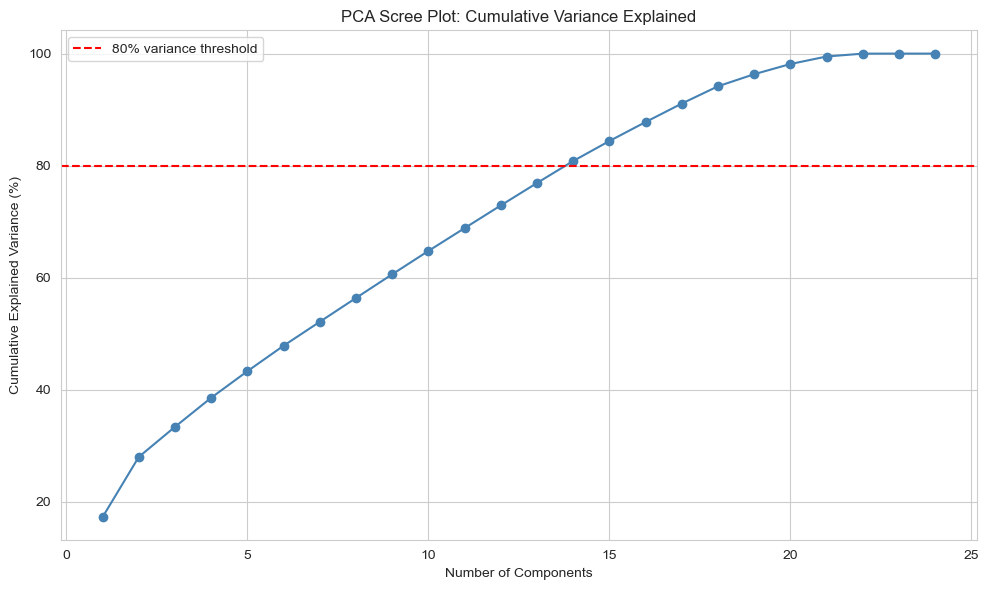


First 14 components explain 80.8% of variance


In [66]:
# PCA

from sklearn.decomposition import PCA
import numpy as np

# fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# explain variance (for scree plot)
explained_var = pca.explained_variance_ratio_

# scree plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(explained_var) + 1), 
        np.cumsum(explained_var) * 100, 
        marker='o', linestyle='-', color='steelblue')
ax.axhline(y=80, color='red', linestyle='--', label='80% variance threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA Scree Plot: Cumulative Variance Explained')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFirst 14 components explain {np.cumsum(explained_var)[:14][-1]*100:.1f}% of variance")

PCA reveals that the clinical features in this dataset are largely orthogonal — 14 principal components are needed to capture 80% of variance, suggesting that symptoms provide independent information rather than clustering into a few syndromes. This supports the use of multiple features in prediction models rather than relying on composite scores.

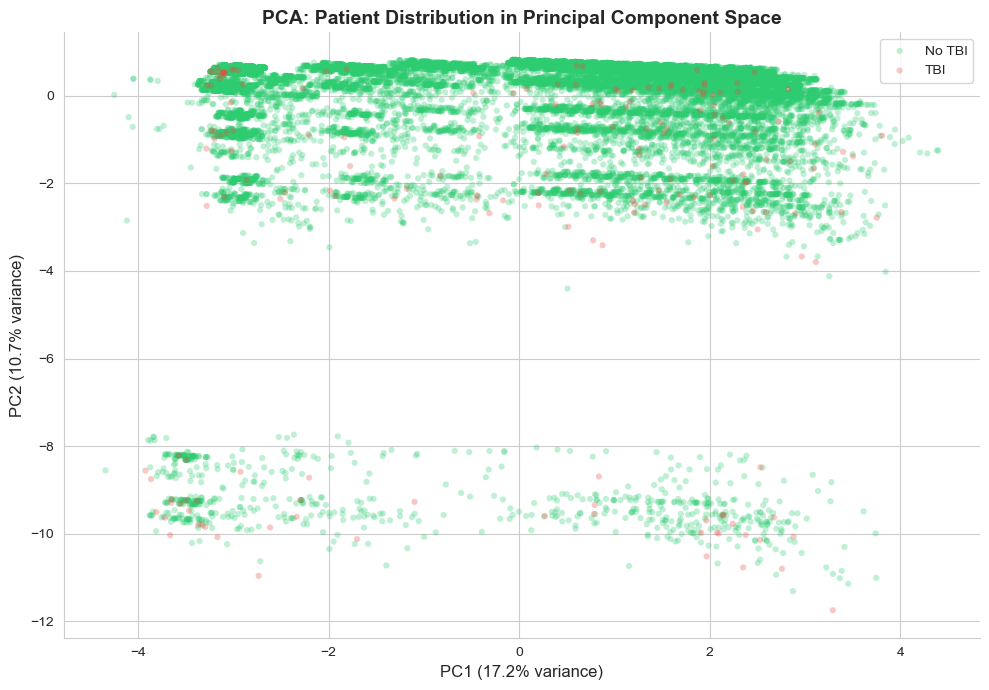

In [67]:
# ── PCA biplot: visualize patients in PC1-PC2 space ──

# Reduce to 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'outcome': y_complete.map({0: 'No TBI', 1: 'TBI'})
})

# Scatterplot colored by outcome
fig, ax = plt.subplots(figsize=(10, 7))

for outcome, color in [('No TBI', '#2ecc71'), ('TBI', '#e74c3c')]:
    subset = pca_df[pca_df['outcome'] == outcome]
    ax.scatter(subset['PC1'], subset['PC2'], 
               c=color, label=outcome, alpha=0.3, s=20, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA: Patient Distribution in Principal Component Space', 
             fontsize=14, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


Top 10 features contributing to PC1:
                     PC1       PC2
age_years       0.913444 -0.051579
age_months      0.913403 -0.050310
amnesia        -0.885162 -0.040774
headache       -0.880140 -0.044829
age_group       0.821532  0.019757
loc             0.289285 -0.220238
other_injuries  0.256721 -0.065198
gender         -0.124123  0.018765
scalp_hematoma -0.120765  0.017374
neuro_deficit   0.103628 -0.088782


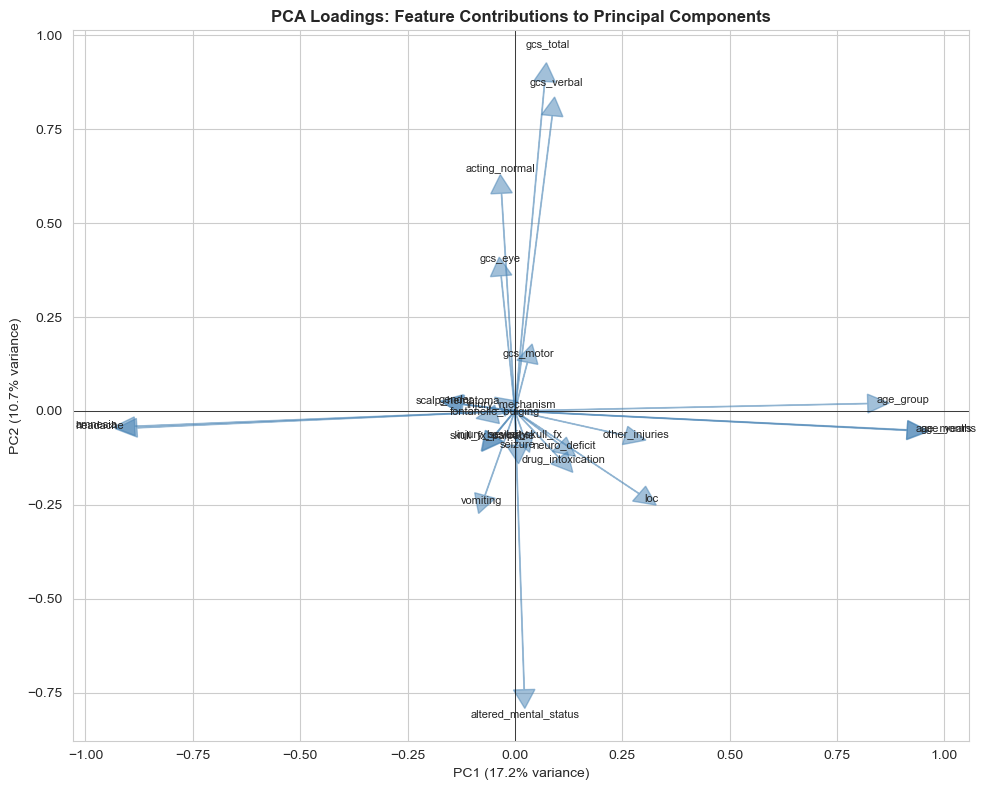

In [68]:
# ── Feature loadings: which original features contribute to PC1 and PC2? ──

# Get the loadings (eigenvectors)
loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)

# Create a DataFrame
loadings_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=X_complete.columns
)

# Sort by absolute loading on PC1
loadings_df['PC1_abs'] = loadings_df['PC1'].abs()
loadings_df_sorted = loadings_df.sort_values('PC1_abs', ascending=False)

print("Top 10 features contributing to PC1:")
print(loadings_df_sorted[['PC1', 'PC2']].head(10))

# Visualize loadings as a biplot
fig, ax = plt.subplots(figsize=(10, 8))

for i, feature in enumerate(loadings_df.index):
    ax.arrow(0, 0, loadings_df.loc[feature, 'PC1'], loadings_df.loc[feature, 'PC2'],
             head_width=0.05, head_length=0.05, fc='steelblue', ec='steelblue', alpha=0.5)
    ax.text(loadings_df.loc[feature, 'PC1'] * 1.1, 
            loadings_df.loc[feature, 'PC2'] * 1.1,
            feature, fontsize=8, ha='center')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA Loadings: Feature Contributions to Principal Components', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


PCA reveals that clinically important TBI cannot be captured by a simple linear combination of the first two principal components. The overlap between TBI-positive and TBI-negative patients in PC1-PC2 space suggests that TBI prediction requires complex, nonlinear interactions between features rather than a single severity axis. This motivates the use of nonlinear classification methods (e.g., decision trees, logistic regression with interaction terms) over simple linear scoring systems.

We performed PCA to explore whether TBI patients cluster in a lower-dimensional feature space. The first 14 components explain 80% of variance, indicating that clinical features provide largely independent information. No clear separation emerged in PC1-PC2 space, confirming that TBI is not a simple linear syndrome.



### Stability Check

In [97]:
# ── Stability Check: Bootstrap the Kuppermann Sensitivity-Specificity Tradeoff ──
import numpy as np

np.random.seed(214)

all_over2 = df_prep[df_prep['age_group'] == 2]
outcome = all_over2['clinically_important_tbi']
n = len(all_over2)
n_bootstrap = 1000

def kuppermann_flags(data):
    base = (
        (data['altered_mental_status'] == 1) |
        (data['basilar_skull_fx'] == 1) |
        (data['loc'] == 1) |
        (data['vomiting'] == 1) |
        (data['injury_severity'] == 1) |
        (data['headache_severity'] == 3)
    )
    plus_scalp = base | (data['scalp_hematoma'] == 1)
    plus_headache = base | (data['headache_severity'] == 2)
    plus_both = base | (data['scalp_hematoma'] == 1) | (data['headache_severity'] == 2)
    return {'Original': base, '+ Scalp hematoma': plus_scalp,
            '+ Moderate headache': plus_headache, '+ Both': plus_both}

def compute_sens_spec(flag, outcome):
    tp = ((flag) & (outcome == 1)).sum()
    fn = ((~flag) & (outcome == 1)).sum()
    tn = ((~flag) & (outcome == 0)).sum()
    fp = ((flag) & (outcome == 0)).sum()
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    return sens, spec

# Bootstrap
results = {name: {'sens': [], 'spec': []} for name in ['Original', '+ Scalp hematoma', '+ Moderate headache', '+ Both']}

for i in range(n_bootstrap):
    idx = np.random.choice(n, size=n, replace=True)
    boot_data = all_over2.iloc[idx]
    boot_outcome = boot_data['clinically_important_tbi']
    
    flags = kuppermann_flags(boot_data)
    for name, flag in flags.items():
        sens, spec = compute_sens_spec(flag, boot_outcome)
        results[name]['sens'].append(sens)
        results[name]['spec'].append(spec)

# Print summary
print(f"{'Rule':<25} {'Sensitivity':>20} {'Specificity':>20}")
print("-" * 65)
for name in ['Original', '+ Scalp hematoma', '+ Moderate headache', '+ Both']:
    sens_arr = np.array(results[name]['sens'])
    spec_arr = np.array(results[name]['spec'])
    sens_lo, sens_hi = np.percentile(sens_arr, [2.5, 97.5])
    spec_lo, spec_hi = np.percentile(spec_arr, [2.5, 97.5])
    sens_mean = sens_arr.mean()
    spec_mean = spec_arr.mean()
    print(f"{name:<25} {sens_mean:>6.1f}% [{sens_lo:>5.1f}, {sens_hi:>5.1f}]   {spec_mean:>6.1f}% [{spec_lo:>5.1f}, {spec_hi:>5.1f}]")


Rule                               Sensitivity          Specificity
-----------------------------------------------------------------
Original                    91.1% [ 87.5,  94.3]     55.1% [ 54.5,  55.7]
+ Scalp hematoma            96.0% [ 93.4,  98.2]     35.0% [ 34.5,  35.5]
+ Moderate headache         93.3% [ 90.2,  96.1]     47.1% [ 46.6,  47.7]
+ Both                      96.7% [ 94.4,  98.6]     30.2% [ 29.7,  30.7]


In [98]:
# ── Stability Check Figure: Bootstrap CI for Sensitivity-Specificity ──
import plotly.graph_objects as go

rule_names = ['Original', '+ Scalp hematoma', '+ Moderate headache', '+ Both']
colors_sens = '#e74c3c'
colors_spec = '#3498db'

sens_means = []
sens_los = []
sens_his = []
spec_means = []
spec_los = []
spec_his = []

for name in rule_names:
    s = np.array(results[name]['sens'])
    p = np.array(results[name]['spec'])
    sens_means.append(s.mean())
    sens_los.append(np.percentile(s, 2.5))
    sens_his.append(np.percentile(s, 97.5))
    spec_means.append(p.mean())
    spec_los.append(np.percentile(p, 2.5))
    spec_his.append(np.percentile(p, 97.5))

fig = go.Figure()

# Sensitivity points + error bars
fig.add_trace(go.Scatter(
    x=rule_names,
    y=sens_means,
    error_y=dict(
        type='data',
        symmetric=False,
        array=[h - m for h, m in zip(sens_his, sens_means)],
        arrayminus=[m - l for m, l in zip(sens_means, sens_los)]
    ),
    mode='markers',
    marker=dict(color=colors_sens, size=12, symbol='circle'),
    name='Sensitivity'
))

# Specificity points + error bars
fig.add_trace(go.Scatter(
    x=rule_names,
    y=spec_means,
    error_y=dict(
        type='data',
        symmetric=False,
        array=[h - m for h, m in zip(spec_his, spec_means)],
        arrayminus=[m - l for m, l in zip(spec_means, spec_los)]
    ),
    mode='markers',
    marker=dict(color=colors_spec, size=12, symbol='diamond'),
    name='Specificity'
))

fig.update_layout(
    title=dict(text='Stability Check: Bootstrap 95% CI for Kuppermann Rule Variants (≥ 2 years)',
               font=dict(size=14, family='Arial')),
    yaxis=dict(
        title='Percentage (%)',
        title_font=dict(size=12),
        range=[20, 100],
        gridcolor='#e0e0e0'
    ),
    xaxis=dict(title='', title_font=dict(size=12)),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=900,
    height=550,
    margin=dict(l=80, r=80, t=100, b=80),
    legend=dict(x=0.99, y=0.99, xanchor='right', yanchor='top',
                bgcolor='rgba(255,255,255,0.8)')
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')

fig.show()

fig.write_image('../figs/stability_check.pdf', width=900, height=550)
print("✓ Exported to stability_check.pdf")


✓ Exported to stability_check.pdf


In [99]:
# Stability Again but for bayesian posteriors

# ── Stability Check: Bootstrap the Bayesian Posterior Probabilities ──
import numpy as np

np.random.seed(214)

n_bootstrap = 1000
n_patients = len(df_prep)

symptoms = [
    'skull_fx_palpable', 'basilar_skull_fx', 'altered_mental_status',
    'seizure', 'neuro_deficit', 'loc', 'amnesia', 'other_injuries',
    'vomiting', 'scalp_hematoma', 'headache', 'acting_normal'
]

# Store bootstrap results
boot_posteriors = {s: [] for s in symptoms}
boot_bayes_factors = {s: [] for s in symptoms}

for i in range(n_bootstrap):
    idx = np.random.choice(n_patients, size=n_patients, replace=True)
    boot = df_prep.iloc[idx]
    
    prior = (boot['clinically_important_tbi'] == 1).sum() / len(boot)
    tbi = boot[boot['clinically_important_tbi'] == 1]
    
    for symptom in symptoms:
        symptom_given_tbi = (tbi[symptom] == 1).sum() / len(tbi) if len(tbi) > 0 else 0
        evidence = (boot[symptom] == 1).sum() / len(boot)
        
        if evidence > 0 and prior > 0:
            posterior = (symptom_given_tbi * prior) / evidence
            prior_odds = prior / (1 - prior)
            post_odds = posterior / (1 - posterior) if posterior < 1 else float('inf')
            bf = post_odds / prior_odds
        else:
            posterior = 0
            bf = 0
        
        boot_posteriors[symptom].append(posterior * 100)
        boot_bayes_factors[symptom].append(bf)

# Print summary
print(f"{'Symptom':<25} {'Posterior':>20} {'Bayes Factor':>25}")
print("-" * 70)
for s in symptoms:
    post = np.array(boot_posteriors[s])
    bf = np.array(boot_bayes_factors[s])
    post_lo, post_hi = np.percentile(post, [2.5, 97.5])
    bf_lo, bf_hi = np.percentile(bf, [2.5, 97.5])
    print(f"{s:<25} {post.mean():>5.1f}% [{post_lo:>5.1f}, {post_hi:>5.1f}]   {bf.mean():>5.1f}x [{bf_lo:>5.1f}, {bf_hi:>5.1f}]")


Symptom                              Posterior              Bayes Factor
----------------------------------------------------------------------
skull_fx_palpable          15.8% [ 10.3,  21.7]    20.9x [ 13.1,  30.2]
basilar_skull_fx           14.3% [ 10.6,  18.6]    18.6x [ 13.2,  24.9]
altered_mental_status       4.1% [  3.5,   4.6]     4.7x [  4.3,   5.1]
seizure                     3.4% [  2.0,   5.3]     3.9x [  2.2,   6.1]
neuro_deficit               2.9% [  1.6,   4.3]     3.3x [  1.8,   5.0]
loc                         2.6% [  2.2,   3.1]     3.0x [  2.5,   3.4]
amnesia                     2.3% [  1.9,   2.8]     2.6x [  2.2,   3.1]
other_injuries              2.1% [  1.7,   2.6]     2.4x [  2.0,   2.8]
vomiting                    2.1% [  1.7,   2.5]     2.4x [  2.0,   2.7]
scalp_hematoma              1.4% [  1.2,   1.6]     1.5x [  1.4,   1.7]
headache                    1.3% [  1.1,   1.5]     1.4x [  1.3,   1.6]
acting_normal               0.4% [  0.3,   0.4]     0.4x [  0.4,

In [100]:
# ── Stability Check Figure: Bootstrap CI for Bayes Factors ──
import plotly.graph_objects as go

# Sort by mean Bayes factor
symptom_labels = {
    'skull_fx_palpable': 'Palpable skull fx',
    'basilar_skull_fx': 'Basilar skull fx',
    'altered_mental_status': 'AMS',
    'seizure': 'Seizure',
    'neuro_deficit': 'Neuro deficit',
    'loc': 'LOC',
    'amnesia': 'Amnesia',
    'other_injuries': 'Other injuries',
    'vomiting': 'Vomiting',
    'scalp_hematoma': 'Scalp hematoma',
    'headache': 'Headache',
    'acting_normal': 'Acting normal'
}

# Compute means and CIs
means = {s: np.mean(boot_bayes_factors[s]) for s in symptoms}
sorted_symptoms = sorted(symptoms, key=lambda s: means[s])

y_labels = [symptom_labels[s] for s in sorted_symptoms]
x_means = [means[s] for s in sorted_symptoms]
x_los = [np.percentile(boot_bayes_factors[s], 2.5) for s in sorted_symptoms]
x_his = [np.percentile(boot_bayes_factors[s], 97.5) for s in sorted_symptoms]

# Color by whether BF > 1
colors = ['#e74c3c' if m < 1 else '#95a5a6' if m < 2 else '#3498db' for m in x_means]

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=y_labels,
    x=x_means,
    error_x=dict(
        type='data',
        symmetric=False,
        array=[h - m for h, m in zip(x_his, x_means)],
        arrayminus=[m - l for m, l in zip(x_means, x_los)]
    ),
    mode='markers',
    marker=dict(color=colors, size=10, line=dict(color='black', width=0.5)),
    showlegend=False
))

# Vertical line at BF = 1
fig.add_vline(x=1, line_dash='dash', line_color='black', opacity=0.5,
              annotation_text='BF = 1 (no diagnostic value)',
              annotation_position='top right',
              annotation_font_size=10)

fig.update_layout(
    title=dict(text='Stability Check: Bootstrap 95% CI for Bayes Factors',
               font=dict(size=15, family='Arial')),
    xaxis=dict(
        title='Bayes Factor (multiplicative increase in odds)',
        title_font=dict(size=12),
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(title='', title_font=dict(size=12)),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1000,
    height=600,
    margin=dict(l=180, r=80, t=100, b=80)
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')
fig.show()

fig.write_image('../figs/stability_check.pdf', width=1000, height=600)
print("✓ Exported to stability_check.pdf")


✓ Exported to stability_check.pdf


### Modeling Section

### Kupperman Model

In [103]:
# ── Model 1: Kuppermann Clinical Decision Rule ──

# Apply the rule to ALL patients (both age groups)
# Returns True (recommend CT) or False (no CT)

def kuppermann_predict(df):
    """Apply Kuppermann decision rule to each patient."""
    predictions = pd.Series(0, index=df.index, dtype='Int64')

    # ── Children < 2 years (age_group == 1) ──
    under2 = (df['age_group'] == 1).to_numpy(dtype=bool, na_value=False)
    flag_under2 = (
        (df.loc[under2, 'altered_mental_status'] == 1) |
        (df.loc[under2, 'skull_fx_palpable'] == 1) |
        ((df.loc[under2, 'hematoma_location'] != 92) & (df.loc[under2, 'hematoma_location'] != 1)) |
        (df.loc[under2, 'loc_duration'] >= 2) |
        (df.loc[under2, 'injury_severity'] == 1) |
        (df.loc[under2, 'acting_normal'] == 0)
    ).fillna(False).astype(int)
    predictions.loc[under2] = flag_under2
    
    # ── Children >= 2 years (age_group == 2) ──
    over2 = (df['age_group'] == 2).to_numpy(dtype=bool, na_value=False)
    flag_over2 = (
        (df.loc[over2, 'altered_mental_status'] == 1) |
        (df.loc[over2, 'basilar_skull_fx'] == 1) |
        (df.loc[over2, 'loc'] == 1) |
        (df.loc[over2, 'vomiting'] == 1) |
        (df.loc[over2, 'injury_severity'] == 1) |
        (df.loc[over2, 'headache_severity'] == 3)
    ).fillna(False).astype(int)
    predictions.loc[over2] = flag_over2

    return predictions.astype(int)

# Generate predictions
y_true = df_prep['clinically_important_tbi']
y_pred_kuppermann = kuppermann_predict(df_prep)

# Evaluation metrics
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score, classification_report)

print("=" * 50)
print("  Model 1: Kuppermann Clinical Decision Rule")
print("=" * 50)

print(f"\n{classification_report(y_true, y_pred_kuppermann, target_names=['No TBI', 'TBI'])}")


cm = confusion_matrix(y_true, y_pred_kuppermann)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"  TP (TBI caught):          {tp}")
print(f"  FP (unnecessary CTs):     {fp}")
print(f"  FN (missed TBI):          {fn}")
print(f"  TN (correctly avoided):   {tn}")
print(f"\n  Sensitivity (recall):     {tp/(tp+fn)*100:.1f}%")
print(f"  Specificity:              {tn/(tn+fp)*100:.1f}%")
print(f"  Precision (PPV):          {tp/(tp+fp)*100:.2f}%")
print(f"  Accuracy:                 {accuracy_score(y_true, y_pred_kuppermann)*100:.1f}%")
print(f"  F1 Score:                 {f1_score(y_true, y_pred_kuppermann):.4f}")


  Model 1: Kuppermann Clinical Decision Rule

              precision    recall  f1-score   support

      No TBI       1.00      0.43      0.60     41671
         TBI       0.01      0.91      0.03       376

    accuracy                           0.43     42047
   macro avg       0.51      0.67      0.31     42047
weighted avg       0.99      0.43      0.59     42047

Confusion Matrix:
  TP (TBI caught):          344
  FP (unnecessary CTs):     23813
  FN (missed TBI):          32
  TN (correctly avoided):   17858

  Sensitivity (recall):     91.5%
  Specificity:              42.9%
  Precision (PPV):          1.42%
  Accuracy:                 43.3%
  F1 Score:                 0.0280


In [105]:
# ── Confusion Matrix Diagram for Kuppermann ──
import plotly.graph_objects as go

# Values from the output
tp, fp, fn, tn = 344, 23813, 32, 17858

z = [[tp, fn],
     [fp, tn]]

labels = [
    [f'True Positive<br><b>{tp:,}</b><br>TBI caught', 
     f'False Negative<br><b>{fn:,}</b><br>TBI missed'],
    [f'False Positive<br><b>{fp:,}</b><br>Unnecessary CTs', 
     f'True Negative<br><b>{tn:,}</b><br>Correctly avoided']
]

colors = [['#2ecc71', '#e74c3c'],
          ['#f39c12', '#3498db']]

fig = go.Figure(data=go.Heatmap(
    z=[[1, 0.2],
       [0.4, 0.8]],
    text=[[labels[0][0], labels[0][1]],
          [labels[1][0], labels[1][1]]],
    texttemplate='%{text}',
    textfont=dict(size=14),
    colorscale=[[0, '#e74c3c'], [0.3, '#f39c12'], [0.6, '#3498db'], [1, '#2ecc71']],
    showscale=False,
    hoverinfo='skip'
))

fig.update_layout(
    title=dict(text='Kuppermann Decision Rule: Confusion Matrix (n = 42,047)',
               font=dict(size=16, family='Arial')),
    xaxis=dict(
        title='Actual',
        title_font=dict(size=13),
        tickvals=[0, 1],
        ticktext=['TBI', 'No TBI'],
        side='bottom'
    ),
    yaxis=dict(
        title='Predicted',
        title_font=dict(size=13),
        tickvals=[0, 1],
        ticktext=['Recommend CT', 'No CT'],
        autorange='reversed'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    width=700,
    height=550,
    margin=dict(l=120, r=80, t=100, b=80)
)


fig.show()

fig.write_image('../figs/kuppermann_confusion_matrix.pdf', width=700, height=550)
print("✓ Exported to kuppermann_confusion_matrix.pdf")


✓ Exported to kuppermann_confusion_matrix.pdf


In [106]:
# Stability of Model 1

# ── Stability Check: Bootstrap Kuppermann Model Metrics ──
import numpy as np

np.random.seed(214)
n_bootstrap = 1000

boot_sensitivity = []
boot_specificity = []
boot_precision = []

for i in range(n_bootstrap):
    idx = np.random.choice(len(df_prep), size=len(df_prep), replace=True)
    boot_data = df_prep.iloc[idx]
    boot_y = boot_data['clinically_important_tbi']
    boot_pred = kuppermann_predict(boot_data)
    
    tp = ((boot_pred == 1) & (boot_y == 1)).sum()
    fp = ((boot_pred == 1) & (boot_y == 0)).sum()
    fn = ((boot_pred == 0) & (boot_y == 1)).sum()
    tn = ((boot_pred == 0) & (boot_y == 0)).sum()
    
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    
    boot_sensitivity.append(sens)
    boot_specificity.append(spec)
    boot_precision.append(prec)

boot_sensitivity = np.array(boot_sensitivity)
boot_specificity = np.array(boot_specificity)
boot_precision = np.array(boot_precision)

print("Kuppermann Bootstrap Stability (1,000 resamples)")
print("=" * 60)
for name, arr in [('Sensitivity', boot_sensitivity), 
                   ('Specificity', boot_specificity),
                   ('Precision', boot_precision)]:
    lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"  {name:<15} {arr.mean():>6.2f}%  95% CI [{lo:.2f}, {hi:.2f}]")


Kuppermann Bootstrap Stability (1,000 resamples)
  Sensitivity      91.50%  95% CI [88.71, 94.25]
  Specificity      42.86%  95% CI [42.36, 43.31]
  Precision         1.43%  95% CI [1.28, 1.58]


In [107]:
# ── Stability Figure: Bootstrap Distributions for Kuppermann ──
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=('Sensitivity', 'Specificity', 'Precision'))

# Sensitivity histogram
fig.add_trace(go.Histogram(
    x=boot_sensitivity, nbinsx=40,
    marker=dict(color='#3498db', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=1)

# Add original value line
sens_orig = 91.5
fig.add_vline(x=sens_orig, line_dash='dash', line_color='red', 
              row=1, col=1, opacity=0.8)

# Specificity histogram
fig.add_trace(go.Histogram(
    x=boot_specificity, nbinsx=40,
    marker=dict(color='#e67e22', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=2)

spec_orig = 42.9
fig.add_vline(x=spec_orig, line_dash='dash', line_color='red',
              row=1, col=2, opacity=0.8)

# Precision histogram
fig.add_trace(go.Histogram(
    x=boot_precision, nbinsx=40,
    marker=dict(color='#2ecc71', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=3)

prec_orig = 1.42
fig.add_vline(x=prec_orig, line_dash='dash', line_color='red',
              row=1, col=3, opacity=0.8)

fig.update_layout(
    title=dict(text='Kuppermann Rule: Bootstrap Stability (1,000 Resamples)',
               font=dict(size=15, family='Arial')),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1200,
    height=450,
    margin=dict(l=80, r=80, t=100, b=80)
)

fig.update_xaxes(title_text='%', gridcolor='#f0f0f0')
fig.update_yaxes(title_text='Count', gridcolor='#f0f0f0')

fig.show()

fig.write_image('../figs/kuppermann_stability.pdf', width=1200, height=450)
print("✓ Exported to kuppermann_stability.pdf")


✓ Exported to kuppermann_stability.pdf


### Logistic Regression

### Model 2: Logistic Regression — Mathematical Background

**Core idea:** Logistic regression models the probability of TBI as a weighted sum of features, passed through a sigmoid function to produce a value between 0 and 1:

$$P(\text{TBI} = 1 \mid \mathbf{x}) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p)$$

where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the **sigmoid function**.

**How it differs from Kuppermann:** The Kuppermann rule is a hard OR: if ANY single feature is present, flag the patient. Logistic regression learns a **weight** $\beta_j$ for each feature:
- $\beta_j > 0$: feature increases TBI probability
- $\beta_j < 0$: feature decreases TBI probability
- $\beta_j = 0$: feature has no effect

This means multiple weak features can **collectively** trigger a flag, even when no single feature would. This is exactly what we need for the 32 missed Kuppermann patients who had combinations of mild symptoms.

**Training objective:** The model is fit by maximizing the log-likelihood:

$$\mathcal{L}(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

where $p_i = \sigma(\mathbf{x}_i^\top \boldsymbol{\beta})$. This is solved via iterative optimization (L-BFGS).

**Regularization (L2 / Ridge):** To prevent overfitting, we add a penalty term $\lambda \|\boldsymbol{\beta}\|^2$ to the loss. In sklearn, $C = 1/\lambda$:
- Small $C$ = strong regularization = simpler model
- Large $C$ = weak regularization = more flexible model

**Class imbalance handling:** With only 0.89% TBI cases, an unweighted model would learn to always predict "no TBI." We use `class_weight='balanced'`, which reweights the loss:

$$w_{\text{TBI}} = \frac{n_{\text{total}}}{2 \times n_{\text{TBI}}}, \quad w_{\text{noTBI}} = \frac{n_{\text{total}}}{2 \times n_{\text{noTBI}}}$$

This makes each TBI case roughly 112x more important during training.

**Decision threshold tuning:** By default, predict TBI if $P(\text{TBI}) > 0.5$. But clinically, we want high sensitivity (catch all TBI) even at the cost of more unnecessary CTs. We sweep thresholds on the validation set and pick the one that achieves $\geq 90\%$ sensitivity with the highest specificity.

**Interpreting coefficients:** Each $\beta_j$ represents the change in **log-odds** per unit increase in feature $j$. The **odds ratio** $e^{\beta_j}$ gives the multiplicative change in odds. For example, $\beta_j = 1.5$ means $e^{1.5} \approx 4.5\times$ increase in odds of TBI.


In [114]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    roc_curve, auc
)

In [108]:
# STEP 1: Feature Selection
# ──────────────────────────────────────────────────────────────
# We select the same clinical features a physician would observe
# at triage. We exclude:
#   - patient_id (identifier, not a feature)
#   - clinically_important_tbi (the outcome we're predicting)
#   - conditional subfields (hematoma_location, hematoma_size, etc.)
#     because they only exist when scalp_hematoma = 1,
#     creating structural missingness that would bias the model
#   - GCS subscores (gcs_eye, gcs_verbal, gcs_motor) because
#     gcs_total already captures the same information

features_for_lr = [
    # Binary clinical signs (objective, observed by physician)
    'altered_mental_status', 'skull_fx_palpable', 'basilar_skull_fx',
    'fontanelle_bulging', 'scalp_hematoma', 'neuro_deficit',
    
    # Binary symptoms (reported by patient/parent)
    'loc', 'amnesia', 'seizure', 'vomiting', 'headache',
    'acting_normal',
    
    # Injury characteristics
    'injury_severity',   # binary: 1 = high/severe, 0 = low/moderate
    'other_injuries',    # binary: 1 = yes
    'drug_intoxication', # binary: 1 = yes
    
    # Demographics and vitals
    'age_years',         # continuous: 0-17
    'gcs_total',         # ordinal: 14-15 in our dataset (GCS 3-13 excluded)
    'gender',            # binary: 1 = female, 2 = male
    
    # Multi-category (will be one-hot encoded)
    'injury_mechanism',  # 8+ categories
]

print(f"Selected {len(features_for_lr)} features for logistic regression")

Selected 19 features for logistic regression


In [109]:
# STEP 2: Prepare Feature Matrix
# ──────────────────────────────────────────────────────────────
# We need to:
#   a) One-hot encode multi-category variables
#   b) Handle missing values
#   c) Split into train/val/test
#   d) Standardize continuous features

# start with the selected features
X_lr = df_prep[features_for_lr].copy()
y_lr = df_prep['clinically_important_tbi'].copy()

# 2a) One-hot econde injury mechanism
# injury_mechanism has 8+ categories (e.g., fall, MVC, bike crash...)
# Logistic regression needs numeric input, so we convert each category
# into its own binary column.
# drop_first=True drops one category to avoid perfect multicollinearity
# (the "dummy variable trap": if all other dummies are 0, we know it's
# the dropped category)
X_lr = pd.get_dummies(X_lr, columns=['injury_mechanism'], drop_first=True, dtype=int)
print(f"After one-hot encoding: {X_lr.shape[1]} features")
print(f"New columns: {[c for c in X_lr.columns if 'injury_mechanism' in c]}")


After one-hot encoding: 30 features
New columns: ['injury_mechanism_2', 'injury_mechanism_3', 'injury_mechanism_4', 'injury_mechanism_5', 'injury_mechanism_6', 'injury_mechanism_7', 'injury_mechanism_8', 'injury_mechanism_9', 'injury_mechanism_10', 'injury_mechanism_11', 'injury_mechanism_12', 'injury_mechanism_90']


In [110]:
# 2b) Handle missing values
# Convert nullable Int64 to float (sklearn requires numpy-compatible types)
# Fill remaining NaN with 0 (conservative: missing = feature not present)
X_lr = X_lr.astype(float)
X_lr = X_lr.fillna(0)
print(f"Missing values after fillna: {X_lr.isna().sum().sum()}")

# ── 2c) Train/Validation/Test split ──
# 70% train, 15% validation (for threshold tuning), 15% test (final eval)
# Stratified to preserve the 0.89% TBI rate in each split
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_lr, y_lr, test_size=0.30, random_state=214, stratify=y_lr
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=214, stratify=y_temp
)

print(f"\nTrain:      {len(X_train):,} patients ({y_train.sum()} TBI, {y_train.mean()*100:.2f}%)")
print(f"Validation: {len(X_val):,} patients ({y_val.sum()} TBI, {y_val.mean()*100:.2f}%)")
print(f"Test:       {len(X_test):,} patients ({y_test.sum()} TBI, {y_test.mean()*100:.2f}%)")


Missing values after fillna: 0

Train:      29,432 patients (263 TBI, 0.89%)
Validation: 6,307 patients (56 TBI, 0.89%)
Test:       6,308 patients (57 TBI, 0.90%)


In [111]:
# ── 2d) Standardize features ──
# Logistic regression is sensitive to feature scale.
# age_years ranges [0, 17], while binary features are [0, 1].
# Without standardization, the model would underweight binary features.
#
# StandardScaler transforms each feature to mean=0, std=1:
#   x_scaled = (x - mean) / std
#
# IMPORTANT: fit the scaler on training data ONLY, then apply
# the same transformation to val and test. This prevents data leakage
# (the model never "sees" validation/test statistics during training).

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_val_scaled = scaler.transform(X_val)            # transform only on val
X_test_scaled = scaler.transform(X_test)          # transform only on test

print(f"\nScaling complete. Train mean ≈ 0: {X_train_scaled.mean():.6f}")


Scaling complete. Train mean ≈ 0: 0.000000


In [116]:
# STEP 3: Fit the Model
# ──────────────────────────────────────────────────────────────
# LogisticRegression parameters:
#   - C=1.0: inverse regularization strength (default, moderate)
#   - class_weight='balanced': upweights TBI cases proportionally
#   - solver='lbfgs': efficient optimizer for L2 penalty
#   - max_iter=1000: enough iterations to converge
#   - penalty='l2': Ridge regularization (shrinks coefficients)
model_lr = LogisticRegression(
    C=1.0,
    class_weight = 'balanced',
    solver='lbfgs',
    max_iter=1000,
    penalty='l2',
    random_state=214
)

model_lr.fit(X_train_scaled, y_train)

print("Model fitted successfully.")
print(f"Number of iterations: {model_lr.n_iter_[0]}")

Model fitted successfully.
Number of iterations: 18


/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.



In [117]:
# STEP 4: Examine Learned Coefficients
# ──────────────────────────────────────────────────────────────
# Each coefficient βⱼ tells us how much feature j shifts the
# log-odds of TBI:
#   log(P(TBI) / P(no TBI)) = β₀ + β₁x₁ + ... + βₚxₚ
#
# A coefficient of +1.5 means: a 1-unit increase in that feature
# increases the log-odds of TBI by 1.5, which corresponds to
# e^1.5 ≈ 4.5x increase in the odds.

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_lr.coef_[0],
    'odds_ratio': np.exp(model_lr.coef_[0])
}).sort_values('coefficient', ascending=False)

print(f"\nIntercept (β₀): {model_lr.intercept_[0]:.4f}")
print("\nTop 10 features by coefficient (positive = increases TBI risk):")
print(coef_df.head(10).to_string(index=False))
print("\nBottom 5 features (negative = decreases TBI risk):")
print(coef_df.tail(5).to_string(index=False))


Intercept (β₀): -1.5155

Top 10 features by coefficient (positive = increases TBI risk):
              feature  coefficient  odds_ratio
      injury_severity     0.529394    1.697903
       scalp_hematoma     0.499227    1.647448
altered_mental_status     0.493113    1.637405
             vomiting     0.413807    1.512565
                  loc     0.385420    1.470232
    skull_fx_palpable     0.368808    1.446009
     basilar_skull_fx     0.255950    1.291689
              seizure     0.198317    1.219349
       other_injuries     0.160936    1.174609
   injury_mechanism_5     0.135096    1.144647

Bottom 5 features (negative = decreases TBI risk):
            feature  coefficient  odds_ratio
 injury_mechanism_7    -0.287394    0.750216
 injury_mechanism_9    -0.292561    0.746350
injury_mechanism_11    -0.318285    0.727395
 injury_mechanism_8    -0.326434    0.721492
      acting_normal    -0.459176    0.631804


In [119]:
# STEP 5: Tune Decision Threshold on Validation Set
# ──────────────────────────────────────────────────────────────
# By default, predict class 1 if P(TBI) > 0.5.
# But we want to prioritize sensitivity (catching TBI cases).
#
# Strategy: sweep thresholds from 0.01 to 0.99, compute
# sensitivity and specificity at each, and pick the threshold
# that achieves >= 90% sensitivity with the best specificity.
#
# This is the same tradeoff the Kuppermann rule makes,
# but data-driven rather than hand-designed.

y_val_proba = model_lr.predict_proba(X_val_scaled)[:, 1]

thresholds = np.arange(0.01, 1.00, 0.01)
thresholds_results = []

for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    tn = ((y_pred_t == 0) & (y_val == 0)).sum()

    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0

    thresholds_results.append({
        'thresholds': t,
        'sensitivity': sens,
        'specificity': spec, 
        'tp': tp, 'fp': fp, 'fn': fn, 'tn':tn
    })

df_thresh = pd.DataFrame(thresholds_results)

# find the best threshold: highest specificity among those with >= 90% sensitivity
high_sens = df_thresh[df_thresh['sensitivity'] >= 90]
if len(high_sens) > 0:
    best_row = high_sens.loc[high_sens['specificity'].idxmax()]
    best_threshold = best_row['thresholds']
else:
    # fallback: threshold that maximizes sensitivity + specificity
    df_thresh['sum'] = df_thresh['sensitivity'] + df_thresh['specificity']
    best_threshold = df_thresh.loc[df_thresh['sum'].idxmax(), 'threshold']


print(f"\nOptimal threshold: {best_threshold:.2f}")
print(f"  Validation sensitivity: {best_row['sensitivity']:.1f}%")
print(f"  Validation specificity: {best_row['specificity']:.1f}%")


Optimal threshold: 0.29
  Validation sensitivity: 92.9%
  Validation specificity: 71.9%


In [120]:
# STEP 6: Evaluate on Test Set
# ──────────────────────────────────────────────────────────────
# Apply the tuned threshold to the held-out test set.
# This is the ONLY time we touch the test set — ensures
# our reported metrics are unbiased.

y_test_proba = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_test_proba >= best_threshold).astype(int)

print("\n" + "=" * 50)
print("  Model 2: Logistic Regression (Test Set)")
print("=" * 50)

print(f"\n{classification_report(y_test, y_pred_lr, target_names=['No TBI', 'TBI'])}")

cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"  TP (TBI caught):          {tp}")
print(f"  FP (unnecessary CTs):     {fp}")
print(f"  FN (missed TBI):          {fn}")
print(f"  TN (correctly avoided):   {tn}")
print(f"\n  Sensitivity (recall):     {tp/(tp+fn)*100:.1f}%")
print(f"  Specificity:              {tn/(tn+fp)*100:.1f}%")
print(f"  Precision (PPV):          {tp/(tp+fp)*100:.2f}%")
print(f"  Accuracy:                 {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print(f"  F1 Score:                 {f1_score(y_test, y_pred_lr):.4f}")
print(f"  Decision threshold:       {best_threshold:.2f}")


  Model 2: Logistic Regression (Test Set)

              precision    recall  f1-score   support

      No TBI       1.00      0.73      0.84      6251
         TBI       0.03      0.84      0.05        57

    accuracy                           0.73      6308
   macro avg       0.51      0.78      0.45      6308
weighted avg       0.99      0.73      0.83      6308

Confusion Matrix:
  TP (TBI caught):          48
  FP (unnecessary CTs):     1707
  FN (missed TBI):          9
  TN (correctly avoided):   4544

  Sensitivity (recall):     84.2%
  Specificity:              72.7%
  Precision (PPV):          2.74%
  Accuracy:                 72.8%
  F1 Score:                 0.0530
  Decision threshold:       0.29


In [121]:
# STEP 7: ROC Curve
# ──────────────────────────────────────────────────────────────
# The ROC curve plots sensitivity vs (1 - specificity) at every
# possible threshold. The area under the curve (AUC) summarizes
# overall discriminative ability:
#   AUC = 0.5 → random guessing
#   AUC = 1.0 → perfect separation
#
# This is useful because it evaluates the model across ALL
# thresholds, not just the one we picked.

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

print(f"\n  AUC-ROC: {roc_auc:.4f}")


  AUC-ROC: 0.8573


In [124]:
# ── Logistic Regression Figures ──
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Threshold Tuning (Validation Set)',
                                    'ROC Curve (Test Set)'))

# ── Left panel: Sensitivity vs Specificity across thresholds ──
fig.add_trace(go.Scatter(
    x=df_thresh['thresholds'],
    y=df_thresh['sensitivity'],
    mode='lines',
    name='Sensitivity',
    line=dict(color='#e74c3c', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_thresh['thresholds'],
    y=df_thresh['specificity'],
    mode='lines',
    name='Specificity',
    line=dict(color='#3498db', width=2)
), row=1, col=1)

# Mark the chosen threshold
fig.add_vline(x=best_threshold, line_dash='dash', line_color='black',
              opacity=0.6, row=1, col=1)
fig.add_annotation(x=best_threshold, y=95, text=f'Chosen: {best_threshold:.2f}',
                   showarrow=True, arrowhead=2, row=1, col=1)

# ── Right panel: ROC curve ──
fig.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    name=f'Logistic Regression (AUC = {roc_auc:.3f})',
    line=dict(color='#3498db', width=2)
), row=1, col=2)

# Diagonal (random classifier)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Random (AUC = 0.5)',
    line=dict(color='gray', width=1, dash='dash')
), row=1, col=2)

fig.update_layout(
    title=dict(text='Logistic Regression: Threshold Tuning and ROC Curve',
               font=dict(size=15, family='Arial')),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1200,
    height=500,
    margin=dict(l=80, r=80, t=100, b=80),
    legend=dict(x=0.55, y=0.15)
)

fig.update_xaxes(title_text='Decision Threshold', gridcolor='#f0f0f0', row=1, col=1)
fig.update_yaxes(title_text='Percentage (%)', gridcolor='#f0f0f0', row=1, col=1)
fig.update_xaxes(title_text='False Positive Rate (1 - Specificity)', gridcolor='#f0f0f0', row=1, col=2)
fig.update_yaxes(title_text='True Positive Rate (Sensitivity)', gridcolor='#f0f0f0', row=1, col=2)

fig.show()

fig.write_image('../figs/logistic_regression_roc.pdf', width=1200, height=500)
print("✓ Exported to logistic_regression_roc.pdf")


✓ Exported to logistic_regression_roc.pdf


In [125]:
# ── Confusion Matrix for Logistic Regression ──

labels_cm = [
    [f'True Positive<br><b>{tp:,}</b><br>TBI caught', 
     f'False Negative<br><b>{fn:,}</b><br>TBI missed'],
    [f'False Positive<br><b>{fp:,}</b><br>Unnecessary CTs', 
     f'True Negative<br><b>{tn:,}</b><br>Correctly avoided']
]

fig_cm = go.Figure(data=go.Heatmap(
    z=[[1, 0.2],
       [0.4, 0.8]],
    text=[[labels_cm[0][0], labels_cm[0][1]],
          [labels_cm[1][0], labels_cm[1][1]]],
    texttemplate='%{text}',
    textfont=dict(size=14),
    colorscale=[[0, '#e74c3c'], [0.3, '#f39c12'], [0.6, '#3498db'], [1, '#2ecc71']],
    showscale=False,
    hoverinfo='skip'
))

fig_cm.update_layout(
    title=dict(text=f'Logistic Regression: Confusion Matrix (Test Set, threshold = {best_threshold:.2f})',
               font=dict(size=16, family='Arial')),
    xaxis=dict(title='Actual', title_font=dict(size=13),
               tickvals=[0, 1], ticktext=['TBI', 'No TBI'], side='bottom'),
    yaxis=dict(title='Predicted', title_font=dict(size=13),
               tickvals=[0, 1], ticktext=['Recommend CT', 'No CT'], autorange='reversed'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    width=700,
    height=550,
    margin=dict(l=120, r=80, t=100, b=80)
)

fig_cm.show()

fig_cm.write_image('../figs/logistic_regression_cm.pdf', width=700, height=550)
print("✓ Exported to logistic_regression_cm.pdf")


✓ Exported to logistic_regression_cm.pdf


In [126]:
# ── Fair comparison: evaluate Kuppermann on the SAME test set ──
# We need to get Kuppermann predictions for the test set patients
# X_test contains the features, but kuppermann_predict needs the full df_prep columns

# Get the test set indices
test_indices = X_test.index

# Apply Kuppermann to the original df_prep rows that correspond to test set
y_pred_kupp_test = kuppermann_predict(df_prep.loc[test_indices])

cm_kupp = confusion_matrix(y_test, y_pred_kupp_test)
tn_k, fp_k, fn_k, tp_k = cm_kupp.ravel()

print("=" * 50)
print("  Kuppermann on TEST SET (fair comparison)")
print("=" * 50)
print(f"  TP: {tp_k}  FP: {fp_k}  FN: {fn_k}  TN: {tn_k}")
print(f"  Sensitivity: {tp_k/(tp_k+fn_k)*100:.1f}%")
print(f"  Specificity: {tn_k/(tn_k+fp_k)*100:.1f}%")
print(f"  Precision:   {tp_k/(tp_k+fp_k)*100:.2f}%")


  Kuppermann on TEST SET (fair comparison)
  TP: 52  FP: 3506  FN: 5  TN: 2745
  Sensitivity: 91.2%
  Specificity: 43.9%
  Precision:   1.46%


In [127]:
## stability part for logistic regression
# ── Stability Check: Bootstrap Logistic Regression ──
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(214)
n_bootstrap = 200  # fewer than 1000 because we retrain each time

# Store results
boot_lr_sensitivity = []
boot_lr_specificity = []
boot_lr_precision = []
boot_lr_coefs = []

# We bootstrap the TRAINING set, retrain, and evaluate on the SAME test set
# This measures: how much does the model change when the training data shifts?

for i in range(n_bootstrap):
    # Resample training set with replacement
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[idx]
    y_boot = y_train.iloc[idx]
    
    # Re-standardize (fit scaler on this bootstrap sample)
    scaler_boot = StandardScaler()
    X_boot_scaled = scaler_boot.fit_transform(X_boot)
    X_test_scaled_boot = scaler_boot.transform(X_test)
    
    # Retrain logistic regression
    model_boot = LogisticRegression(
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        penalty='l2',
        random_state=214
    )
    model_boot.fit(X_boot_scaled, y_boot)
    
    # Predict on test set using the SAME threshold (0.29)
    y_proba_boot = model_boot.predict_proba(X_test_scaled_boot)[:, 1]
    y_pred_boot = (y_proba_boot >= best_threshold).astype(int)
    
    # Compute metrics
    tp = ((y_pred_boot == 1) & (y_test == 1)).sum()
    fp = ((y_pred_boot == 1) & (y_test == 0)).sum()
    fn = ((y_pred_boot == 0) & (y_test == 1)).sum()
    tn = ((y_pred_boot == 0) & (y_test == 0)).sum()
    
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    
    boot_lr_sensitivity.append(sens)
    boot_lr_specificity.append(spec)
    boot_lr_precision.append(prec)
    boot_lr_coefs.append(model_boot.coef_[0])
    
    if (i + 1) % 50 == 0:
        print(f"  Bootstrap {i+1}/{n_bootstrap} complete")

boot_lr_sensitivity = np.array(boot_lr_sensitivity)
boot_lr_specificity = np.array(boot_lr_specificity)
boot_lr_precision = np.array(boot_lr_precision)
boot_lr_coefs = np.array(boot_lr_coefs)

print("\nLogistic Regression Bootstrap Stability (200 resamples)")
print("=" * 65)
for name, arr in [('Sensitivity', boot_lr_sensitivity), 
                   ('Specificity', boot_lr_specificity),
                   ('Precision', boot_lr_precision)]:
    lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"  {name:<15} {arr.mean():>6.2f}%  95% CI [{lo:.2f}, {hi:.2f}]")


/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

  Bootstrap 50/200 complete


/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

  Bootstrap 100/200 complete


/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

  Bootstrap 150/200 complete


/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

  Bootstrap 200/200 complete

Logistic Regression Bootstrap Stability (200 resamples)
  Sensitivity      82.40%  95% CI [77.15, 85.96]
  Specificity      74.29%  95% CI [71.32, 77.75]
  Precision         2.85%  95% CI [2.60, 3.15]


/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

/opt/anaconda3/envs/stat214/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

In [128]:
# ── Stability Figures for Logistic Regression ──
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Figure 1: Bootstrap distributions of metrics ──
fig1 = make_subplots(rows=1, cols=3,
                     subplot_titles=('Sensitivity', 'Specificity', 'Precision'))

fig1.add_trace(go.Histogram(
    x=boot_lr_sensitivity, nbinsx=30,
    marker=dict(color='#3498db', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=1)
fig1.add_vline(x=84.2, line_dash='dash', line_color='red', row=1, col=1)

fig1.add_trace(go.Histogram(
    x=boot_lr_specificity, nbinsx=30,
    marker=dict(color='#e67e22', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=2)
fig1.add_vline(x=72.7, line_dash='dash', line_color='red', row=1, col=2)

fig1.add_trace(go.Histogram(
    x=boot_lr_precision, nbinsx=30,
    marker=dict(color='#2ecc71', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=3)
fig1.add_vline(x=2.74, line_dash='dash', line_color='red', row=1, col=3)

fig1.update_layout(
    title=dict(text='Logistic Regression: Bootstrap Metric Stability (200 Resamples)',
               font=dict(size=15, family='Arial')),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1200, height=450,
    margin=dict(l=80, r=80, t=100, b=80)
)
fig1.update_xaxes(title_text='%', gridcolor='#f0f0f0')
fig1.update_yaxes(title_text='Count', gridcolor='#f0f0f0')

fig1.show()
fig1.write_image('../figs/lr_stability_metrics.pdf', width=1200, height=450)
print("✓ Exported to lr_stability_metrics.pdf")

# ── Figure 2: Coefficient stability ──
# Show how much the top coefficients shift across bootstrap resamples

top_features = ['injury_severity', 'scalp_hematoma', 'altered_mental_status',
                'vomiting', 'loc', 'skull_fx_palpable', 'basilar_skull_fx',
                'acting_normal']

feature_names = list(X_train.columns)
top_indices = [feature_names.index(f) for f in top_features]

fig2 = go.Figure()

coef_means = []
coef_los = []
coef_his = []

for idx, feat in zip(top_indices, top_features):
    vals = boot_lr_coefs[:, idx]
    coef_means.append(vals.mean())
    coef_los.append(np.percentile(vals, 2.5))
    coef_his.append(np.percentile(vals, 97.5))

fig2.add_trace(go.Scatter(
    y=top_features,
    x=coef_means,
    error_x=dict(
        type='data',
        symmetric=False,
        array=[h - m for h, m in zip(coef_his, coef_means)],
        arrayminus=[m - l for m, l in zip(coef_means, coef_los)]
    ),
    mode='markers',
    marker=dict(
        color=['#3498db' if m > 0 else '#e74c3c' for m in coef_means],
        size=10,
        line=dict(color='black', width=0.5)
    ),
    showlegend=False
))

fig2.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.4)

fig2.update_layout(
    title=dict(text='Logistic Regression: Coefficient Stability (200 Resamples)',
               font=dict(size=15, family='Arial')),
    xaxis=dict(
        title='Coefficient (β)',
        title_font=dict(size=12),
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(title='', title_font=dict(size=12)),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=900, height=500,
    margin=dict(l=200, r=80, t=100, b=80)
)

fig2.show()
fig2.write_image('../figs/lr_stability_coefs.pdf', width=900, height=500)
print("✓ Exported to lr_stability_coefs.pdf")


✓ Exported to lr_stability_metrics.pdf


✓ Exported to lr_stability_coefs.pdf


### Model 3: Random Forests

### Model 3: Random Forest — Mathematical Background

**Core idea:** A random forest is an **ensemble** of many decision trees. Each tree independently makes a prediction, and the forest combines them by majority vote (classification) or averaging (probability).

**Why not a single decision tree?** A single decision tree is essentially a more flexible version of the Kuppermann rule: it learns a series of if/else splits on features. But single trees are prone to **overfitting** — they memorize the training data instead of learning general patterns. Random forests solve this by training many trees on different random subsets of the data, then averaging their predictions. The randomness + averaging cancels out individual tree errors.

**How each tree is built:**
1. Draw a **bootstrap sample** (sample with replacement) from the training data
2. At each split, only consider a **random subset** of features (not all features)
3. Find the feature and threshold that best separates TBI from non-TBI
4. Repeat until the tree reaches maximum depth or minimum leaf size

**Key parameters:**
- `n_estimators`: number of trees in the forest (more = more stable, slower)
- `max_depth`: maximum depth of each tree (controls overfitting)
- `min_samples_leaf`: minimum patients in each leaf node (prevents tiny leaves)
- `max_features`: how many features to consider at each split (`'sqrt'` = $\sqrt{p}$ features)
- `class_weight='balanced'`: same reweighting as logistic regression (112x for TBI)

**Why random forest for this problem?**
- Can capture **non-linear relationships** and **feature interactions** automatically (e.g., "scalp hematoma + not acting normally → high risk" without explicitly encoding the interaction)
- The Kuppermann rule is essentially a depth-1 tree (one split per feature); random forest can learn deeper, more nuanced patterns
- Feature importance comes built-in, providing interpretability


In [129]:
# ══════════════════════════════════════════════════════════════
# Model 3: Random Forest
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    roc_curve, auc
)
import numpy as np

# ──────────────────────────────────────────────────────────────
# STEP 1: Why Random Forest?
# ──────────────────────────────────────────────────────────────
# Logistic regression learns a LINEAR combination of features:
#   P(TBI) = σ(β₀ + β₁x₁ + β₂x₂ + ...)
#
# This means it can't capture interactions like:
#   "scalp_hematoma AND not acting_normal → very high risk"
#   "scalp_hematoma alone → moderate risk"
#
# A random forest builds hundreds of decision trees, each of
# which CAN capture these interactions through nested if/else
# splits. By averaging many trees, the forest gets the benefits
# of complex decision boundaries without overfitting.
#
# Also, random forests do NOT require standardization because
# trees split on thresholds, not on distances or magnitudes.
# A feature with range [0,17] is treated the same as [0,1].

# ──────────────────────────────────────────────────────────────
# STEP 2: Prepare Data
# ──────────────────────────────────────────────────────────────
# We use the SAME train/val/test split as logistic regression
# for a fair comparison.
#
# We use the UN-scaled features (X_train, not X_train_scaled)
# because trees don't need standardization.
# However, X_train is already one-hot encoded and fillna(0)'d
# from the logistic regression prep, which is fine for RF too.

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# ──────────────────────────────────────────────────────────────
# STEP 3: Tune Hyperparameters on Validation Set
# ──────────────────────────────────────────────────────────────
# Rather than guessing hyperparameters, we try a few combinations
# and pick the one that performs best on the validation set.
#
# We evaluate using the same criterion as logistic regression:
# maximize specificity subject to sensitivity >= 90%.

from itertools import product

# Define the hyperparameter grid
# We keep it small and focused on the most impactful parameters
param_grid = {
    'n_estimators': [200, 500],      # number of trees
    'max_depth': [5, 10, None],      # None = unlimited depth
    'min_samples_leaf': [5, 10, 20]  # minimum patients per leaf
}

# Generate all combinations
# product() gives us the cartesian product of all parameter lists
# e.g., (200, 5, 5), (200, 5, 10), (200, 5, 20), (200, 10, 5), ...
combos = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_leaf']
))

print(f"\nTesting {len(combos)} hyperparameter combinations...")

best_spec = -1        # track the best specificity so far
best_params = None     # store the best hyperparameters
best_model_rf = None   # store the best model object

for i, (n_est, max_d, min_leaf) in enumerate(combos):
    # Create a random forest with these hyperparameters
    # class_weight='balanced': same 112x reweighting as logistic regression
    # max_features='sqrt': at each split, consider sqrt(30) ≈ 5 random features
    # random_state=214: reproducible results
    # n_jobs=-1: use all CPU cores for parallel tree building
    rf = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_leaf=min_leaf,
        max_features='sqrt',
        class_weight='balanced',
        random_state=214,
        n_jobs=-1
    )
    
    # Fit on training data (unscaled — trees don't need scaling)
    rf.fit(X_train, y_train)
    
    # Get predicted probabilities on validation set
    # predict_proba returns [[P(no TBI), P(TBI)]] for each patient
    # we take column 1 = P(TBI)
    y_val_proba_rf = rf.predict_proba(X_val)[:, 1]
    
    # Sweep thresholds just like we did for logistic regression
    # Goal: find the threshold that gives >= 90% sensitivity
    # with the highest specificity
    best_spec_this = -1
    best_thresh_this = 0.5
    
    for t in np.arange(0.01, 1.00, 0.01):
        # Apply threshold: if P(TBI) >= t, predict TBI
        y_pred_t = (y_val_proba_rf >= t).astype(int)
        
        # Compute sensitivity and specificity
        tp = ((y_pred_t == 1) & (y_val == 1)).sum()
        fn = ((y_pred_t == 0) & (y_val == 1)).sum()
        tn = ((y_pred_t == 0) & (y_val == 0)).sum()
        fp = ((y_pred_t == 1) & (y_val == 0)).sum()
        
        sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
        
        # Only consider thresholds with >= 90% sensitivity
        if sens >= 90 and spec > best_spec_this:
            best_spec_this = spec
            best_thresh_this = t
    
    # Is this the best combination so far?
    if best_spec_this > best_spec:
        best_spec = best_spec_this
        best_params = {
            'n_estimators': n_est,
            'max_depth': max_d,
            'min_samples_leaf': min_leaf,
            'threshold': best_thresh_this
        }
        best_model_rf = rf
    
    if (i + 1) % 6 == 0:
        print(f"  Tested {i+1}/{len(combos)} combinations...")

print("\nBest hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  Validation specificity (at ≥90% sensitivity): {best_spec:.1f}%")

# ──────────────────────────────────────────────────────────────
# STEP 4: Evaluate on Test Set
# ──────────────────────────────────────────────────────────────
# Apply the best model with the tuned threshold to the test set.
# This is the ONLY time we touch the test set.

best_threshold_rf = best_params['threshold']

# Get predicted probabilities on test set
y_test_proba_rf = best_model_rf.predict_proba(X_test)[:, 1]

# Apply the tuned threshold
y_pred_rf = (y_test_proba_rf >= best_threshold_rf).astype(int)

print("\n" + "=" * 50)
print("  Model 3: Random Forest (Test Set)")
print("=" * 50)

print(f"\n{classification_report(y_test, y_pred_rf, target_names=['No TBI', 'TBI'])}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("Confusion Matrix:")
print(f"  TP (TBI caught):          {tp_rf}")
print(f"  FP (unnecessary CTs):     {fp_rf}")
print(f"  FN (missed TBI):          {fn_rf}")
print(f"  TN (correctly avoided):   {tn_rf}")
print(f"\n  Sensitivity (recall):     {tp_rf/(tp_rf+fn_rf)*100:.1f}%")
print(f"  Specificity:              {tn_rf/(tn_rf+fp_rf)*100:.1f}%")
print(f"  Precision (PPV):          {tp_rf/(tp_rf+fp_rf)*100:.2f}%")
print(f"  Accuracy:                 {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"  F1 Score:                 {f1_score(y_test, y_pred_rf):.4f}")
print(f"  Decision threshold:       {best_threshold_rf:.2f}")

# ──────────────────────────────────────────────────────────────
# STEP 5: ROC Curve
# ──────────────────────────────────────────────────────────────
# Same as logistic regression: plot sensitivity vs (1-specificity)
# at all possible thresholds

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

print(f"\n  AUC-ROC: {roc_auc_rf:.4f}")

# ──────────────────────────────────────────────────────────────
# STEP 6: Feature Importance
# ──────────────────────────────────────────────────────────────
# Random forests provide a built-in measure of feature importance:
# for each feature, it measures the total reduction in impurity
# (Gini impurity) across all splits in all trees that use that feature.
#
# Higher importance = the feature was used in many splits and
# those splits did a good job separating TBI from non-TBI.
#
# This is different from logistic regression coefficients:
#   - LR coefficients are DIRECTIONAL (positive/negative)
#   - RF importance is MAGNITUDE only (always >= 0)
#   - LR assumes linear effects; RF captures non-linear patterns

importances = best_model_rf.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 10 features by importance:")
print(feat_imp.head(10).to_string(index=False))


Training set: (29432, 30)
Validation set: (6307, 30)
Test set: (6308, 30)

Testing 18 hyperparameter combinations...
  Tested 6/18 combinations...
  Tested 12/18 combinations...
  Tested 18/18 combinations...

Best hyperparameters:
  n_estimators: 500
  max_depth: None
  min_samples_leaf: 10
  threshold: 0.21
  Validation specificity (at ≥90% sensitivity): 79.2%

  Model 3: Random Forest (Test Set)

              precision    recall  f1-score   support

      No TBI       1.00      0.79      0.88      6251
         TBI       0.04      0.84      0.07        57

    accuracy                           0.79      6308
   macro avg       0.52      0.82      0.47      6308
weighted avg       0.99      0.79      0.87      6308

Confusion Matrix:
  TP (TBI caught):          48
  FP (unnecessary CTs):     1312
  FN (missed TBI):          9
  TN (correctly avoided):   4939

  Sensitivity (recall):     84.2%
  Specificity:              79.0%
  Precision (PPV):          3.53%
  Accuracy:           

In [130]:
# ── Random Forest: Feature Importance Chart ──

top_n = 15
top_imp = feat_imp.head(top_n).sort_values('importance', ascending=True)

fig_imp = go.Figure()

fig_imp.add_trace(go.Bar(
    y=top_imp['feature'],
    x=top_imp['importance'],
    orientation='h',
    marker=dict(color='#2ecc71', line=dict(color='black', width=0.5)),
    text=top_imp['importance'].round(4),
    textposition='outside'
))

fig_imp.update_layout(
    title=dict(text='Random Forest: Top 15 Feature Importances (Gini)',
               font=dict(size=15, family='Arial')),
    xaxis=dict(title='Importance (mean decrease in Gini impurity)',
               title_font=dict(size=12), gridcolor='#e0e0e0'),
    yaxis=dict(title='', title_font=dict(size=12)),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1000, height=600,
    margin=dict(l=200, r=100, t=100, b=80),
    showlegend=False
)

fig_imp.show()
fig_imp.write_image('../figs/rf_feature_importance.pdf', width=1000, height=600)
print("✓ Exported to rf_feature_importance.pdf")


✓ Exported to rf_feature_importance.pdf


In [131]:
# ── Random Forest: Confusion Matrix ──

labels_cm_rf = [
    [f'True Positive<br><b>{tp_rf:,}</b><br>TBI caught', 
     f'False Negative<br><b>{fn_rf:,}</b><br>TBI missed'],
    [f'False Positive<br><b>{fp_rf:,}</b><br>Unnecessary CTs', 
     f'True Negative<br><b>{tn_rf:,}</b><br>Correctly avoided']
]

fig_cm_rf = go.Figure(data=go.Heatmap(
    z=[[1, 0.2],
       [0.4, 0.8]],
    text=[[labels_cm_rf[0][0], labels_cm_rf[0][1]],
          [labels_cm_rf[1][0], labels_cm_rf[1][1]]],
    texttemplate='%{text}',
    textfont=dict(size=14),
    colorscale=[[0, '#e74c3c'], [0.3, '#f39c12'], [0.6, '#3498db'], [1, '#2ecc71']],
    showscale=False,
    hoverinfo='skip'
))

fig_cm_rf.update_layout(
    title=dict(text=f'Random Forest: Confusion Matrix (Test Set, threshold = {best_threshold_rf:.2f})',
               font=dict(size=16, family='Arial')),
    xaxis=dict(title='Actual', title_font=dict(size=13),
               tickvals=[0, 1], ticktext=['TBI', 'No TBI'], side='bottom'),
    yaxis=dict(title='Predicted', title_font=dict(size=13),
               tickvals=[0, 1], ticktext=['Recommend CT', 'No CT'], autorange='reversed'),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    width=700, height=550,
    margin=dict(l=120, r=80, t=100, b=80)
)

fig_cm_rf.show()
fig_cm_rf.write_image('../figs/rf_confusion_matrix.pdf', width=700, height=550)
print("✓ Exported to rf_confusion_matrix.pdf")


✓ Exported to rf_confusion_matrix.pdf


In [132]:
# ── Random Forest: ROC Curve (compared with Logistic Regression) ──
import plotly.graph_objects as go

fig_roc = go.Figure()

# Random Forest ROC
fig_roc.add_trace(go.Scatter(
    x=fpr_rf, y=tpr_rf,
    mode='lines',
    name=f'Random Forest (AUC = {roc_auc_rf:.3f})',
    line=dict(color='#2ecc71', width=2)
))

# Logistic Regression ROC (from previous model)
fig_roc.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    name=f'Logistic Regression (AUC = {roc_auc:.3f})',
    line=dict(color='#3498db', width=2)
))

# Random baseline
fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Random (AUC = 0.5)',
    line=dict(color='gray', width=1, dash='dash')
))

fig_roc.update_layout(
    title=dict(text='ROC Curve Comparison: Logistic Regression vs Random Forest',
               font=dict(size=15, family='Arial')),
    xaxis=dict(title='False Positive Rate (1 - Specificity)',
               title_font=dict(size=12), gridcolor='#f0f0f0'),
    yaxis=dict(title='True Positive Rate (Sensitivity)',
               title_font=dict(size=12), gridcolor='#f0f0f0'),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=700, height=600,
    margin=dict(l=80, r=80, t=100, b=80),
    legend=dict(x=0.55, y=0.15, bgcolor='rgba(255,255,255,0.8)')
)

fig_roc.show()
fig_roc.write_image('../figs/rf_roc_comparison.pdf', width=700, height=600)
print("✓ Exported to rf_roc_comparison.pdf")


✓ Exported to rf_roc_comparison.pdf


In [133]:
# ── Stability Check: Bootstrap Random Forest ──
import numpy as np
from sklearn.ensemble import RandomForestClassifier

np.random.seed(214)
n_bootstrap = 200  # fewer because RF is slower to train than LR

# Store results
boot_rf_sensitivity = []
boot_rf_specificity = []
boot_rf_precision = []
boot_rf_importances = []

# Same approach as logistic regression:
# Bootstrap the TRAINING set, retrain, evaluate on the SAME test set.
# This measures how much the model changes when training data shifts.

for i in range(n_bootstrap):
    # Resample training set with replacement
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[idx]
    y_boot = y_train.iloc[idx]
    
    # No need to re-standardize — RF doesn't use scaling
    
    # Retrain random forest with the same best hyperparameters
    rf_boot = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],       # 500 trees
        max_depth=best_params['max_depth'],             # None (unlimited)
        min_samples_leaf=best_params['min_samples_leaf'], # 10
        max_features='sqrt',
        class_weight='balanced',
        random_state=214,
        n_jobs=-1
    )
    rf_boot.fit(X_boot, y_boot)
    
    # Predict on test set using the SAME threshold (0.21)
    y_proba_boot = rf_boot.predict_proba(X_test)[:, 1]
    y_pred_boot = (y_proba_boot >= best_threshold_rf).astype(int)
    
    # Compute metrics
    tp = ((y_pred_boot == 1) & (y_test == 1)).sum()
    fp = ((y_pred_boot == 1) & (y_test == 0)).sum()
    fn = ((y_pred_boot == 0) & (y_test == 1)).sum()
    tn = ((y_pred_boot == 0) & (y_test == 0)).sum()
    
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    
    boot_rf_sensitivity.append(sens)
    boot_rf_specificity.append(spec)
    boot_rf_precision.append(prec)
    boot_rf_importances.append(rf_boot.feature_importances_)
    
    if (i + 1) % 50 == 0:
        print(f"  Bootstrap {i+1}/{n_bootstrap} complete")

boot_rf_sensitivity = np.array(boot_rf_sensitivity)
boot_rf_specificity = np.array(boot_rf_specificity)
boot_rf_precision = np.array(boot_rf_precision)
boot_rf_importances = np.array(boot_rf_importances)

print("\nRandom Forest Bootstrap Stability (200 resamples)")
print("=" * 65)
for name, arr in [('Sensitivity', boot_rf_sensitivity), 
                   ('Specificity', boot_rf_specificity),
                   ('Precision', boot_rf_precision)]:
    lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"  {name:<15} {arr.mean():>6.2f}%  95% CI [{lo:.2f}, {hi:.2f}]")


  Bootstrap 50/200 complete
  Bootstrap 100/200 complete
  Bootstrap 150/200 complete
  Bootstrap 200/200 complete

Random Forest Bootstrap Stability (200 resamples)
  Sensitivity      78.51%  95% CI [71.93, 84.21]
  Specificity      82.74%  95% CI [81.01, 84.76]
  Precision         3.99%  95% CI [3.57, 4.44]


In [135]:
# ── Figure 1: Bootstrap metric distributions ──
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig1 = make_subplots(rows=1, cols=3,
                     subplot_titles=('Sensitivity', 'Specificity', 'Precision'))

fig1.add_trace(go.Histogram(
    x=boot_rf_sensitivity, nbinsx=30,
    marker=dict(color='#2ecc71', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=1)
fig1.add_vline(x=84.2, line_dash='dash', line_color='red', row=1, col=1)

fig1.add_trace(go.Histogram(
    x=boot_rf_specificity, nbinsx=30,
    marker=dict(color='#e67e22', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=2)
fig1.add_vline(x=79.0, line_dash='dash', line_color='red', row=1, col=2)

fig1.add_trace(go.Histogram(
    x=boot_rf_precision, nbinsx=30,
    marker=dict(color='#3498db', line=dict(color='black', width=0.5)),
    showlegend=False
), row=1, col=3)
fig1.add_vline(x=3.53, line_dash='dash', line_color='red', row=1, col=3)

fig1.update_layout(
    title=dict(text='Random Forest: Bootstrap Metric Stability (200 Resamples)',
               font=dict(size=15, family='Arial')),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1200, height=450,
    margin=dict(l=80, r=80, t=100, b=80)
)
fig1.update_xaxes(title_text='%', gridcolor='#f0f0f0')
fig1.update_yaxes(title_text='Count', gridcolor='#f0f0f0')

fig1.show()
fig1.write_image('../figs/rf_stability_metrics.pdf', width=1200, height=450)
print("✓ Exported to rf_stability_metrics.pdf")


✓ Exported to rf_stability_metrics.pdf


In [136]:
# ── Figure 2: Feature importance stability ──

top_features_rf = [
    'altered_mental_status', 'acting_normal', 'age_years',
    'loc', 'injury_severity', 'skull_fx_palpable',
    'scalp_hematoma', 'gcs_total'
]

feature_names = list(X_train.columns)
top_indices_rf = [feature_names.index(f) for f in top_features_rf]

imp_means = []
imp_los = []
imp_his = []

for idx in top_indices_rf:
    vals = boot_rf_importances[:, idx]
    imp_means.append(vals.mean())
    imp_los.append(np.percentile(vals, 2.5))
    imp_his.append(np.percentile(vals, 97.5))

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    y=top_features_rf,
    x=imp_means,
    error_x=dict(
        type='data',
        symmetric=False,
        array=[h - m for h, m in zip(imp_his, imp_means)],
        arrayminus=[m - l for m, l in zip(imp_means, imp_los)]
    ),
    mode='markers',
    marker=dict(color='#2ecc71', size=10, line=dict(color='black', width=0.5)),
    showlegend=False
))

fig2.update_layout(
    title=dict(text='Random Forest: Feature Importance Stability (200 Resamples)',
               font=dict(size=15, family='Arial')),
    xaxis=dict(
        title='Gini Importance',
        title_font=dict(size=12),
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(title='', title_font=dict(size=12)),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=900, height=500,
    margin=dict(l=200, r=80, t=100, b=80)
)

fig2.show()
fig2.write_image('../figs/rf_stability_importance.pdf', width=900, height=500)
print("✓ Exported to rf_stability_importance.pdf")


✓ Exported to rf_stability_importance.pdf


In [137]:
# finding 1 
# ── Finding 1: Profile of Missed Kuppermann Patients ──
import plotly.graph_objects as go

features = [
    'Acting abnormally', 'Scalp hematoma', 'Headache (any)',
    'Other injuries', 'Amnesia', 'Moderate headache',
    'Neuro deficit', 'Skull fx palpable', 'Dizziness',
    'Drug intoxication', 'Seizure'
]
counts = [16, 15, 12, 10, 8, 8, 2, 1, 1, 1, 0]
pcts = [50.0, 46.9, 37.5, 31.2, 25.0, 25.0, 6.2, 3.1, 3.1, 3.1, 0.0]

# Sort ascending for horizontal bar
features = features[::-1]
counts = counts[::-1]
pcts = pcts[::-1]

fig = go.Figure()

fig.add_trace(go.Bar(
    y=features,
    x=pcts,
    orientation='h',
    marker=dict(
        color=['#e74c3c' if p >= 25 else '#f39c12' if p >= 5 else '#95a5a6' for p in pcts],
        line=dict(color='black', width=0.5)
    ),
    text=[f'{p:.1f}% ({c}/32)' for p, c in zip(pcts, counts)],
    textposition='outside'
))

fig.update_layout(
    title=dict(text='Non-Kuppermann Features Among 32 Missed TBI Patients (≥ 2 years)',
               font=dict(size=15, family='Arial')),
    xaxis=dict(
        title='Prevalence Among Missed Patients (%)',
        title_font=dict(size=12),
        range=[0, 65],
        gridcolor='#e0e0e0'
    ),
    yaxis=dict(title='', title_font=dict(size=12)),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    width=1000,
    height=550,
    margin=dict(l=200, r=100, t=100, b=80),
    showlegend=False
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#f0f0f0')
fig.show()

fig.write_image('../figs/finding1_missed_patients.pdf', width=1000, height=550)
print("✓ Exported to finding1_missed_patients.pdf")


✓ Exported to finding1_missed_patients.pdf


In [138]:
# finding 2 chart
import plotly.graph_objects as go

rule_variants = ['Original<br>Kuppermann', '+ Scalp<br>Hematoma', '+ Moderate<br>Headache', '+ Both']
sensitivity = [91.1, 96.0, 93.4, 96.7]
specificity = [55.1, 35.0, 47.1, 30.2]

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Sensitivity',
    x=rule_variants, y=sensitivity,
    marker_color='#e74c3c',
    text=[f'{v}%' for v in sensitivity],
    textposition='outside',
    textfont=dict(size=13)
))
fig.add_trace(go.Bar(
    name='Specificity',
    x=rule_variants, y=specificity,
    marker_color='#3498db',
    text=[f'{v}%' for v in specificity],
    textposition='outside',
    textfont=dict(size=13)
))

fig.update_layout(
    barmode='group',
    title=dict(text='Sensitivity-Specificity Tradeoff: Kuppermann Rule Variants (≥ 2 years)', font=dict(size=16)),
    yaxis=dict(title='Percentage (%)', range=[0, 110], title_font=dict(size=14)),
    xaxis=dict(title_font=dict(size=14), tickfont=dict(size=12)),
    legend=dict(font=dict(size=13), x=0.75, y=0.95),
    width=900, height=500,
    margin=dict(t=60, b=80)
)

fig.write_image('../figs/finding2_tradeoff.pdf')
fig.show()
